In [1]:
# для проверки кси: подбор с помощью рандомфореста

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib.image as img
import pandas as pd
import os
from pathlib import Path
import read_sim_not_clin_bg as rsnb
from scipy.optimize import curve_fit

### Для просмотра файлов в папке

In [2]:
folder_path = '/media/alexandra/DATA/IACT01_2020-2021' # первый телескоп

# Cписок файлов в папке
file_names = os.listdir(folder_path)

# Выводим названия файлов
for file_name in file_names:
    # print(file_name)
    break

### Считываем файлы в таблицу

In [3]:
folder_path = '/media/alexandra/DATA/IACT01_2020-2021'
df_19 = pd.read_csv('/media/alexandra/DATA/IACT01_231119/231119.01_out_hillas_14_7.0fix.csv') # 19-год (один день)

# Cписок всех CSV-файлов в папке
file_paths = [os.path.join(folder_path, file) for file in os.listdir(folder_path) if file.endswith('.csv')]

# Читаем каждый файл и объединяем их в один DataFrame
dataframes = [pd.read_csv(file) for file in file_paths]
hillas = pd.concat(dataframes, ignore_index=True)
combined_hillas = pd.concat([df_19, hillas], ignore_index=True)

hillas

,por,event_numb,time,unix_time_ns,delta_time,error_deg,tel_az,tel_el,source_az,source_el,...,source_ra,source_dec,source_x,source_y,tracking,good,star,edge,weather_mark,alpha_c
0,1,14,13:37:23:280:261:540,1612791443280261540,0.22,0.03,181.85089,60.151,184.37523,60.168,...,83.63,22.01,1.28,-0.02,1,1,0,0,9.09,0.93
1,1,70,13:37:23:362:354:610,1612791443362354610,0.14,0.03,181.85089,60.151,184.37523,60.168,...,83.63,22.01,1.28,-0.02,1,1,0,0,9.09,0.93
2,1,116,13:37:23:411:776:330,1612791443411776330,0.09,0.03,181.85089,60.151,184.37523,60.168,...,83.63,22.01,1.28,-0.02,1,1,0,0,9.09,0.93
3,1,149,13:37:23:444:607:650,1612791443444607650,0.06,0.03,181.85089,60.151,184.37523,60.168,...,83.63,22.01,1.28,-0.02,1,1,0,0,9.09,0.93
4,1,169,13:37:23:465:362:590,1612791443465362590,0.03,0.03,181.85089,60.151,184.37523,60.168,...,83.63,22.01,1.28,-0.02,1,1,0,0,9.09,0.93
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3296949,67,887272,16:24:00:251:741:530,1612628640251741530,0.25,0.03,244.91386,45.279,243.62814,46.048,...,83.63,22.01,-0.90,-0.80,0,0,0,0,-1.00,0.49
3296950,67,887273,16:24:00:252:921:020,1612628640252921020,0.25,0.03,244.91386,45.279,243.62814,46.048,...,83.63,22.01,-0.90,-0.80,0,0,0,0,-1.00,0.49
3296951,67,887282,16:24:00:406:925:590,1612628640406925590,0.09,0.03,244.91386,45.279,243.62814,46.048,...,83.63,22.01,-0.90,-0.80,0,0,0,0,-1.00,0.49
3296952,67,887283,16:24:00:421:163:880,1612628640421163880,0.08,0.03,244.91386,45.279,243.62814,46.048,...,83.63,22.01,-0.90,-0.80,0,0,0,0,-1.00,0.49


### Оцениваем время до катов на гаммость

In [98]:
def filter_hillas_data_simple(df):
    filtered_df = df[
        (df['CR_portion']/np.cos(np.pi/2-np.pi*df['tel_el']/180) > 5) &
        (df['size'] > 120) &
        (df['tracking'] == 1) &
        (df['weather_mark'] > 8) &
        (df['good'] == 1)
        # (df['edge'] == 0)
    ]
    return filtered_df

hillas_filtered = filter_hillas_data_simple(hillas)

def calculate_time(hillas_df):
    df_sorted = hillas_df.sort_values('unix_time_ns')
    
    df_sorted['next_por'] = df_sorted['por'].shift(-1)
    
    end_of_por_mask = (df_sorted['por'] != df_sorted['next_por']) | df_sorted['next_por'].isna()
    
    total_por_count = end_of_por_mask.sum()
    
    total_time_minutes = total_por_count * 2
    total_time_hours = total_time_minutes / 60
    time = int(total_time_minutes*60)
    return(time)
time = calculate_time(hillas_filtered)
time/3600

66.06666666666666

### Применяем каты

In [99]:
def filter_hillas_data(df):
    # Common filters for both source and anti-source
    common_filters = (
        (df['CR_portion']/np.cos(np.pi/2-np.pi*df['tel_el']/180) > 5) &
        (df['size'] > 120) &
        (df['tracking'] == 1) &
        (df['weather_mark'] > 8) &
        (df['good'] == 1) &
        # (df['edge'] == 0) &
        (df['width'] > 0.024) &
        (df['width'] < 0.068 * np.log10(df['size']) - 0.047) &
        (df['length'] < 0.145 * np.log10(df['size']))
    )
    
    # Source selection (dist1)
    source_df = df[
        common_filters &
        (df['dist1'].between(0.36, 1.44))
    ].copy()
    source_df['source_type'] = 'source'  # Add identifier column
    
    # Anti-source selection (dist2)
    anti_source_df = df[
        common_filters &
        (df['dist2'].between(0.36, 1.44))
    ].copy()
    anti_source_df['source_type'] = 'anti-source'  # Add identifier column
    
    return source_df, anti_source_df

source_events, antisource_events = filter_hillas_data(hillas)
source_events

,por,event_numb,time,unix_time_ns,delta_time,error_deg,tel_az,tel_el,source_az,source_el,...,source_dec,source_x,source_y,tracking,good,star,edge,weather_mark,alpha_c,source_type
1052,1,8265,13:38:25:178:574:640,1612791505178574640,0.18,0.03,182.33163,60.149,184.85313,60.155,...,22.01,1.28,-0.01,1,1,0,0,9.12,0.93,source
1697,1,13435,13:39:06:036:027:050,1612791546036027050,0.04,0.03,182.64775,60.149,185.17154,60.146,...,22.01,1.28,-0.00,1,1,0,0,9.27,0.93,source
1916,1,15163,13:39:19:800:552:970,1612791559800552970,0.20,0.03,182.75627,60.149,185.28023,60.143,...,22.01,1.28,0.00,1,1,0,0,9.27,0.93,source
1928,1,15236,13:39:20:447:435:430,1612791560447435430,0.05,0.03,182.76044,60.149,185.28411,60.142,...,22.01,1.28,0.00,1,1,0,0,9.27,0.93,source
4550,3,76693,13:42:27:551:944:800,1612791747551944800,0.05,0.03,189.01780,59.914,186.73385,60.092,...,22.01,-1.16,-0.22,1,1,0,0,9.19,0.91,source
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3295686,66,878763,16:21:50:055:013:780,1612628510055013780,0.06,0.03,244.35383,45.579,243.04193,46.349,...,22.01,-0.92,-0.80,1,1,0,0,9.09,0.50,source
3295812,66,879616,16:22:02:057:862:990,1612628522057862990,0.06,0.03,244.40773,45.551,243.09604,46.321,...,22.01,-0.92,-0.80,1,1,0,0,9.08,0.50,source
3296083,66,881340,16:22:26:047:641:830,1612628546047641830,0.05,0.03,244.51569,45.495,243.20413,46.266,...,22.01,-0.92,-0.80,1,1,0,0,9.08,0.49,source
3296364,67,883301,16:23:04:508:479:340,1612628584508479340,0.01,0.03,244.68243,45.404,243.37718,46.177,...,22.01,-0.92,-0.80,1,1,0,0,9.08,0.49,source


### Гистограмма по тета

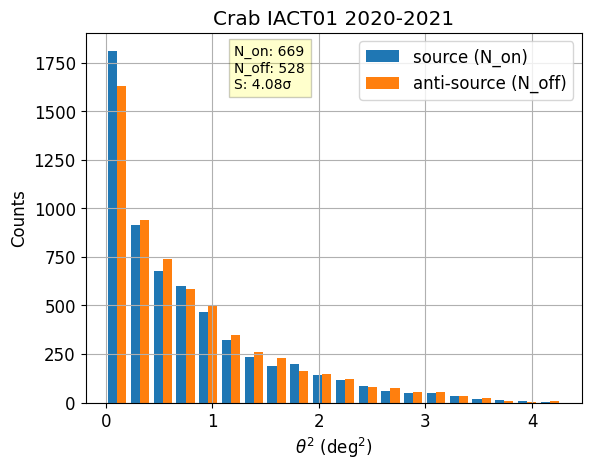

N_on = 669, N_off = 528, Significance = 4.08σ


In [100]:
def calculate_ksi(rc, size):
    if rc < 7.5:
        return 1.3
    elif 7.5 < rc < 10:
        return 1.6
    elif rc > 10:
        if size < 700:
            return 2.0
        elif 700 < size < 1000:
            return 1.9
        elif 1000 < size < 1250:
            return 1.75
        elif 1250 < size < 1500:
            return 1.5
    return np.nan

# Создаем явные копии срезов
source_events = source_events.copy()
antisource_events = antisource_events.copy()

# Process source events (N_on)
source_events['rc'] = source_events['dist1'] / 0.1206
source_events['ksi'] = source_events.apply(lambda row: calculate_ksi(row['rc'], row['size']), axis=1)
source_events = source_events[~source_events['ksi'].isna()]  # Remove NaN values
source_events['disp'] = source_events['ksi'] * (1.0 - source_events['width'] / source_events['length'])
source_events['theta2'] = (source_events['disp']**2 + source_events['dist1']**2 - 
                          2 * source_events['disp'] * source_events['dist1'] * np.cos(np.radians(source_events['alpha1'])))

# Process anti-source events (N_off)
antisource_events['rc'] = antisource_events['dist2'] / 0.1206
antisource_events['ksi'] = antisource_events.apply(lambda row: calculate_ksi(row['rc'], row['size']), axis=1)
antisource_events = antisource_events[~antisource_events['ksi'].isna()]  # Remove NaN values
antisource_events['disp'] = antisource_events['ksi'] * (1.0 - antisource_events['width'] / antisource_events['length'])
antisource_events['theta2'] = (antisource_events['disp']**2 + antisource_events['dist2']**2 - 
                              2 * antisource_events['disp'] * antisource_events['dist2'] * np.cos(np.radians(antisource_events['alpha2'])))

# Create histogram
plt.hist([source_events['theta2'], antisource_events['theta2']], 
         bins=20, label=['source (N_on)', 'anti-source (N_off)'])
plt.legend(loc='upper right')
plt.xlabel(r'$\theta^2$ (deg$^2$)')
plt.ylabel('Counts')
plt.title('Crab IACT01 2020-2021')

# Calculate statistics (using θ² < 0.05 cut)
theta_cut = 0.05
N_on = len(source_events[source_events['theta2'] < theta_cut])
N_off = len(antisource_events[antisource_events['theta2'] < theta_cut])

# Calculate significance
S = round(np.sqrt(2 * N_on * np.log(2 * (N_on / (N_on + N_off))) + 2 * N_off * np.log(2 * (N_off / (N_on + N_off)))), 2)

plt.annotate(f"N_on: {N_on}\nN_off: {N_off}\nS: {S}σ", 
             fontsize=10, bbox={'facecolor': 'yellow', 'alpha': 0.2},
             xy=(0.3, 0.85), xycoords='axes fraction')

plt.grid()
# plt.savefig('2020-2021_IACT01.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'N_on = {N_on}, N_off = {N_off}, Significance = {S}σ')
# import warnings
# warnings.simplefilter(action='ignore', category=SettingWithCopyWarning)

### Гистограмма по alpha

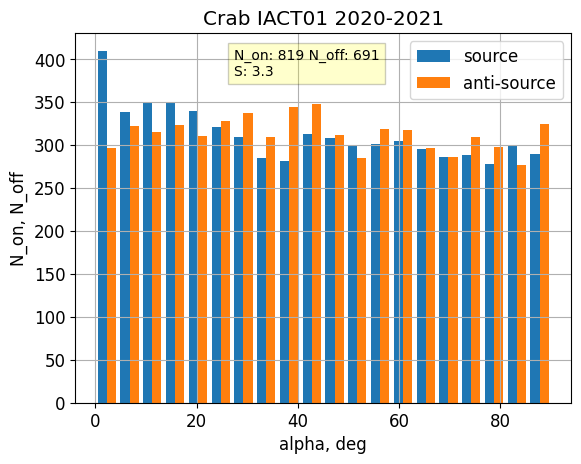

N_on = 819 N_off = 691 S_lima = 3.3


In [101]:
# та же самая функция, что выше только с доп катами, как у Паши В
# def filter_hillas_data(df):
#     common_filters = (
#         (df['CR_portion']/np.cos(np.pi/2-np.pi*df['tel_el']/180) > 5) &
#         (df['delta_time'] < 0.5) &
#         (df['error_deg'] < 0.1) &
#         (df['size'] > 120) &
#         (df['width'] > 0.024) &
#         (df['width'] < 0.068 * np.log10(df['size']) - 0.047) &
#         (df['length'] < 0.145 * np.log10(df['size']))
#     )
#     source_df = df[
#         common_filters &
#         (df['dist1'].between(0.36, 1.44))
#     ].copy()
#     source_df['source_type'] = 'source' 
    
#     anti_source_df = df[
#         common_filters &
#         (df['dist2'].between(0.36, 1.44))
#     ].copy()
#     anti_source_df['source_type'] = 'anti-source'
#     return source_df, anti_source_df

source_events, antisource_events = filter_hillas_data(combined_hillas)

plt.hist([source_events['alpha1'],antisource_events['alpha2']], bins=20,
            label=['source', 'anti-source'])#,stacked=True)  
plt.legend(loc='upper right')
plt.xlabel('alpha, deg')
plt.ylabel('N_on, N_off')
plt.title('Crab IACT01 2020-2021') 
N_on = len(source_events.loc[source_events['alpha1']<10])
N_off = len(antisource_events.loc[antisource_events['alpha2']<10])
S = round(np.sqrt(2*N_on*np.log(2*(N_on/(N_on+N_off))) + 2*N_off*np.log(2*(N_off/(N_on+N_off)))),2) #сигма
plt.annotate(f"N_on: {N_on} N_off: {N_off}\nS: {S}", fontsize=10,
            bbox={'facecolor':'yellow','alpha':0.2},
              xy=(3, 21), xytext=(0.32, 0.885), textcoords='axes fraction')
plt.grid()
plt.savefig('alpha_231119_2020-2021_IACT01.png', dpi=300, bbox_inches='tight')
plt.show()
print('N_on =', N_on, 'N_off =', N_off, 'S_lima =', S)

N_on = 431.0 N_off = 342.0 3.2011075056319482 3.2


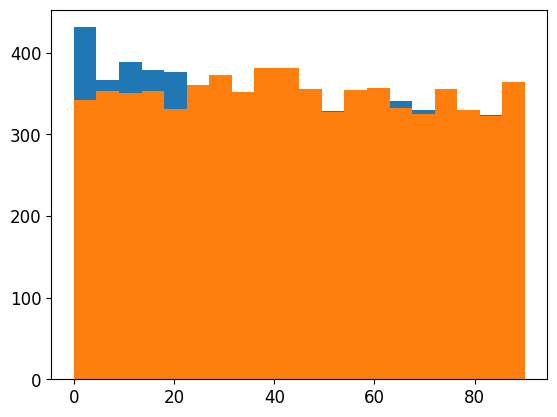

In [102]:
# Пашин В. вариант по альфа
# table_had = pd.read_csv('/media/alexandra/DATA/IACT01_231119/231119.01_out_hillas_14_7.0fix.csv') #23.11.19
table_had = hillas

on10 = plt.hist(table_had['alpha1'][(table_had['CR_portion']/np.cos(np.pi/2-np.pi*table_had['tel_el']/180) > 5) & 
                      (table_had['delta_time'] < 0.5) &
                      (table_had['error_deg'] < 0.1) &
                      (table_had['size'] > 120) & 
                      (table_had['dist1'] > 0.36) & 
                      (table_had['dist1'] < 1.44) & 
                      (table_had['width'] > 0.024) & 
                      (table_had['width'] < (0.068*np.log10(table_had['size'])-0.047)) &
                      (table_had['length'] <0.145*np.log10(table_had['size']))], range=[0,90], bins=20)[0]
off10 = plt.hist(table_had['alpha2'][(table_had['CR_portion']/np.cos(np.pi/2-np.pi*table_had['tel_el']/180) > 5) & 
                      (table_had['delta_time'] < 0.5) &
                      (table_had['error_deg'] < 0.1) &
                      (table_had['size'] > 120) & 
                      (table_had['dist2'] > 0.36) & 
                      (table_had['dist2'] < 1.44) & 
                      (table_had['width'] > 0.024) & 

                      (table_had['width'] < (0.068*np.log10(table_had['size'])-0.047)) &
                      (table_had['length'] <0.145*np.log10(table_had['size']))], range=[0,90], bins=20)[0]
N_on = on10[0]
N_off = off10[0]
S_lima = round(np.sqrt(2*N_on*np.log(2*(N_on/(N_on+N_off))) + 2*N_off*np.log(2*(N_off/(N_on+N_off)))),2) #сигма
print('N_on =', on10[0], 'N_off =', off10[0], (on10[0] - off10[0])/np.sqrt(on10[0] + off10[0]), S_lima)

### Пересчитываем параметры для 5 точек фона

In [103]:
# # Пересчитываем альфа и дисты
# def add_background_alphas_dists_thetas_abs(df):

#     # Вектор от CoG до источника
#     dx = df['source_x'] - df['Xc']
#     dy = df['source_y'] - df['Yc']
#     v_angle = np.arctan2(dy, dx)  # угол в радианах

#     # Направление главной оси эллипса: от вектора на источник - alpha1
#     u_angle = np.arctan(df.a_axis)  # главная ось в радианах
#     u_x = np.cos(u_angle)
#     u_y = np.sin(u_angle)

#     # Расстояние от центра камеры до источника — радиус окружности
#     r = np.sqrt(df['source_x']**2 + df['source_y']**2)
#     print(r)

#     # Угол на источник из центра камеры
#     angle0 = np.arctan2(df['source_y'], df['source_x'])

#     angles_deg = [180, 60, 120, 240, 300] # антиисточник и 4 новых фоновых
#     angles_rad = [angle0 + np.deg2rad(a) for a in angles_deg]

#     for i, angle in enumerate(angles_rad, start=1):
#         # Координаты точки на окружности
#         x = r * np.cos(angle)
#         y = r * np.sin(angle)

#         dx = x - df['Xc']
#         dy = y - df['Yc']
#         dist = np.sqrt(dx**2 + dy**2)

#         v_angle = np.arctan2(dy, dx)
#         delta = np.abs(v_angle - u_angle)
#         delta = np.mod(delta, 2 * np.pi)
#         alpha = np.minimum(delta, 2 * np.pi - delta)
#         alpha_deg = np.rad2deg(alpha)
#         alpha_deg = np.where(alpha_deg > 90, 180 - alpha_deg, alpha_deg)

#         df[f'bg{i}_dist'] = dist
#         df[f'bg{i}_alpha'] = alpha_deg
#     return df

# hillas_with_5point_background = add_background_alphas_dists_thetas_abs(hillas)

# hillas_with_5point_background

In [104]:
# новая ф-ия
def get_background_points_vectorized(source_x, source_y, r_circle=0.36):

    n = len(source_x)
    
    # Расстояние от центра до источника
    r = np.sqrt(source_x**2 + source_y**2)
    
    # Угол источника
    source_angle = np.arctan2(source_y, source_x)
    
    # Угол антиисточника (поворот на 180°)
    antisource_angle = source_angle + np.pi
    
    # Угол смещения между фоновыми точками
    cos_delta = 1 - (r_circle**2) / (2 * r**2)
    delta_angle = np.arccos(cos_delta)
    angles = np.zeros((n, 5))
    angles[:, 0] = antisource_angle - 2 * delta_angle
    angles[:, 1] = antisource_angle - delta_angle
    angles[:, 2] = antisource_angle  # антиисточник
    angles[:, 3] = antisource_angle + delta_angle
    angles[:, 4] = antisource_angle + 2 * delta_angle
    
    # Координаты фоновых точек
    # Форма: (n, 5, 2) - n строк, 5 точек, 2 координаты (x, y)
    r_expanded = r[:, np.newaxis, np.newaxis]  # (n, 1, 1)
    angles_expanded = angles[:, :, np.newaxis]  # (n, 5, 1)
    
    bg_points = np.zeros((n, 5, 2))
    bg_points[:, :, 0] = r[:, np.newaxis] * np.cos(angles)  # x
    bg_points[:, :, 1] = r[:, np.newaxis] * np.sin(angles)  # y
    
    return bg_points

def add_background_alphas_dists_vectorized(df, r_circle=0.36):
    n = len(df)
    
    # Извлекаем массивы для скорости
    source_x = df['source_x'].values
    source_y = df['source_y'].values
    Xc = df['Xc'].values
    Yc = df['Yc'].values
    a_axis = df['a_axis'].values
    
    # Получаем координаты всех фоновых точек
    # bg_points shape: (n, 5, 2)
    bg_points = get_background_points_vectorized(source_x, source_y, r_circle)
    
    # Подготавливаем массивы для результатов
    # (n, 5) для dist и alpha
    all_dists = np.zeros((n, 5))
    all_alphas = np.zeros((n, 5))
    
    # Расширяем Xc, Yc, a_axis для векторизованных операций
    Xc_expanded = Xc[:, np.newaxis]  # (n, 1)
    Yc_expanded = Yc[:, np.newaxis]  # (n, 1)
    a_axis_expanded = a_axis[:, np.newaxis]  # (n, 1)
    
    # Вычисляем векторы от CoG к фоновым точкам
    # (n, 5, 2) - (n, 1, 2) = (n, 5, 2)
    dx = bg_points[:, :, 0] - Xc_expanded
    dy = bg_points[:, :, 1] - Yc_expanded
    
    # Расстояния (n, 5)
    all_dists = np.sqrt(dx**2 + dy**2)
    
    # Углы векторов к фоновым точкам (n, 5)
    v_angles = np.arctan2(dy, dx)
    
    # Угол главной оси эллипса (n, 1)
    u_angles = np.arctan(a_axis_expanded)  # (n, 1)
    
    # Разница углов (n, 5)
    delta = np.abs(v_angles - u_angles)
    
    # Нормализация к [0, 2π]
    delta = np.mod(delta, 2 * np.pi)
    
    # Минимальный угол (n, 5)
    alpha = np.minimum(delta, 2 * np.pi - delta)
    
    # Преобразование в градусы (n, 5)
    all_alphas = np.degrees(alpha)
    
    # Нормализация к диапазону 0-90°
    all_alphas = np.where(all_alphas > 90, 180 - all_alphas, all_alphas)
    
    # Добавляем колонки в DataFrame
    for i in range(5):
        df[f'bg{i+1}_dist'] = all_dists[:, i]
        df[f'bg{i+1}_alpha'] = all_alphas[:, i]
    
    return df

hillas_with_5point_background = add_background_alphas_dists_vectorized(hillas, r_circle=0.36)

/tmp/ipykernel_5017/2740960550.py:16: RuntimeWarning: divide by zero encountered in divide
  cos_delta = 1 - (r_circle**2) / (2 * r**2)
/tmp/ipykernel_5017/2740960550.py:17: RuntimeWarning: invalid value encountered in arccos
  delta_angle = np.arccos(cos_delta)


In [105]:
# import matplotlib.pyplot as plt
# import numpy as np

# def plot_background_points_with_radii(df, idx, r_circle=0.36):
#     row = df.iloc[idx]

#     source_x = row['source_x']
#     source_y = row['source_y']
#     Xc = row['Xc']
#     Yc = row['Yc']
#     a_axis = row['a_axis']

#     # Радиус источника
#     r = np.sqrt(source_x**2 + source_y**2)

#     # Фоновые точки
#     bg_points = get_background_points_vectorized(
#         np.array([source_x]),
#         np.array([source_y]),
#         r_circle
#     )[0]

#     # Антиисточник
#     anti_x, anti_y = -source_x, -source_y

#     # Главная ось
#     axis_angle = np.arctan(a_axis)
#     axis_len = 0.6
#     axis_x = [Xc - axis_len*np.cos(axis_angle),
#               Xc + axis_len*np.cos(axis_angle)]
#     axis_y = [Yc - axis_len*np.sin(axis_angle),
#               Yc + axis_len*np.sin(axis_angle)]

#     plt.figure(figsize=(7, 7))

#     # Центр камеры
#     plt.scatter(0, 0, c='black', s=120, marker='+', label='Camera center')

#     # Окружность радиуса r
#     cam_circle = plt.Circle((0, 0), r,
#                             color='black', fill=False,
#                             linestyle=':', linewidth=1.5,
#                             label=f'r = {r:.3f}')
#     plt.gca().add_artist(cam_circle)

#     # Радиус к источнику
#     plt.plot([0, source_x], [0, source_y],
#              c='red', lw=2, label='Source radius')

#     # Радиусы к фоновым точкам
#     for i, (x, y) in enumerate(bg_points):
#         plt.plot([0, x], [0, y], c='blue', lw=1, alpha=0.6)
#         plt.text(x, y, f'{i+1}', fontsize=12,
#                  color='blue', ha='center', va='center',
#                  bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

#     # Источник
#     plt.scatter(source_x, source_y, c='red', s=100, label='Source')

#     # Антиисточник
#     plt.scatter(anti_x, anti_y, c='black', s=90, marker='x', label='Anti-source')

#     # CoG
#     plt.scatter(Xc, Yc, c='green', s=90, label='CoG')

#     # Главная ось
#     plt.plot(axis_x, axis_y, c='green', lw=2, label='Main axis')

#     # Оси
#     plt.axhline(0, color='gray', lw=0.7)
#     plt.axvline(0, color='gray', lw=0.7)

#     plt.gca().set_aspect('equal', adjustable='box')
#     plt.xlabel('x')
#     plt.ylabel('y')
#     plt.title(f'Event #{idx}')
#     plt.legend(loc='upper right')
#     plt.grid(alpha=0.3)
#     plt.savefig('/home/alexandra/Desktop/TAIGA/vizualisation_bg_points.png', dpi=300, bbox_inches='tight')
#     plt.show()
# plot_background_points_with_radii(hillas_with_5point_background, idx=0)

In [106]:
# Быстрая проверка: есть ли события с одинаковыми (por, event_numb)
has_overlaps = hillas_with_5point_background[['por', 'event_numb']].duplicated().any()
print(f"Есть ли дубликаты (por, event_numb): {has_overlaps}")

# Если есть, показываем их
if has_overlaps:
    duplicates = hillas_with_5point_background[hillas_with_5point_background[['por', 'event_numb']].duplicated(keep=False)]
    print(f"\nНайдено {len(duplicates['por'].unique())} событий с дубликатами:")
    print(duplicates[['por', 'event_numb', 'source_x', 'source_y']])

Есть ли дубликаты (por, event_numb): True

Найдено 84 событий с дубликатами:
         por  event_numb  source_x  source_y
0          1          14      1.28     -0.02
1          1          70      1.28     -0.02
2          1         116      1.28     -0.02
3          1         149      1.28     -0.02
4          1         169      1.28     -0.02
...      ...         ...       ...       ...
3296887   67      886815     -0.92     -0.81
3296897   67      886888     -0.91     -0.81
3296906   67      886961     -0.92     -0.81
3296908   67      886966     -0.92     -0.81
3296912   67      887003     -0.91     -0.81

[179349 rows x 4 columns]


In [107]:
hillas_with_5point_background

,por,event_numb,time,unix_time_ns,delta_time,error_deg,tel_az,tel_el,source_az,source_el,...,bg1_dist,bg1_alpha,bg2_dist,bg2_alpha,bg3_dist,bg3_alpha,bg4_dist,bg4_alpha,bg5_dist,bg5_alpha
0,1,14,13:37:23:280:261:540,1612791443280261540,0.22,0.03,181.85089,60.151,184.37523,60.168,...,3.371586,64.493144,3.350778,70.622512,3.267376,76.689544,3.123352,82.609715,2.922200,88.274263
1,1,70,13:37:23:362:354:610,1612791443362354610,0.14,0.03,181.85089,60.151,184.37523,60.168,...,1.868061,75.911409,1.732597,86.549195,1.566778,82.321326,1.375364,70.399505,1.164869,57.150062
2,1,116,13:37:23:411:776:330,1612791443411776330,0.09,0.03,181.85089,60.151,184.37523,60.168,...,4.228247,72.537988,4.473025,76.016350,4.654966,79.917609,4.767497,84.077580,4.806770,88.361630
3,1,149,13:37:23:444:607:650,1612791443444607650,0.06,0.03,181.85089,60.151,184.37523,60.168,...,3.125421,80.681487,2.778068,82.520658,2.418068,82.522523,2.074696,79.755797,1.792092,73.125419
4,1,169,13:37:23:465:362:590,1612791443465362590,0.03,0.03,181.85089,60.151,184.37523,60.168,...,3.353194,66.451068,3.646731,63.035749,3.888517,58.976695,4.070084,54.498498,4.185622,49.764121
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3296949,67,887272,16:24:00:251:741:530,1612628640251741530,0.25,0.03,244.91386,45.279,243.62814,46.048,...,2.928077,50.524805,3.232568,54.102116,3.485078,58.483270,3.675711,63.373433,3.797726,68.569128
3296950,67,887273,16:24:00:252:921:020,1612628640252921020,0.25,0.03,244.91386,45.279,243.62814,46.048,...,3.392363,89.797490,3.059026,87.784027,2.701440,86.954482,2.347903,88.499394,2.040049,86.613578
3296951,67,887282,16:24:00:406:925:590,1612628640406925590,0.09,0.03,244.91386,45.279,243.62814,46.048,...,1.770926,61.033174,2.016021,53.030980,2.344840,49.168170,2.703666,48.507158,3.055656,50.012532
3296952,67,887283,16:24:00:421:163:880,1612628640421163880,0.08,0.03,244.91386,45.279,243.62814,46.048,...,3.243418,46.971984,2.983789,42.377635,2.674621,38.636349,2.329790,36.262881,1.969824,36.130287


### Накладываем каты

In [108]:
def filter_hillas_data_split_background(df):
    # Общие фильтры
    common_filters = (
        (df['CR_portion']/np.cos(np.pi/2-np.pi*df['tel_el']/180) > 5) &
        (df['size'] > 120) &
        (df['tracking'] == 1) &
        (df['weather_mark'] > 8) &
        (df['good'] == 1) &
        # (df['edge'] == 0) &
        (df['width'] > 0.024) &
        (df['width'] < 0.068 * np.log10(df['size']) - 0.047) &
        (df['length'] < 0.145 * np.log10(df['size']))
    )
    # Таблица с источником (dist1)
    source_df = df[
        common_filters &
        (df['dist1'].between(0.36, 1.44))
    ]
    # Отдельные таблицы для каждого фонового региона
    anti_source_df = df[
        common_filters &
        (df['dist2'].between(0.36, 1.44))
    ]
    bg2_df = df[
        common_filters &
        (df['bg2_dist'].between(0.36, 1.44))
    ]
    bg3_df = df[
        common_filters &
        (df['bg3_dist'].between(0.36, 1.44))
    ]
    bg4_df = df[
        common_filters &
        (df['bg4_dist'].between(0.36, 1.44))
    ]
    bg5_df = df[
        common_filters &
        (df['bg5_dist'].between(0.36, 1.44))
    ]
    return source_df, anti_source_df, bg2_df, bg3_df, bg4_df, bg5_df

source, anti_source, bg2, bg3, bg4, bg5 = filter_hillas_data_split_background(hillas_with_5point_background)
bg5

,por,event_numb,time,unix_time_ns,delta_time,error_deg,tel_az,tel_el,source_az,source_el,...,bg1_dist,bg1_alpha,bg2_dist,bg2_alpha,bg3_dist,bg3_alpha,bg4_dist,bg4_alpha,bg5_dist,bg5_alpha
552,1,4483,13:37:56:139:573:630,1612791476139573630,0.14,0.03,182.10608,60.151,184.62782,60.161,...,0.616767,22.307239,0.675954,54.229039,0.813455,80.157091,0.989238,79.672733,1.175796,63.259752
1788,1,14221,13:39:11:972:558:790,1612791551972558790,0.03,0.03,182.69500,60.149,185.21812,60.144,...,2.518584,79.763631,2.190689,83.389166,1.837338,85.356145,1.478490,84.355701,1.150480,77.834728
3769,2,69153,13:41:26:826:694:990,1612791686826694990,0.17,0.03,188.54557,59.953,186.26525,60.110,...,2.337909,84.636940,1.983053,83.023356,1.626380,84.581253,1.313039,88.464880,1.120504,74.058216
4550,3,76693,13:42:27:551:944:800,1612791747551944800,0.05,0.03,189.01780,59.914,186.73385,60.092,...,1.979683,79.934128,1.831742,70.047078,1.641808,59.929945,1.414653,49.415289,1.156268,38.167298
4862,3,78303,13:42:47:261:756:620,1612791767261756620,0.24,0.03,189.17109,59.910,186.88866,60.086,...,1.028696,20.162493,0.827113,1.553865,0.645713,23.013162,0.530608,56.893416,0.538982,83.779406
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3295917,66,880376,16:22:12:720:503:100,1612628532720503100,0.22,0.03,244.45550,45.525,243.14335,46.297,...,1.672343,56.159839,1.317092,53.909524,0.960243,56.330968,0.655431,70.198563,0.547943,76.485405
3296264,66,882588,16:22:44:113:908:450,1612628564113908450,0.11,0.03,244.59212,45.453,243.28509,46.224,...,2.249059,88.702781,1.918583,84.763834,1.563368,82.828465,1.206474,84.797284,0.895285,85.211582
3296506,67,884231,16:23:17:297:301:760,1612628597297301760,0.20,0.03,244.74003,45.372,243.43552,46.147,...,0.825206,50.234649,0.845526,75.082934,0.911402,81.657734,1.009060,60.841370,1.123112,42.384143
3296651,67,885187,16:23:30:693:511:400,1612628610693511400,0.19,0.03,244.79774,45.343,243.49381,46.117,...,2.210357,87.220913,1.852475,86.116848,1.499375,88.528656,1.198815,82.995546,1.033781,66.471665


In [109]:
len(anti_source), len(bg2), len(bg3), len(bg4), len(bg5)

(6057, 6047, 6053, 6105, 6215)

### Вычисляем тета

In [110]:
def calculate_theta2_for_all_separate(source_df, anti_source_df, bg2_df, bg3_df, bg4_df, bg5_df):
    def calculate_ksi(rc, size):
        """Функция для расчета коэффициента ksi"""
        if rc < 7.5:
            return 1.3
        elif rc <= 10:
            return 1.6
        else:
            if size < 700:
                return 2.0
            elif size < 1000:
                return 1.9
            elif size < 1250:
                return 1.75
            elif size < 1500:
                return 1.5
        return np.nan

    # 1. Обработка источника
    source_processed = source_df.copy()
    if 'dist1' in source_processed.columns:
        source_processed['source_rc'] = source_processed['dist1'] / 0.1206
        source_processed['source_ksi'] = source_processed.apply(
            lambda row: calculate_ksi(row['source_rc'], row['size']), axis=1)
        source_processed = source_processed[~source_processed['source_ksi'].isna()]  # Remove NaN values
        source_processed['source_disp'] = source_processed['source_ksi'] * (
            1.0 - source_processed['width'] / source_processed['length'])
        source_processed['source_theta2'] = (
            source_processed['source_disp']**2 + 
            source_processed['dist1']**2 - 
            2 * source_processed['source_disp'] * source_processed['dist1'] * 
            np.cos(np.radians(source_processed['alpha1'])))
        
        source_processed = source_processed.drop(
            columns=['source_rc', 'source_ksi', 'source_disp'], errors='ignore')

    # 2. Обработка антиисточника
    anti_source_processed = anti_source_df.copy()
    if 'dist2' in anti_source_processed.columns:
        anti_source_processed['dist2_rc'] = anti_source_processed['dist2'] / 0.1206
        anti_source_processed['dist2_ksi'] = anti_source_processed.apply(
            lambda row: calculate_ksi(row['dist2_rc'], row['size']), axis=1)
        anti_source_processed = anti_source_processed[~anti_source_processed['dist2_ksi'].isna()]  # Remove NaN value
        anti_source_processed['dist2_disp'] = anti_source_processed['dist2_ksi'] * (
            1.0 - anti_source_processed['width'] / anti_source_processed['length'])
        anti_source_processed['dist2_theta2'] = (
            anti_source_processed['dist2_disp']**2 + 
            anti_source_processed['dist2']**2 - 
            2 * anti_source_processed['dist2_disp'] * anti_source_processed['dist2'] * 
            np.cos(np.radians(anti_source_processed['alpha2']))) # это тета просто так подписано)) 
        
        anti_source_processed = anti_source_processed.drop(
            columns=['dist2_rc', 'dist2_ksi', 'dist2_disp'], errors='ignore')

    # 3-6. Обработка 4 фоновых точек (bg2, bg3, bg4, bg5)
    def process_bg(df, bg_num):
        """Обработка одной фоновой точки"""
        df = df.copy()
        prefix = f'bg{bg_num}_'
        
        df[f'{prefix}rc'] = df[f'{prefix}dist'] / 0.1206
        df[f'{prefix}ksi'] = df.apply(
            lambda row: calculate_ksi(row[f'{prefix}rc'], row['size']), axis=1)
        df = df[~df[f'{prefix}ksi'].isna()]  # Remove NaN values
        df[f'{prefix}disp'] = df[f'{prefix}ksi'] * (1.0 - df['width'] / df['length'])
        # print(df[f'{prefix}disp'])
        df[f'{prefix}theta2'] = (
            df[f'{prefix}disp']**2 + 
            df[f'{prefix}dist']**2 - 
            2 * df[f'{prefix}disp'] * df[f'{prefix}dist'] * 
            np.cos(np.radians(df[f'{prefix}alpha'])))
        
        return df.drop(columns=[f'{prefix}rc', f'{prefix}ksi', f'{prefix}disp'], errors='ignore')

    bg2_processed = process_bg(bg2_df, 2)
    bg3_processed = process_bg(bg3_df, 3)
    bg4_processed = process_bg(bg4_df, 4)
    bg5_processed = process_bg(bg5_df, 5)

    return (
        source_processed,
        anti_source_processed,
        bg2_processed,
        bg3_processed,
        bg4_processed,
        bg5_processed
    )

(source_processed, 
 anti_source_processed,
 bg2_processed,
 bg3_processed, 
 bg4_processed,
 bg5_processed) = calculate_theta2_for_all_separate(source, anti_source, bg2, bg3, bg4, bg5)
bg2_processed

,por,event_numb,time,unix_time_ns,delta_time,error_deg,tel_az,tel_el,source_az,source_el,...,bg1_alpha,bg2_dist,bg2_alpha,bg3_dist,bg3_alpha,bg4_dist,bg4_alpha,bg5_dist,bg5_alpha,bg2_theta2
201,1,1750,13:37:34:405:215:660,1612791454405215660,0.09,0.03,181.93821,60.151,184.46073,60.166,...,7.994292,1.376642,22.442380,1.661869,30.770050,2.008182,33.854211,2.368034,33.582895,0.277096
237,1,2046,13:37:36:564:848:240,1612791456564848240,0.06,0.03,181.95444,60.151,184.47627,60.165,...,88.490061,1.066084,69.411578,1.239942,53.652505,1.541595,45.503085,1.894032,43.041585,1.405617
552,1,4483,13:37:56:139:573:630,1612791476139573630,0.14,0.03,182.10608,60.151,184.62782,60.161,...,22.307239,0.675954,54.229039,0.813455,80.157091,0.989238,79.672733,1.175796,63.259752,0.455426
593,1,4815,13:37:58:527:255:980,1612791478527255980,0.03,0.03,182.12550,60.151,184.64724,60.161,...,61.153592,1.115022,73.459340,1.392429,84.024882,1.643918,86.208319,1.863788,76.867246,1.819095
1461,1,11478,13:38:50:690:026:300,1612791530690026300,0.19,0.03,182.52607,60.149,185.05118,60.149,...,52.887873,0.805041,79.357649,1.097005,87.774591,1.449272,84.401785,1.807775,85.562906,1.225003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3295812,66,879616,16:22:02:057:862:990,1612628522057862990,0.06,0.03,244.40773,45.551,243.09604,46.321,...,87.882779,1.382672,73.815034,1.279774,58.913995,1.167723,42.826466,1.054969,25.107139,2.384153
3296506,67,884231,16:23:17:297:301:760,1612628597297301760,0.20,0.03,244.74003,45.372,243.43552,46.147,...,50.234649,0.845526,75.082934,0.911402,81.657734,1.009060,60.841370,1.123112,42.384143,1.193162
3296662,67,885277,16:23:31:993:753:040,1612628611993753040,0.01,0.03,244.80354,45.340,243.50053,46.113,...,89.901297,1.383529,80.654670,1.088760,70.995332,0.771254,60.371013,0.439769,46.522745,2.687116
3296719,67,885739,16:23:38:466:021:910,1612628618466021910,0.03,0.03,244.83383,45.325,243.52966,46.098,...,55.624054,1.309289,49.467108,1.621172,42.391549,1.898537,34.891142,2.135126,27.163525,1.104812


### Совмещенное распределение фона

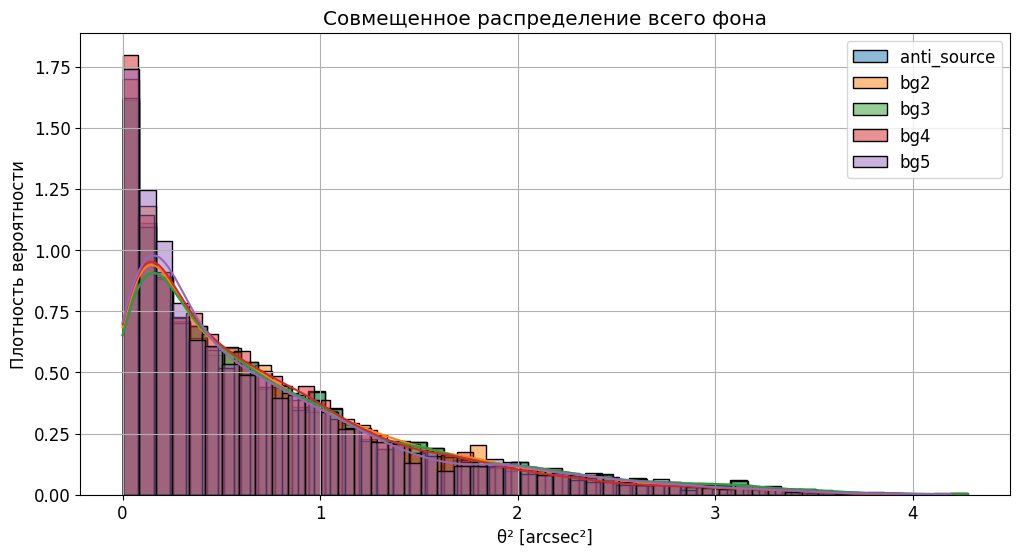

In [111]:
import seaborn as sns

# Собираем все данные в один DataFrame
all_data = pd.DataFrame()

# Добавляем антиисточник (если у него есть theta2)
if 'dist2_theta2' in anti_source_processed.columns:
    all_data['anti_source'] = anti_source_processed['dist2_theta2']

# Добавляем фоновые точки
for i, bg_df in enumerate([bg2_processed, bg3_processed, bg4_processed, bg5_processed], 2):
    col_name = f'bg{i}_theta2'
    if col_name in bg_df.columns:
        all_data[f'bg{i}'] = bg_df[col_name]

# Построение гистограмм
plt.figure(figsize=(12, 6))

# Гистограмма для каждого набора данных
for column in all_data.columns:
    sns.histplot(all_data[column], 
                 bins=50, 
                 alpha=0.5, 
                 label=column,
                 kde=True,
                 stat='density')

plt.title('Совмещенное распределение всего фона')
plt.xlabel('θ² [arcsec²]')
plt.ylabel('Плотность вероятности')
plt.legend()
plt.grid(True)
plt.savefig('/home/alexandra/Desktop/TAIGA/distr_bg_2_way.png', dpi=300, bbox_inches='tight')
plt.show()

### 5 точек фона и источник

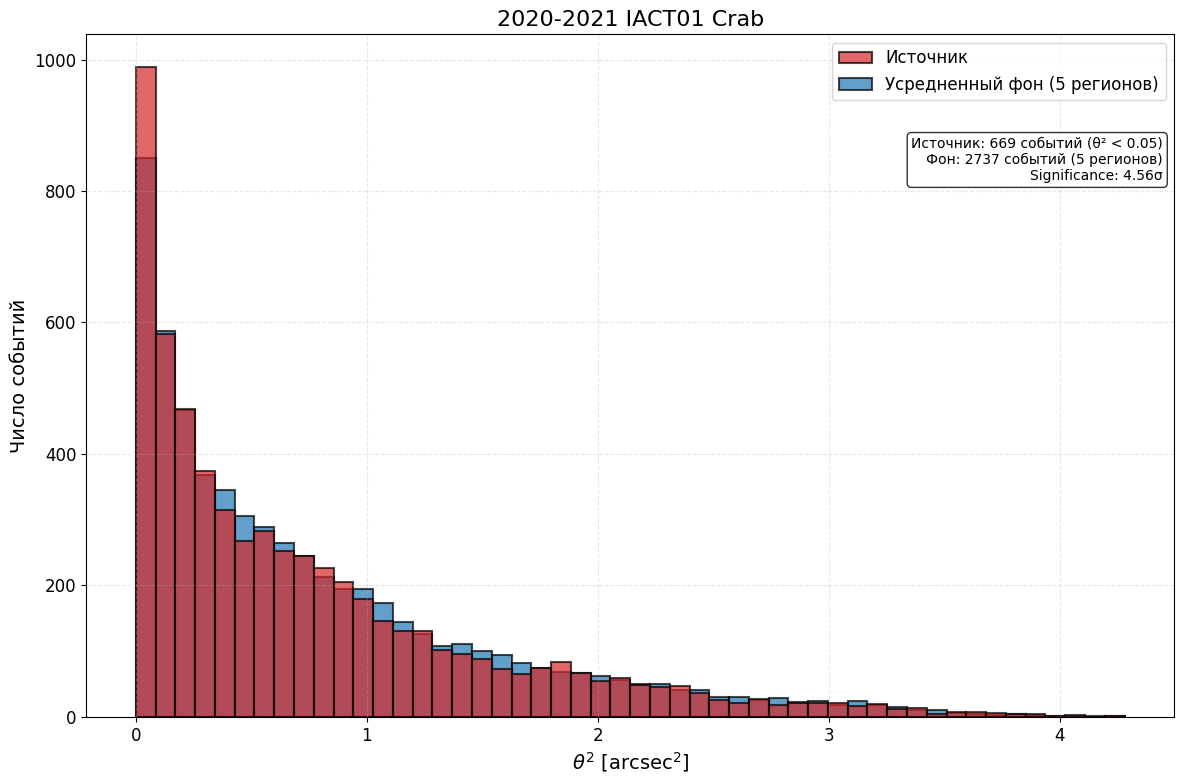

In [112]:
def plot_combined_with_averaged_background(source_df, anti_source_df, bg2_df, bg3_df, bg4_df, bg5_df, bins=40, theta_cut=None):
    plt.figure(figsize=(12, 8))
    plt.style.use('default')
    plt.rcParams['font.size'] = 12

    # Собираем все фоновые данные
    background_dfs = [
        anti_source_df['dist2_theta2'].dropna(),
        bg2_df['bg2_theta2'].dropna(),
        bg3_df['bg3_theta2'].dropna(),
        bg4_df['bg4_theta2'].dropna(),
        bg5_df['bg5_theta2'].dropna()
    ]

    # Данные источника
    source_data = source_df['source_theta2'].dropna()

    # Параметры гистограмм
    hist_kwargs = {
        'alpha': 0.7,
        'linewidth': 1.5,
        'edgecolor': 'k'
    }

    # Общие бины для всех гистограмм
    bin_edges = np.linspace(0, max(source_data.max(), max(bg.max() for bg in background_dfs)), bins+1)
    
    # Гистограмма источника (для визуализации)
    source_hist, _ = np.histogram(source_data, bins=bin_edges)
    
    # Усредненная гистограмма фона (только для визуализации)
    background_hists = [np.histogram(bg, bins=bin_edges)[0] for bg in background_dfs]
    background_hist_avg = np.mean(background_hists, axis=0)
    # print(background_hist_avg)

    # Визуализация
    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    plt.bar(bin_centers, background_hist_avg, width=np.diff(bin_edges), 
            color='#1f77b4', label='Усредненный фон (5 регионов)', **hist_kwargs)
    plt.hist(source_data, bins=bin_edges, color='#d62728', label='Источник', **hist_kwargs)

    ### Исправленный расчет значимости ###
    N_on = np.sum(source_data < theta_cut)
    
    # Суммируем все фоновые события до усреднения!
    N_off_total = sum(np.sum(bg < theta_cut) for bg in background_dfs)
    alpha = 1/5 
    
    # Формула Ли-Ма 
    term1 = N_on * np.log((1 + alpha)/alpha * (N_on/(N_on + N_off_total)))
    term2 = N_off_total * np.log((1 + alpha) * (N_off_total/(N_on + N_off_total)))
    S = np.sqrt(2 * (term1 + term2)) 
    S = round(S, 2)

    # Добавляем статистику
    stats_text = "\n".join([
        f"Источник: {N_on} событий (θ² < {theta_cut})",
        f"Фон: {N_off_total} событий (5 регионов)",
        f"Significance: {S}σ"
    ])

    plt.annotate(stats_text, xy=(0.99, 0.85), xycoords='axes fraction',
                ha='right', va='top', fontsize=10,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.xlabel(r'$\theta^2$ [arcsec$^2$]', fontsize=14)
    plt.ylabel('Число событий', fontsize=14)
    plt.title('2020-2021 IACT01 Crab', fontsize=16)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend(fontsize=12)
    # plt.yscale('log')
    plt.tight_layout()
    plt.savefig('2way_teta_231119_2020-2021_IACT01.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_combined_with_averaged_background(
    source_processed,
    anti_source_processed,
    bg2_processed,
    bg3_processed,
    bg4_processed,
    bg5_processed,
    bins=50,
    theta_cut=0.05 
)

### Разница N_on and N_off

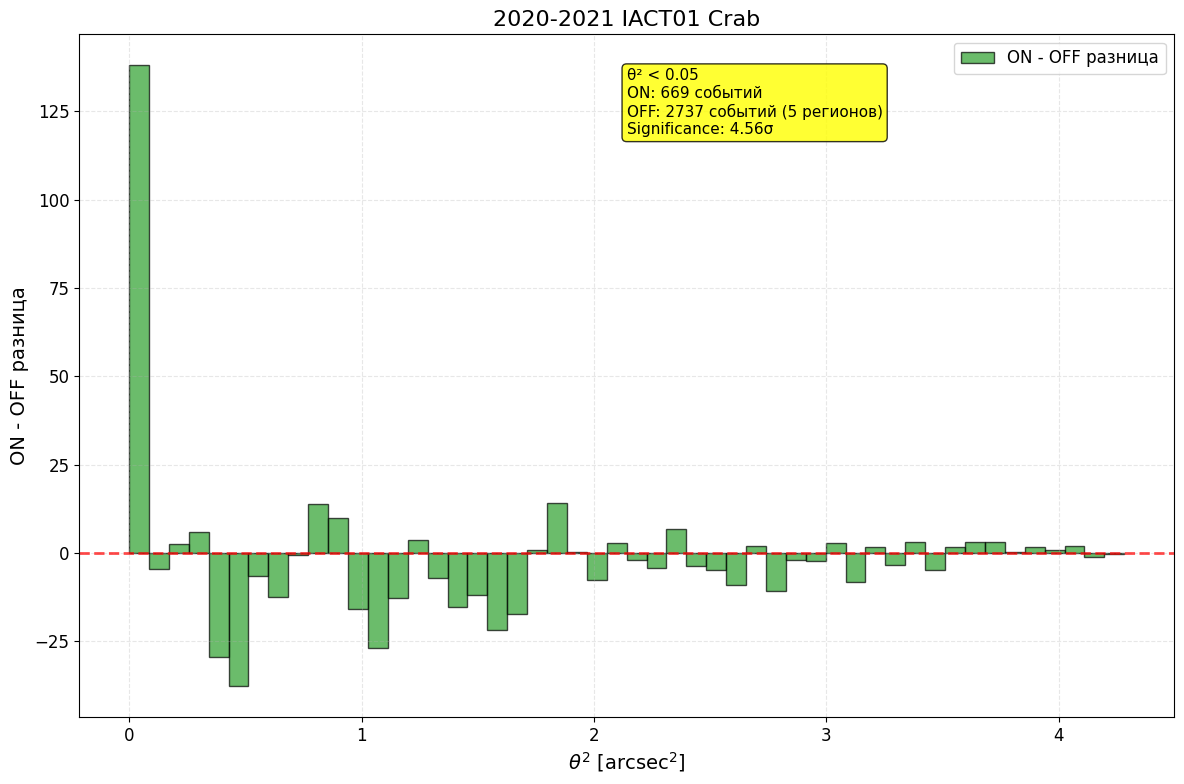

In [113]:
def plot_on_off_difference(source_df, anti_source_df, bg2_df, bg3_df, bg4_df, bg5_df, bins=40, theta_cut=None):
    plt.figure(figsize=(12, 8))
    plt.style.use('default')
    plt.rcParams['font.size'] = 12

    # Собираем все фоновые данные
    background_dfs = [
        anti_source_df['dist2_theta2'].dropna(),
        bg2_df['bg2_theta2'].dropna(),
        bg3_df['bg3_theta2'].dropna(),
        bg4_df['bg4_theta2'].dropna(),
        bg5_df['bg5_theta2'].dropna()
    ]

    # Данные источника
    source_data = source_df['source_theta2'].dropna()

    # Общие бины для всех гистограмм
    bin_edges = np.linspace(0, max(source_data.max(), max(bg.max() for bg in background_dfs)), bins+1)
    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    bin_width = np.diff(bin_edges)[0]
    
    # Гистограмма ON-региона (источник)
    on_hist, _ = np.histogram(source_data, bins=bin_edges)
    
    # Гистограммы OFF-регионов (фоны)
    off_hists = [np.histogram(bg, bins=bin_edges)[0] for bg in background_dfs]
    off_hist_avg = np.mean(off_hists, axis=0)
    
    # Разница ON - OFF (нормированная)
    # alpha = 1.0 / len(background_dfs)  # Коэффициент нормировки
    difference_hist = on_hist - off_hist_avg

    # Визуализация разницы ON-OFF
    plt.bar(bin_centers, difference_hist, width=bin_width, 
            color='#2ca02c', alpha=0.7, label='ON - OFF разница',
            edgecolor='k', linewidth=1)

    # Линия нуля для reference
    plt.axhline(y=0, color='red', linestyle='--', alpha=0.7, linewidth=2)
    
    # ПРАВИЛЬНЫЙ расчет N_on и N_off (как в исходном коде)
    if theta_cut is not None:
        N_on = np.sum(source_data < theta_cut)  # События источника до theta_cut
        
        # Суммируем все фоновые события до theta_cut (как в исходном коде)
        N_off_total = sum(np.sum(bg < theta_cut) for bg in background_dfs)
        alpha_total = 1/len(background_dfs)
        
        # Формула Ли-Ма
        term1 = N_on * np.log((1 + alpha_total)/alpha_total * (N_on/(N_on + N_off_total)))
        term2 = N_off_total * np.log((1 + alpha_total) * (N_off_total/(N_on + N_off_total)))
        S = np.sqrt(2 * (term1 + term2)) 
        S = round(S, 2)
        
        stats_text = "\n".join([
            f"θ² < {theta_cut}",
            f"ON: {N_on} событий",
            f"OFF: {N_off_total} событий (5 регионов)",
            f"Significance: {S}σ"
        ])
        
        plt.annotate(stats_text, xy=(0.5, 0.95), xycoords='axes fraction',
                    ha='left', va='top', fontsize=11,
                    bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))

    plt.xlabel(r'$\theta^2$ [arcsec$^2$]', fontsize=14)
    plt.ylabel('ON - OFF разница', fontsize=14)
    plt.title('2020-2021 IACT01 Crab', fontsize=16)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend(fontsize=12)

    plt.ylim()
    
    plt.tight_layout()
    plt.savefig('2way_on_off_difference_theta2.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Дополнительно: возвращаем данные для анализа
    return {
        'bin_centers': bin_centers,
        'bin_edges': bin_edges,
        'on_hist': on_hist,
        'off_hist_avg': off_hist_avg,
        'difference_hist': difference_hist,
        'N_on': N_on if theta_cut else None,
        'N_off_total': N_off_total if theta_cut else None,
        'significance': S if theta_cut else None
    }

# Вызов функции для построения графика разницы
result = plot_on_off_difference(
    source_processed,
    anti_source_processed,
    bg2_processed,
    bg3_processed,
    bg4_processed,
    bg5_processed,
    bins=50,
    theta_cut=0.05 
)

In [114]:
exp_data = source_processed[source_processed.source_theta2<0.05]

## Эффективная площадь

### Моделирование (один файл)

In [115]:
# с хилласом (триггер телескопа) сейчас 607 
# file_simulation = '/media/alexandra/DATA/IACT01_2020-2021/Simulation_607/taiga607_hillas_iact01_14_7fix_cb0.csv' # 607
file_simulation = '/media/alexandra/DATA/IACT01_2020-2021/Simulation_599_old/taiga599_hillas_iact01_14.0_7.0fix_cb0.csv' # Razumov
# file_simulation = '/media/alexandra/DATA/IACT01_2020-2021/Simulation_599/taiga599_hillas_iact01_14_7fix_cb0.csv' # 599
sim_hill_599 = pd.read_csv(file_simulation)
# изначальное моделирование
# file_sim = '/home/alexandra/Desktop/TAIGA/taiga599_A_sums2' # 599
# # file_sim = '/media/alexandra/DATA/IACT01_2020-2021/Simulation_599_old/taiga599_A_sums' # 599 Razumov
# # file_sim = '/media/alexandra/DATA/IACT01_2020-2021/Simulation_607/taiga607_A_sums2' # 607
# sim_all_599 = pd.read_csv(
#     file_sim,
#     comment='#',          # Игнорировать строки, начинающиеся с #
#     sep=r'\s+',           # Разделитель — любой количество пробелов
#     header=None,          # Нет заголовка в файле
#     skiprows=2,           # Пропустить первые 2 строки (заголовки)
#     engine='python',
#     names=['A', 'xtet', 'ytet', 'dist', 'AI', 'N_b_f', 'col7', 'col8', 'col9', 'col10', 'E_sim']
# )
# sim_all_599 = sim_all_599.iloc[::5]

# sim_all_599

In [116]:

file_sim = '/media/alexandra/DATA/IACT01_2020-2021/Simulation_599_old/taiga599_A_sums2' # 599 Razumov

# Читаем файл, пропуская первые 2 строки
sim_all_599 = pd.read_csv(file_sim, delim_whitespace=True, skiprows=2, header=None,
                 names=['A', 'x1', 'xtel', 'ytel', 'dist', 'A1', 'N_b_f', 'col7', 'col8', 'col9', 'E_sim'])

sim_all_599 = sim_all_599.iloc[::5]
sim_all_599

/tmp/ipykernel_5017/1436423744.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  sim_all_599 = pd.read_csv(file_sim, delim_whitespace=True, skiprows=2, header=None,


,A,x1,xtel,ytel,dist,A1,N_b_f,col7,col8,col9,E_sim
0,888.892653,-3.51,534.416625,457.058225,439.579895,26.482924,7,-4.741799e-07,4.180695e-09,182.74090,2.151626
5,169.274424,-3.51,-289.263625,396.712574,396.629972,6.517722,0,NaN,NaN,41.08464,2.151626
10,883.008460,-3.51,474.001531,398.761218,381.694694,31.779906,0,NaN,NaN,246.03450,2.151626
15,751.223137,-3.51,547.728187,469.975031,452.394578,25.785505,7,-3.014739e-07,5.640862e-09,205.82020,2.151626
20,396.788584,-3.51,691.912375,610.970261,592.100261,15.355543,1,-4.412019e-07,0.000000e+00,135.36810,2.151626
...,...,...,...,...,...,...,...,...,...,...,...
1999375,995.510228,-3.51,-381.340250,485.737850,483.791812,35.086927,8,-2.305515e-06,7.316976e-09,244.93280,2.170609
1999380,457.484037,-3.51,-539.170250,640.348056,639.210059,12.681667,3,-2.580474e-06,7.638555e-09,98.48650,2.170609
1999385,278.155193,-3.51,-520.226875,621.705688,620.494228,8.030977,2,-2.535573e-06,6.752764e-09,54.57752,2.170609
1999390,247.301242,-3.51,931.244438,847.381508,842.869938,8.477879,3,1.095788e-07,2.690235e-12,82.65693,2.170609


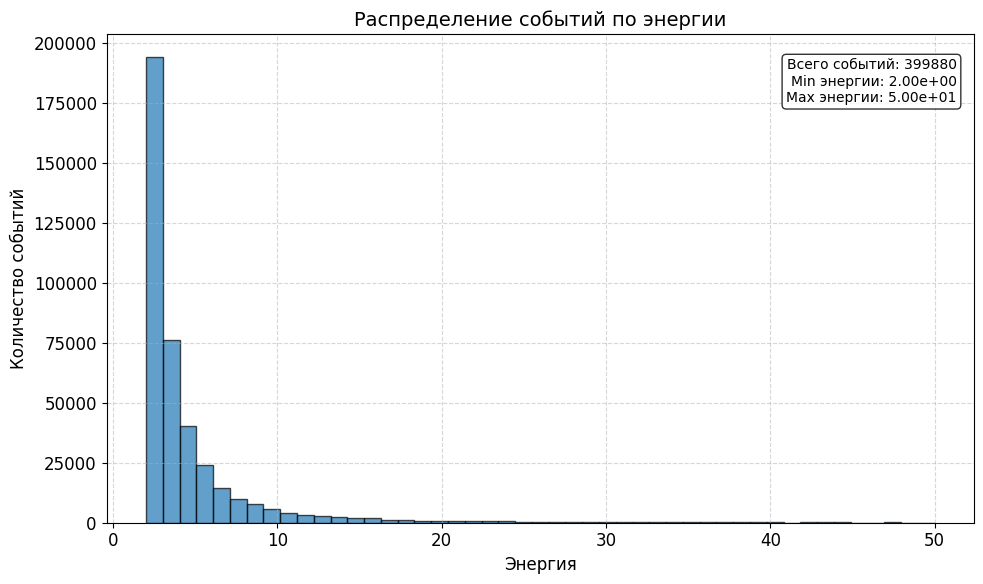

In [117]:
# проверка диапазона по энергии
plt.figure(figsize=(10, 6))

# Определяем диапазон и количество бинов
energy_min = sim_all_599['E_sim'].min()
energy_max = sim_all_599['E_sim'].max()
bins = np.linspace(energy_min, energy_max, 48) 

plt.hist(sim_all_599['E_sim'], bins=bins, edgecolor='black', alpha=0.7)
plt.xlabel('Энергия', fontsize=12)
plt.ylabel('Количество событий', fontsize=12)
plt.title('Распределение событий по энергии', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)

# Добавляем информацию о статистике
stats_text = f"Всего событий: {len(sim_all_599)}\nMin энергии: {energy_min:.2e}\nMax энергии: {energy_max:.2e}"
plt.annotate(stats_text, xy=(0.98, 0.95), xycoords='axes fraction',
            ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

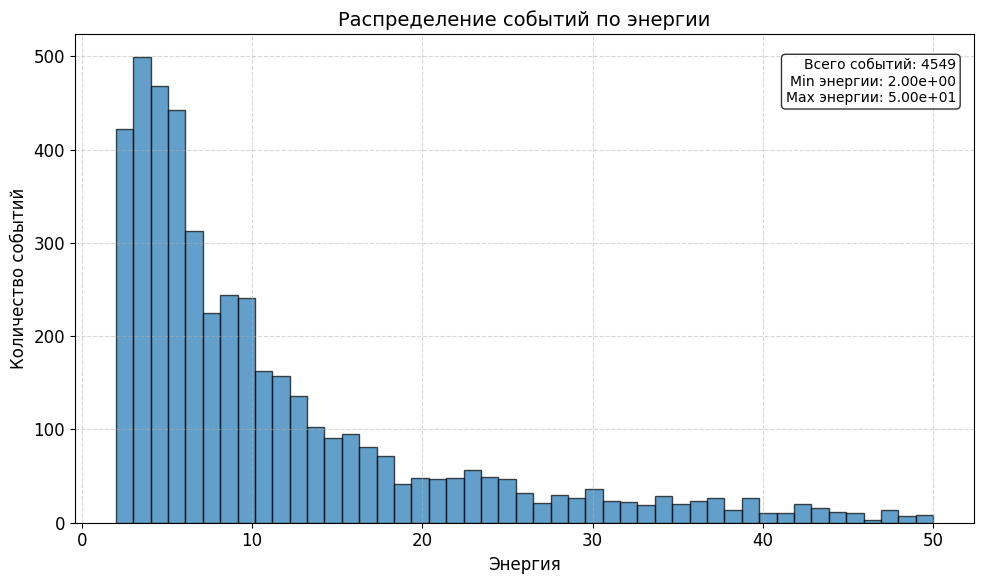

In [118]:
# проверка диапазона по энергии из телескопа
plt.figure(figsize=(10, 6))

# Определяем диапазон и количество бинов
energy_min = sim_hill_599.energy.min()
energy_max = sim_hill_599.energy.max()
bins = np.linspace(energy_min, energy_max, 48) 

plt.hist(sim_hill_599.energy, bins=bins, edgecolor='black', alpha=0.7)
plt.xlabel('Энергия', fontsize=12)
plt.ylabel('Количество событий', fontsize=12)
plt.title('Распределение событий по энергии', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)

# Добавляем информацию о статистике
stats_text = f"Всего событий: {len(sim_hill_599)}\nMin энергии: {energy_min:.2e}\nMax энергии: {energy_max:.2e}"
plt.annotate(stats_text, xy=(0.98, 0.95), xycoords='axes fraction',
            ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

In [130]:
def filter_hillas_data(df):
    common_filters = (
        (df['size'] > 120) &
        (df['edge'] == 0) &
        (df['width[0]'] > 0.024) &
        (df['width[0]'] < 0.068 * np.log10(df['size']) - 0.047) &
        (df['length[0]'] < 0.145 * np.log10(df['size']))
    )
    
    source_df = df[
        common_filters &
        (df['dist[1]'].between(0.36, 1.44))
    ]
    
    return source_df

sim_hill_selected_599 = filter_hillas_data(sim_hill_599)
sim_hill_selected_599

,clean_number,event_number,axis_scatter,numb_pix,energy,size,Xc[0],Yc[0],con2,length[0],...,source_y,x_ground,y_ground,tel_tet,tel_fi,source_tet,source_fi,Xmax,num_islands,con_selected_island
0,0,2,5,4,11.64790,191.260,0.043715,0.323091,0.772252,0.259698,...,0.862666,0.964031,215.5410,0.699570,2.41686,0.684378,2.44025,305.978,1,1.0
5,5,31,5,10,19.41840,856.251,0.930775,0.295348,0.542173,0.308242,...,0.862707,-61.919300,12.8512,0.662259,2.84144,0.647056,2.86593,391.042,1,1.0
10,10,51,8,6,5.82574,242.744,0.071497,0.255769,0.677644,0.317929,...,0.862785,-103.186000,123.7240,0.602435,3.08244,0.587212,3.10901,435.000,1,1.0
22,22,98,5,7,20.65240,557.898,-0.003442,1.479900,0.581513,0.329450,...,0.862786,120.277000,138.6370,0.587970,3.09875,0.572742,3.12590,343.661,1,1.0
23,23,98,6,8,20.65240,423.841,-0.270941,0.885689,0.612154,0.310477,...,0.862786,1.972700,188.5640,0.587970,3.09875,0.572742,3.12590,343.661,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8621,8621,39865,0,5,9.29708,205.359,0.006497,0.657389,0.749463,0.209359,...,0.862783,50.394500,167.4900,0.602353,2.57026,0.587130,2.59684,311.248,1,1.0
8624,8624,39867,8,5,4.85137,196.284,1.891780,0.953503,0.793142,0.319066,...,0.862682,-84.784500,-127.9150,0.678372,2.47368,0.663174,2.49767,381.533,1,1.0
8628,8628,39877,8,4,6.16670,160.287,-0.007937,1.835830,0.705896,0.271466,...,0.862702,223.422000,13.2526,0.676019,2.59013,0.660820,2.61419,366.137,1,1.0
8634,8634,39899,6,6,8.17348,348.505,0.938103,0.036507,0.630384,0.271669,...,0.862820,-144.436000,11.3108,0.549348,2.98182,0.534105,3.01065,360.602,1,1.0


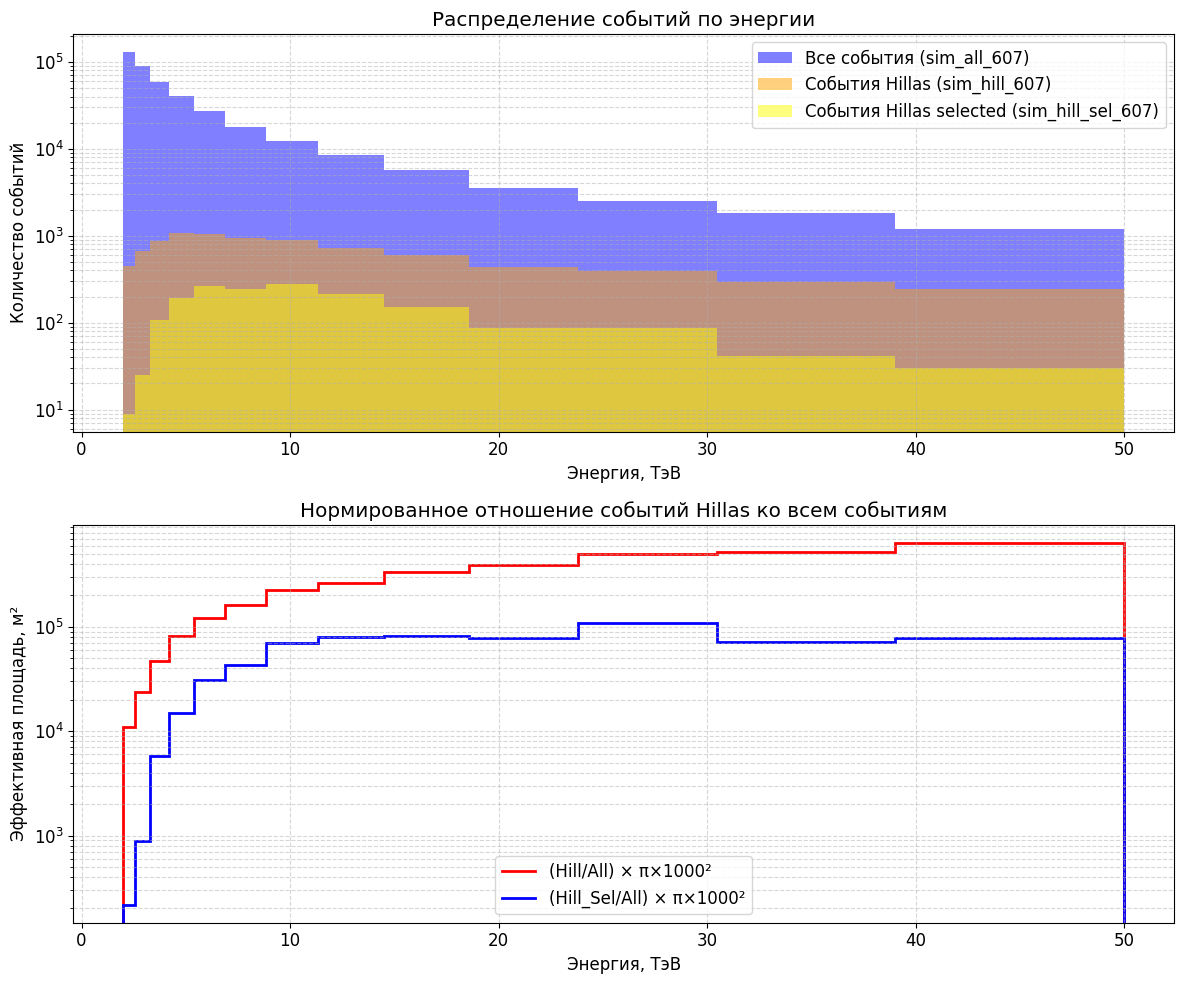

In [131]:
# без косинуса зенитного угла
df_all = sim_all_599 
df_hill = sim_hill_599 
df_hill_sel = sim_hill_selected_599

# Определение диапазона энергий (логарифмические бины)
energy_min = min(df_all['E_sim'].min(), df_hill['energy'].min())
energy_max = max(df_all['E_sim'].max(), df_hill['energy'].max())
bins = np.logspace(np.log10(energy_min), np.log10(energy_max), 14)  # логарифмических бинов

# Расчет гистограмм
hist_all, bin_edges = np.histogram(df_all['E_sim'], bins=bins)
hist_hill, _ = np.histogram(df_hill['energy'], bins=bin_edges)
hist_hill_sel, _ = np.histogram(df_hill_sel['energy'], bins=bin_edges)

# Отношение (Hill/All) * площадь круга (R=1000 м)
area_circle = np.pi * 1000**2
# ratio = (hist_hill / np.where(hist_all == 0, 1e-10, hist_all)) * area_circle
# ratio_sel = (hist_hill_sel / np.where(hist_all == 0, 1e-10, hist_all)) * area_circle
ratio = hist_hill / hist_all * area_circle
ratio_sel = hist_hill_sel / hist_all * area_circle

# Построение графиков
plt.figure(figsize=(12, 10))

# 1. Распределения по энергии
plt.subplot(2, 1, 1)
plt.stairs(hist_all, bin_edges, label='Все события (sim_all_607)', fill=True, alpha=0.5, color='blue')
plt.stairs(hist_hill, bin_edges, label='События Hillas (sim_hill_607)', fill=True, alpha=0.5, color='orange')
plt.stairs(hist_hill_sel, bin_edges, label='События Hillas selected (sim_hill_sel_607)', fill=True, alpha=0.5, color='yellow')
# plt.xscale('log')
plt.yscale('log')  
plt.xlabel('Энергия, ТэВ')
plt.ylabel('Количество событий')
plt.title('Распределение событий по энергии')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)

# 2. Отношение 
plt.subplot(2, 1, 2)
plt.stairs(ratio, bin_edges, label='(Hill/All) × π×1000²', color='red', linewidth=2)
plt.stairs(ratio_sel, bin_edges, label='(Hill_Sel/All) × π×1000²', color='blue', linewidth=2)
# plt.xscale('log')
plt.yscale('log')  
plt.xlabel('Энергия, ТэВ')
plt.ylabel('Эффективная площадь, м²')
plt.title('Нормированное отношение событий Hillas ко всем событиям')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('/home/alexandra/Desktop/TAIGA/2wayeff_sq_all_607.png', dpi=300, bbox_inches='tight')
plt.show()

### с поправкой на косинус на зенитный угол

In [31]:
# df_all = sim_all_599 
# df_hill = sim_hill_599 
# df_hill_sel = sim_hill_selected_599

# # Определение диапазона энергий (логарифмические бины)
# energy_min = min(df_all['E_sim'].min(), df_hill['energy'].min())
# energy_max = max(df_all['E_sim'].max(), df_hill['energy'].max())
# bins = np.logspace(np.log10(energy_min), np.log10(energy_max), 20)  # 20 логарифмических бинов

# # Расчет гистограмм
# hist_all, bin_edges = np.histogram(df_all['E_sim'], bins=bins)
# hist_hill, _ = np.histogram(df_hill['energy'], bins=bin_edges)
# hist_hill_sel, _ = np.histogram(df_hill_sel['energy'], bins=bin_edges)

# # Расчет среднего косинуса угла по бинам энергии
# cos_tel_tet_hill, _ = np.histogram(df_hill['energy'], bins=bin_edges, weights=np.cos(df_hill.tel_tet))
# cos_tel_tet_hill_avg = cos_tel_tet_hill / np.where(hist_hill == 0, 1, hist_hill)

# cos_tel_tet_hill_sel, _ = np.histogram(df_hill_sel['energy'], bins=bin_edges, weights=np.cos(df_hill_sel.tel_tet))
# cos_tel_tet_hill_sel_avg = cos_tel_tet_hill_sel / np.where(hist_hill_sel == 0, 1, hist_hill_sel)

# # Отношение (Hill/All) * площадь круга (R=1000 м) * косинус угла
# area_circle = np.pi * 1000**2
# ratio = (hist_hill / np.where(hist_all == 0, 1e-10, hist_all)) * area_circle * cos_tel_tet_hill_avg
# ratio_sel = (hist_hill_sel / np.where(hist_all == 0, 1e-10, hist_all)) * area_circle * cos_tel_tet_hill_sel_avg

# # Построение графиков
# plt.figure(figsize=(12, 10))

# # 1. Распределения по энергии
# plt.subplot(2, 1, 1)
# plt.stairs(hist_all, bin_edges, label='Все события (sim_all_607)', fill=True, alpha=0.5, color='blue')
# plt.stairs(hist_hill, bin_edges, label='События Hillas (sim_hill_607)', fill=True, alpha=0.5, color='orange')
# plt.stairs(hist_hill_sel, bin_edges, label='События Hillas selected (sim_hill_sel_607)', fill=True, alpha=0.5, color='yellow')
# plt.xscale('log')
# plt.yscale('log')  
# plt.xlabel('Энергия, ТэВ')
# plt.ylabel('Количество событий')
# plt.title('Распределение событий по энергии')
# plt.legend()
# plt.grid(True, which='both', linestyle='--', alpha=0.5)

# # 2. Отношение 
# plt.subplot(2, 1, 2)
# plt.stairs(ratio, bin_edges, label='(Hill/All) × π×1000² × cos(θ)', color='red', linewidth=2)
# plt.stairs(ratio_sel, bin_edges, label='(Hill_Sel/All) × π×1000² × cos(θ)', color='blue', linewidth=2)
# # plt.xscale('log')
# plt.yscale('log')  
# plt.xlabel('Энергия, ТэВ')
# plt.ylabel('Эффективная площадь, м²')
# plt.title('Нормированное отношение событий Hillas ко всем событиям')
# plt.legend()
# plt.grid(True, which='both', linestyle='--', alpha=0.5)

# plt.tight_layout()
# plt.savefig('eff_sq_all_607.png', dpi=300, bbox_inches='tight')
# plt.show()

### Реконструкция по энергии

### Cчитываем данные моделирования

### Отбираем данные (каты Хилласа)

In [128]:
# объединим моделирование 599 и 607
#607
file_simulation = '/media/alexandra/DATA/IACT01_2020-2021/Simulation_607/taiga607_hillas_iact01_14_7fix_cb0.csv' # 607
sim_hill_607 = pd.read_csv(file_simulation)
file_sim = '/media/alexandra/DATA/IACT01_2020-2021/Simulation_607/taiga607_A_sums2' # 607
sim_all_607 = pd.read_csv(
    file_sim,
    comment='#',          # Игнорировать строки, начинающиеся с #
    sep=r'\s+',           # Разделитель — любой количество пробелов
    header=None,          # Нет заголовка в файле
    skiprows=2,           # Пропустить первые 2 строки (заголовки)
    engine='python',
    names=['A', 'xtet', 'ytet', 'dist', 'AI', 'N_b_f', 'col7', 'col8', 'col9', 'col10', 'E_sim']
)
sim_all_607 = sim_all_607.iloc[::5]
#599
file_simulation = '/media/alexandra/DATA/IACT01_2020-2021/Simulation_599/taiga599_hillas_iact01_14_7fix_cb0.csv' # 599
sim_hill_599 = pd.read_csv(file_simulation)
file_sim = '/home/alexandra/Desktop/TAIGA/taiga599_A_sums2' # 599
sim_all_599 = pd.read_csv(
    file_sim,
    comment='#',          # Игнорировать строки, начинающиеся с #
    sep=r'\s+',           # Разделитель — любой количество пробелов
    header=None,          # Нет заголовка в файле
    skiprows=2,           # Пропустить первые 2 строки (заголовки)
    engine='python',
    names=['A', 'xtet', 'ytet', 'dist', 'AI', 'N_b_f', 'col7', 'col8', 'col9', 'col10', 'E_sim']
)
sim_all_599 = sim_all_599.iloc[::5]

df_all = pd.concat([sim_all_599, sim_all_607], ignore_index=True)
df_hill = pd.concat([sim_hill_599, sim_hill_607], ignore_index=True)

def filter_data(df):
    common_filters = (
        (df['size'] > 120) &
        (df['edge'] == 0) &
        (df['width[0]'] > 0.024) &
        (df['width[0]'] < 0.068 * np.log10(df['size']) - 0.047) &
        (df['length[0]'] < 0.145 * np.log10(df['size']))
    )
    
    source_df = df[
        common_filters &
        (df['dist[0]'].between(0.36, 1.44))
    ]
    return source_df

df_hill_sel = filter_data(df_hill)

df_hill_sel

,clean_number,event_number,axis_scatter,numb_pix,energy,size,Xc[0],Yc[0],con2,length[0],...,source_y,x_ground,y_ground,tel_tet,tel_fi,source_tet,source_fi,Xmax,num_islands,con_selected_island
5,5,31,5,10,19.41840,856.251,0.930775,0.295348,0.542173,0.308242,...,0.862707,-61.9193,12.85120,0.662259,2.84144,0.647056,2.865930,391.042,1,1.0
7,7,42,8,4,13.85630,393.941,0.918508,0.868309,0.846906,0.132539,...,0.862810,-12.6554,-4.16856,0.546353,2.85816,0.531109,2.887140,305.828,1,1.0
23,23,98,6,8,20.65240,423.841,-0.270941,0.885689,0.612154,0.310477,...,0.862786,1.9727,188.56400,0.587970,3.09875,0.572742,3.125900,343.661,1,1.0
25,25,100,0,4,6.11845,135.324,0.877505,0.151807,0.816862,0.221335,...,0.862680,-195.9550,103.37200,0.712000,2.67637,0.696811,2.699410,258.214,1,1.0
34,34,161,7,7,15.12130,471.021,0.698418,0.584535,0.836500,0.173198,...,0.862752,-42.8872,26.98610,0.658054,3.11005,0.642849,3.134670,355.141,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14288,5640,2440,4,9,21.17430,808.163,0.500460,0.162693,0.743091,0.288593,...,0.862677,97.6823,78.73680,0.663935,7.29509,0.648733,1.036340,372.113,1,1.0
14297,5649,2443,5,15,35.89830,1800.840,0.284027,0.963435,0.727695,0.331113,...,0.862790,20.8837,-47.86400,0.576863,6.87313,0.561631,0.617553,385.210,1,1.0
14317,5669,2448,4,40,145.50700,8679.110,-0.163476,0.340007,0.455649,0.558650,...,0.862822,90.1131,-90.79030,0.544348,6.50191,0.529103,0.247803,425.292,1,1.0
14327,5679,2452,6,8,21.92530,620.102,0.611821,0.369915,0.810878,0.290046,...,0.862686,88.1806,-22.41070,0.654194,6.36969,0.638989,0.111253,338.686,1,1.0


### Check disp

In [49]:
# Calculate disp according Sveshnikova ksi
df_hill_sel['rc'] = df_hill_sel['dist[1]'] / 0.1206
df_hill_sel['ksi'] = df_hill_sel.apply(lambda row: calculate_ksi(row['rc'], row['size']), axis=1)
df_hill_sel = df_hill_sel[~df_hill_sel['ksi'].isna()]  # Remove NaN values
df_hill_sel['disp'] = df_hill_sel['ksi'] * (1.0 - df_hill_sel['width[0]'] / df_hill_sel['length[0]'])
# df_hill_sel[df_hill_sel['alpha[1]']]

/tmp/ipykernel_5017/1329723288.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_hill_sel['rc'] = df_hill_sel['dist[1]'] / 0.1206
/tmp/ipykernel_5017/1329723288.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_hill_sel['ksi'] = df_hill_sel.apply(lambda row: calculate_ksi(row['rc'], row['size']), axis=1)
/tmp/ipykernel_5017/1329723288.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the ca

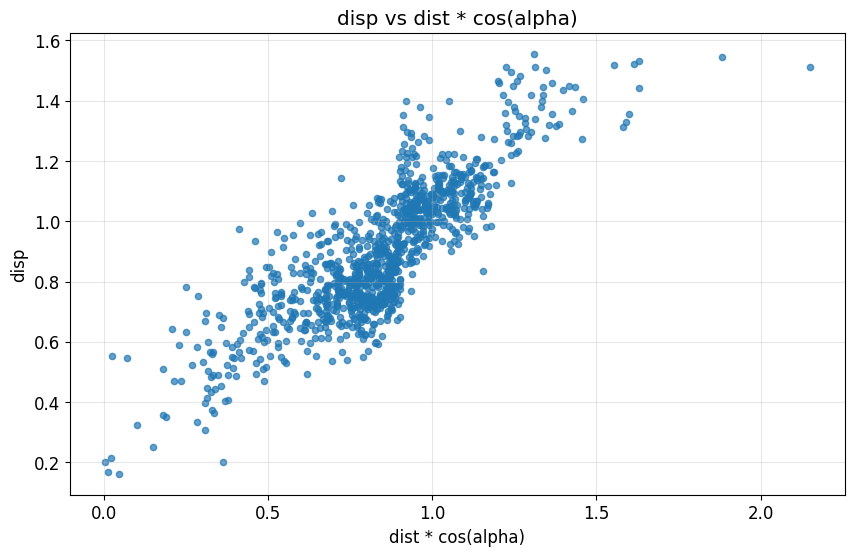

In [50]:
x_values = df_hill_sel['dist[1]'] * np.cos(np.radians(df_hill_sel['alpha[1]']))
y_values = df_hill_sel['disp']

# Построение графика
plt.figure(figsize=(10, 6))
plt.scatter(x_values, y_values, alpha=0.7, s=20)
plt.xlabel('dist * cos(alpha)')
plt.ylabel('disp')
plt.title('disp vs dist * cos(alpha)')
plt.grid(True, alpha=0.3)
plt.show()

In [51]:
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import r2_score, mean_squared_error

# # ПОДБИРАЕМ ОПТИМАЛЬНЫЕ KSI НАПРЯМУЮ

# # матрицу признаков
# features = ['size', 'dist[1]', 'width[0]', 'length[0]', 'alpha[1]']

# # Целевая переменная - то, что мы хотим получить в идеале
# y_target = df_hill_sel['dist[1]'] * np.cos(np.radians(df_hill_sel['alpha[1]']))

# # Разделяем данные
# X_train, X_test, y_train, y_test = train_test_split(
#     df_hill_sel[features], y_target, test_size=0.2, random_state=42
# )

# # Обучаем случайный лес предсказывать оптимальные disp
# rf = RandomForestRegressor(
#     n_estimators=100, 
#     random_state=42, 
#     max_depth=10
# )
# rf.fit(X_train, y_train)

# # Предсказываем оптимальные disp для всех данных
# df_hill_sel['optimal_disp'] = rf.predict(df_hill_sel[features])

# # ВЫЧИСЛЯЕМ оптимальные ksi из оптимальных disp
# df_hill_sel['optimal_ksi'] = df_hill_sel['optimal_disp'] / (1.0 - df_hill_sel['width[0]'] / df_hill_sel['length[0]'])

# df_clean = df_hill_sel[
#     (df_hill_sel['optimal_ksi'] > 0.5) & 
#     (df_hill_sel['optimal_ksi'] < 3.0)
# ].copy()

# print("Статистика оптимальных ksi:")
# print(f"Среднее: {df_clean['optimal_ksi'].mean():.4f}")
# print(f"Медиана: {df_clean['optimal_ksi'].median():.4f}")
# print(f"Стандартное отклонение: {df_clean['optimal_ksi'].std():.4f}")
# print(f"Минимум: {df_clean['optimal_ksi'].min():.4f}")
# print(f"Максимум: {df_clean['optimal_ksi'].max():.4f}")

# plt.figure(figsize=(15, 10))

# # Гистограмма оптимальных ksi
# plt.subplot(2, 2, 1)
# plt.hist(df_clean['optimal_ksi'], bins=50, alpha=0.7, color='blue', edgecolor='black')
# plt.xlabel('Оптимальное значение ksi')
# plt.ylabel('Частота')
# plt.title('Распределение оптимальных значений ksi')
# plt.grid(True, alpha=0.3)
# plt.axvline(df_clean['optimal_ksi'].mean(), color='red', linestyle='--', label=f'Среднее: {df_clean["optimal_ksi"].mean():.3f}')
# plt.axvline(df_clean['optimal_ksi'].median(), color='green', linestyle='--', label=f'Медиана: {df_clean["optimal_ksi"].median():.3f}')
# plt.legend()

# # Сравнение исходных и оптимизированных disp
# plt.subplot(2, 2, 2)
# x_values = df_clean['dist[1]'] * np.cos(np.radians(df_clean['alpha[1]']))
# y_original = df_clean['disp']
# y_optimal = df_clean['optimal_disp']

# plt.scatter(x_values, y_original, alpha=0.5, s=10, label='Исходные disp')
# plt.scatter(x_values, y_optimal, alpha=0.5, s=10, color='red', label='Оптимизированные disp')
# plt.plot([x_values.min(), x_values.max()], [x_values.min(), x_values.max()], 'k--', alpha=0.5, label='Идеальное согласие')
# plt.xlabel('dist * cos(alpha)')
# plt.ylabel('disp')
# plt.title('Сравнение исходных и оптимизированных disp')
# plt.legend()
# plt.grid(True, alpha=0.3)

# # Сравнение исходных и оптимальных ksi
# plt.subplot(2, 2, 3)
# plt.scatter(df_clean['ksi'], df_clean['optimal_ksi'], alpha=0.5, s=20)
# plt.plot([0.5, 2.5], [0.5, 2.5], 'r--', alpha=0.5, label='y = x')
# plt.xlabel('Исходные ksi')
# plt.ylabel('Оптимальные ksi')
# plt.title('Сравнение исходных и оптимальных ksi')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.savefig('/home/alexandra/Desktop/TAIGA/2wayteta_231119_2020-2021_IACT01.png', dpi=300, bbox_inches='tight')


# # Boxplot распределения ksi
# plt.subplot(2, 2, 4)
# plt.boxplot([df_clean['ksi'], df_clean['optimal_ksi']], 
#             labels=['Исходные ksi', 'Оптимальные ksi'])
# plt.ylabel('Значение ksi')
# plt.title('Boxplot распределения ksi')
# plt.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

# # 10. Анализ по группам
# df_clean['rc'] = df_clean['dist[1]'] / 0.1206

# print("\nОптимальные ksi по условиям:")
# conditions = [
#     (df_clean['rc'] < 7.5, 'rc < 7.5'),
#     ((df_clean['rc'] > 7.5) & (df_clean['rc'] < 10), '7.5 < rc < 10'),
#     ((df_clean['rc'] > 10) & (df_clean['size'] < 700), 'rc > 10, size < 700'),
#     ((df_clean['rc'] > 10) & (df_clean['size'] > 700) & (df_clean['size'] < 1000), 'rc > 10, 700 < size < 1000'),
#     ((df_clean['rc'] > 10) & (df_clean['size'] > 1000) & (df_clean['size'] < 1250), 'rc > 10, 1000 < size < 1250'),
#     ((df_clean['rc'] > 10) & (df_clean['size'] > 1250) & (df_clean['size'] < 1500), 'rc > 10, 1250 < size < 1500'),
# ]

# for condition, description in conditions:
#     group_data = df_clean[condition]
#     if len(group_data) > 0:
#         print(f"{description}: {group_data['optimal_ksi'].median():.4f} (n={len(group_data)})")

# # 11. Оценка улучшения
# original_errors = np.abs(y_original - x_values)
# optimal_errors = np.abs(y_optimal - x_values)

# print(f"\nСтатистика улучшения:")
# print(f"Исходная средняя ошибка: {original_errors.mean():.4f}")
# print(f"Оптимизированная средняя ошибка: {optimal_errors.mean():.4f}")
# print(f"Улучшение: {((original_errors.mean() - optimal_errors.mean()) / original_errors.mean() * 100):.1f}%")

# print(f"Исходное R²: {r2_score(x_values, y_original):.4f}")
# print(f"Оптимизированное R²: {r2_score(x_values, y_optimal):.4f}")

### Построение N_on - N_off with new ksi (Random Forest)

In [52]:
# # Исправленная функция для применения модели к реальным данным
# def calculate_ksi_optimized_real_data(real_data_df, rf_model, features_mapping):

#     # Создаем временный DataFrame с именами признаков как в модельных данных
#     temp_df = real_data_df.copy()
    
#     # Переименовываем столбцы для модели
#     for model_name, real_name in features_mapping.items():
#         temp_df[model_name] = temp_df[real_name]

#     # Проверяем, что все необходимые признаки есть
#     required_features = ['size', 'dist[1]', 'width[0]', 'length[0]', 'alpha[1]']
#     missing_features = [f for f in required_features if f not in temp_df.columns]
    
#     # Предсказываем оптимальные disp для реальных данных
#     real_data_df['optimal_disp'] = rf_model.predict(temp_df[required_features])
    
#     # Вычисляем оптимальные ksi
#     # Используем реальные имена столбцов для вычислений
#     width_col = features_mapping.get('width[0]', 'width')
#     length_col = features_mapping.get('length[0]', 'length')
    
#     real_data_df['optimal_ksi'] = real_data_df['optimal_disp'] / (
#         1.0 - real_data_df[width_col] / real_data_df[length_col]
#     )
#     # Удаляем некорректные значения
#     real_data_clean = real_data_df[
#         (real_data_df['optimal_ksi'] > 0.5) & 
#         (real_data_df['optimal_ksi'] < 3.0)
#     ].copy()

#     return real_data_clean

# # Определяем соответствие имен признаков между модельными и реальными данными
# features_mapping_source = {
#     'size': 'size',           # одинаковые имена
#     'dist[1]': 'dist1',       # dist[1] в модельных -> dist1 в реальных
#     'width[0]': 'width',      # width[0] в модельных -> width в реальных  
#     'length[0]': 'length',    # length[0] в модельных -> length в реальных
#     'alpha[1]': 'alpha1'      # alpha[1] в модельных -> alpha1 в реальных
# }

# features_mapping_antisource = {
#     'size': 'size',
#     'dist[1]': 'dist2',       # для antisource используем dist2
#     'width[0]': 'width', 
#     'length[0]': 'length',
#     'alpha[1]': 'alpha2'      # для antisource используем alpha2
# }

# source_events_optimized = calculate_ksi_optimized_real_data(
#     source_events, 
#     rf, 
#     features_mapping_source
# )

# antisource_events_optimized = calculate_ksi_optimized_real_data(
#     antisource_events, 
#     rf, 
#     features_mapping_antisource
# )

In [53]:
# source_events_optimized['rc'] = source_events_optimized['dist1'] / 0.1206
# source_events_optimized['disp'] = source_events_optimized['optimal_ksi'] * (1.0 - source_events_optimized['width'] / source_events_optimized['length'])
# source_events_optimized['theta2'] = (source_events_optimized['disp']**2 + source_events_optimized['dist1']**2 - 
#                           2 * source_events_optimized['disp'] * source_events_optimized['dist1'] * np.cos(np.radians(source_events_optimized['alpha1'])))

# # Process anti-source events (N_off)
# antisource_events_optimized['rc'] = antisource_events_optimized['dist2'] / 0.1206
# antisource_events_optimized['disp'] = antisource_events_optimized['optimal_ksi'] * (1.0 - antisource_events_optimized['width'] / antisource_events_optimized['length'])
# antisource_events_optimized['theta2'] = (antisource_events_optimized['disp']**2 + antisource_events_optimized['dist2']**2 - 
#                               2 * antisource_events_optimized['disp'] * antisource_events_optimized['dist2'] * np.cos(np.radians(antisource_events_optimized['alpha2'])))

# # Create histogram
# plt.hist([source_events_optimized['theta2'], antisource_events_optimized['theta2']], 
#          bins=20, label=['source (N_on)', 'anti-source (N_off)'])
# plt.legend(loc='upper right')
# plt.xlabel(r'$\theta^2$ (deg$^2$)')
# plt.ylabel('Counts')
# plt.title('Crab IACT01 2020-2021')

# theta_cut = 0.05
# N_on = len(source_events_optimized[source_events_optimized['theta2'] < theta_cut])
# N_off = len(antisource_events_optimized[antisource_events_optimized['theta2'] < theta_cut])

# S = round(np.sqrt(2 * N_on * np.log(2 * (N_on / (N_on + N_off))) + 2 * N_off * np.log(2 * (N_off / (N_on + N_off)))), 2)

# plt.annotate(f"N_on: {N_on}\nN_off: {N_off}\nS: {S}σ", 
#              fontsize=10, bbox={'facecolor': 'yellow', 'alpha': 0.2},
#              xy=(0.3, 0.85), xycoords='axes fraction')

# plt.grid()
# # plt.savefig('teta_1bg_231119_and_2020-2021_IACT01.png', dpi=300, bbox_inches='tight')
# plt.show()

# print(f'N_on = {N_on}, N_off = {N_off}, Significance = {S}σ')

In [54]:
# def plot_simple_on_off_optimized(source_optimized, anti_source_optimized, bins=40, theta_cut=None):
#     """
#     Упрощенная версия для source и одного anti-source
#     """
#     plt.figure(figsize=(12, 8))
#     plt.style.use('default')
#     plt.rcParams['font.size'] = 12

#     # Данные
#     source_data = source_optimized['theta2'].dropna()
#     anti_source_data = anti_source_optimized['theta2'].dropna()

#     # Общие бины
#     bin_edges = np.linspace(0, max(source_data.max(), anti_source_data.max()), bins+1)
#     bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
#     bin_width = np.diff(bin_edges)[0]
    
#     # Гистограммы
#     on_hist, _ = np.histogram(source_data, bins=bin_edges)
#     off_hist, _ = np.histogram(anti_source_data, bins=bin_edges)
    
#     # Разница ON - OFF
#     difference_hist = on_hist - off_hist

#     # Визуализация
#     plt.bar(bin_centers, difference_hist, width=bin_width, 
#             color='#2ca02c', alpha=0.7, label='ON - OFF разница (optimized ksi)',
#             edgecolor='k', linewidth=1)

#     plt.axhline(y=0, color='red', linestyle='--', alpha=0.7, linewidth=2)
    
#     # Статистика (как в вашем оригинальном коде)
#     if theta_cut is not None:
#         N_on = len(source_optimized[source_optimized['theta2'] < theta_cut])
#         N_off = len(anti_source_optimized[anti_source_optimized['theta2'] < theta_cut])
        
#         # Формула значимости как в вашем коде
#         if N_on + N_off > 0:
#             S = round(np.sqrt(
#                 2 * N_on * np.log(2 * (N_on / (N_on + N_off))) + 
#                 2 * N_off * np.log(2 * (N_off / (N_on + N_off)))
#             ), 2)
#         else:
#             S = 0
        
#         stats_text = "\n".join([
#             f"θ² < {theta_cut}",
#             f"ON: {N_on} событий",
#             f"OFF: {N_off} событий", 
#             f"Significance: {S}σ",
#             f"Optimized ksi from RF"
#         ])
        
#         plt.annotate(stats_text, xy=(0.02, 0.95), xycoords='axes fraction',
#                     ha='left', va='top', fontsize=11,
#                     bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

#     plt.xlabel(r'$\theta^2$ [deg$^2$]', fontsize=14)
#     plt.ylabel('ON - OFF разница', fontsize=14)
#     plt.title('2020-2021 IACT01 Crab (Optimized ksi from Random Forest)', fontsize=16)
#     plt.grid(True, linestyle='--', alpha=0.3)
#     plt.legend(fontsize=12)
    
#     plt.tight_layout()
#     plt.savefig('2wayon_off_difference_theta2_optimized_simple.png', dpi=300, bbox_inches='tight')
#     plt.show()
    
#     print(f'N_on = {N_on}, N_off = {N_off}, Significance = {S}σ')
    
#     return {
#         'bin_centers': bin_centers,
#         'on_hist': on_hist,
#         'off_hist': off_hist,
#         'difference_hist': difference_hist,
#         'N_on': N_on,
#         'N_off': N_off,
#         'significance': S
#     }

# # Подготавливаем данные с оптимизированными ksi
# def prepare_optimized_data_with_theta2(df, dist_col, alpha_col, width_col='width', length_col='length'):
#     """
#     Подготавливает данные с вычислением theta2 для оптимизированных ksi
#     """
#     df_prepared = df.copy()
    
#     # Вычисляем rc
#     df_prepared['rc'] = df_prepared[dist_col] / 0.1206
    
#     # Удаляем строки с NaN в optimal_ksi
#     df_prepared = df_prepared[~df_prepared['optimal_ksi'].isna()]
    
#     # Вычисляем disp и theta2
#     df_prepared['disp'] = df_prepared['optimal_ksi'] * (
#         1.0 - df_prepared[width_col] / df_prepared[length_col]
#     )
    
#     df_prepared['theta2'] = (
#         df_prepared['disp']**2 + df_prepared[dist_col]**2 - 
#         2 * df_prepared['disp'] * df_prepared[dist_col] * 
#         np.cos(np.radians(df_prepared[alpha_col]))
#     )
    
#     return df_prepared

# # Source (ON) - используем dist1 и alpha1
# source_optimized_processed = prepare_optimized_data_with_theta2(
#     source_events_optimized, 'dist1', 'alpha1'
# )

# # Anti-source (OFF) - используем dist2 и alpha2  
# anti_source_optimized_processed = prepare_optimized_data_with_theta2(
#     antisource_events_optimized, 'dist2', 'alpha2'
# )

# print(f"Source events: {len(source_optimized_processed)}")
# print(f"Anti-source events: {len(anti_source_optimized_processed)}")

# # Строим гистограмму
# result_optimized = plot_simple_on_off_optimized(
#     source_optimized_processed,
#     anti_source_optimized_processed, 
#     bins=100,
#     theta_cut=0.05
# )

### Тоже самое только с 5-ью точками фона

In [55]:
# def calculate_theta2_for_all_separate_optimized(source_df, anti_source_df, bg2_df, bg3_df, bg4_df, bg5_df, rf_model):
#     """
#     Вычисляет theta2 для всех точек с оптимизированными ksi из Random Forest
#     """
    
#     def apply_optimized_ksi(df, dist_col, alpha_col, width_col='width', length_col='length'):
#         """
#         Применяет оптимизированные ksi к данным
#         """
#         df_processed = df.copy()
        
#         # Создаем временный DataFrame с именами как в модельных данных
#         temp_features = pd.DataFrame({
#             'size': df_processed['size'],
#             'dist[1]': df_processed[dist_col],
#             'width[0]': df_processed[width_col],
#             'length[0]': df_processed[length_col], 
#             'alpha[1]': df_processed[alpha_col]
#         })
        
#         # Предсказываем оптимальные disp
#         optimal_disp = rf_model.predict(temp_features)
        
#         # Вычисляем оптимальные ksi
#         optimal_ksi = optimal_disp / (1.0 - df_processed[width_col] / df_processed[length_col])
        
#         # Добавляем результаты
#         df_processed['optimal_disp'] = optimal_disp
#         df_processed['optimal_ksi'] = optimal_ksi
        
#         # Фильтруем некорректные значения
#         df_processed = df_processed[
#             (df_processed['optimal_ksi'] > 0.5) & 
#             (df_processed['optimal_ksi'] < 3.0)
#         ]
        
#         return df_processed

#     # 1. Обработка источника
#     source_processed = apply_optimized_ksi(source_df, 'dist1', 'alpha1')
#     source_processed['source_theta2'] = (
#         source_processed['optimal_disp']**2 + 
#         source_processed['dist1']**2 - 
#         2 * source_processed['optimal_disp'] * source_processed['dist1'] * 
#         np.cos(np.radians(source_processed['alpha1']))
#     )

#     # 2. Обработка антиисточника
#     anti_source_processed = apply_optimized_ksi(anti_source_df, 'dist2', 'alpha2')
#     anti_source_processed['dist2_theta2'] = (
#         anti_source_processed['optimal_disp']**2 + 
#         anti_source_processed['dist2']**2 - 
#         2 * anti_source_processed['optimal_disp'] * anti_source_processed['dist2'] * 
#         np.cos(np.radians(anti_source_processed['alpha2']))
#     )

#     # 3-6. Обработка 4 фоновых точек (bg2, bg3, bg4, bg5)
#     def process_bg_optimized(df, bg_num):
#         """Обработка одной фоновой точки с оптимизированными ksi"""
#         df_processed = apply_optimized_ksi(df, f'bg{bg_num}_dist', f'bg{bg_num}_alpha')
        
#         df_processed[f'bg{bg_num}_theta2'] = (
#             df_processed['optimal_disp']**2 + 
#             df_processed[f'bg{bg_num}_dist']**2 - 
#             2 * df_processed['optimal_disp'] * df_processed[f'bg{bg_num}_dist'] * 
#             np.cos(np.radians(df_processed[f'bg{bg_num}_alpha']))
#         )
        
#         return df_processed

#     bg2_processed = process_bg_optimized(bg2_df, 2)
#     bg3_processed = process_bg_optimized(bg3_df, 3)
#     bg4_processed = process_bg_optimized(bg4_df, 4)
#     bg5_processed = process_bg_optimized(bg5_df, 5)

#     return (
#         source_processed,
#         anti_source_processed,
#         bg2_processed,
#         bg3_processed,
#         bg4_processed,
#         bg5_processed
#     )

# (source_optimized_processed, 
#  anti_source_optimized_processed,
#  bg2_optimized_processed,
#  bg3_optimized_processed, 
#  bg4_optimized_processed,
#  bg5_optimized_processed) = calculate_theta2_for_all_separate_optimized(
#     source, anti_source, bg2, bg3, bg4, bg5, rf
# )

# print(f"Source events: {len(source_optimized_processed)}")
# print(f"Anti-source events: {len(anti_source_optimized_processed)}")
# print(f"BG2 events: {len(bg2_optimized_processed)}")
# print(f"BG3 events: {len(bg3_optimized_processed)}")
# print(f"BG4 events: {len(bg4_optimized_processed)}")
# print(f"BG5 events: {len(bg5_optimized_processed)}")

# def plot_on_off_difference_optimized_5bg(source_df, anti_source_df, bg2_df, bg3_df, bg4_df, bg5_df, bins=50, theta_cut=None):
#     """
#     Строит гистограмму разницы ON-OFF с оптимизированными ksi для 5 фоновых точек
#     """
#     plt.figure(figsize=(12, 8))
#     plt.style.use('default')
#     plt.rcParams['font.size'] = 12

#     # Собираем все фоновые данные
#     background_dfs = [
#         anti_source_df['dist2_theta2'].dropna(),
#         bg2_df['bg2_theta2'].dropna(),
#         bg3_df['bg3_theta2'].dropna(),
#         bg4_df['bg4_theta2'].dropna(),
#         bg5_df['bg5_theta2'].dropna()
#     ]

#     # Данные источника
#     source_data = source_df['source_theta2'].dropna()

#     # Общие бины для всех гистограмм
#     bin_edges = np.linspace(0, max(source_data.max(), max(bg.max() for bg in background_dfs)), bins+1)
#     bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
#     bin_width = np.diff(bin_edges)[0]
    
#     # Гистограмма ON-региона (источник)
#     on_hist, _ = np.histogram(source_data, bins=bin_edges)
    
#     # Гистограммы OFF-регионов (фоны)
#     off_hists = [np.histogram(bg, bins=bin_edges)[0] for bg in background_dfs]
#     off_hist_avg = np.mean(off_hists, axis=0)

#     # Разница ON - OFF (нормированная)
#     difference_hist = on_hist - off_hist_avg

#     # Визуализация разницы ON-OFF
#     plt.bar(bin_centers, difference_hist, width=bin_width, 
#             color='#2ca02c', alpha=0.7, label='ON - OFF разница (optimized ksi)',
#             edgecolor='k', linewidth=1)

#     # Линия нуля для reference
#     plt.axhline(y=0, color='red', linestyle='--', alpha=0.7, linewidth=2)
    
#     # Расчет N_on и N_off
#     N_on = np.sum(source_data < theta_cut)  # События источника до theta_cut
        
#     # Суммируем все фоновые события до theta_cut
#     N_off_total = sum(np.sum(bg < theta_cut) for bg in background_dfs)
#     alpha_total = 1/len(background_dfs)
    
#     # Формула Ли-Ма
#     term1 = N_on * np.log((1 + alpha_total)/alpha_total * (N_on/(N_on + N_off_total)))
#     term2 = N_off_total * np.log((1 + alpha_total) * (N_off_total/(N_on + N_off_total)))
#     S = np.sqrt(2 * (term1 + term2)) 
#     S = round(S, 2)
    
#     stats_text = "\n".join([
#         f"θ² < {theta_cut}",
#         f"ON: {N_on} событий",
#         f"OFF: {N_off_total} событий (5 регионов)",
#         f"Significance: {S}σ",
#         f"Optimized ksi from RF"
#     ])
    
#     plt.annotate(stats_text, xy=(0.02, 0.95), xycoords='axes fraction',
#                 ha='left', va='top', fontsize=11,
#                 bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

#     plt.xlabel(r'$\theta^2$ [deg$^2$]', fontsize=14)
#     plt.ylabel('ON - OFF разница', fontsize=14)
#     plt.title('2020-2021 IACT01 Crab (Optimized ksi from Random Forest - 5 BG regions)', fontsize=16)
#     plt.grid(True, linestyle='--', alpha=0.3)
#     plt.legend(fontsize=12)

#     plt.ylim(bottom=min(difference_hist) - 5)
    
#     plt.tight_layout()
#     # plt.savefig('on_off_difference_theta2_optimized_5bg.png', dpi=300, bbox_inches='tight')
#     plt.show()
    
#     # Дополнительно: возвращаем данные для анализа
#     return {
#         'bin_centers': bin_centers,
#         'bin_edges': bin_edges,
#         'on_hist': on_hist,
#         'off_hist_avg': off_hist_avg,
#         'difference_hist': difference_hist,
#         'N_on': N_on if theta_cut else None,
#         'N_off_total': N_off_total if theta_cut else None,
#         'significance': S if theta_cut else None
#     }

# # Строим гистограмму с 5 фоновыми точками
# result_optimized_5bg = plot_on_off_difference_optimized_5bg(
#     source_optimized_processed,
#     anti_source_optimized_processed,
#     bg2_optimized_processed,
#     bg3_optimized_processed,
#     bg4_optimized_processed,
#     bg5_optimized_processed,
#     bins=100,
#     theta_cut=0.05
# )

# print(f"Результаты с оптимизированными ksi (5 фоновых регионов):")
# print(f"N_on = {result_optimized_5bg['N_on']}, N_off_total = {result_optimized_5bg['N_off_total']}, Significance = {result_optimized_5bg['significance']}σ")

### N_off - N_off

In [56]:
# def plot_off_minus_off_optimized(bg2_df, bg3_df, bg4_df, bg5_df, anti_source_df, bins=50, theta_cut=None):

#     plt.figure(figsize=(12, 8))
#     plt.style.use('default')
#     plt.rcParams['font.size'] = 12

#     background_dfs = {
#         'bg2': bg2_df['bg2_theta2'].dropna(),
#         'bg3': bg3_df['bg3_theta2'].dropna(), 
#         'bg4': bg4_df['bg4_theta2'].dropna(),
#         'bg5': bg5_df['bg5_theta2'].dropna(),
#         'anti_source': anti_source_df['dist2_theta2'].dropna()
#     }

#     all_background_data = np.concatenate([bg for bg in background_dfs.values()])
#     bin_edges = np.linspace(0, all_background_data.max(), bins+1)
#     bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
#     bin_width = np.diff(bin_edges)[0]
    
#     # Строим разницу для каждой фоновой точки
#     colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    
#     for i, (bg_name, bg_data) in enumerate(background_dfs.items()):
#         # Текущая фоновая точка
#         current_bg_hist, _ = np.histogram(bg_data, bins=bin_edges)
        
#         # Остальные 4 фоновые точки (исключая текущую)
#         other_bg_data = [data for name, data in background_dfs.items() if name != bg_name]
#         other_bg_hists = [np.histogram(data, bins=bin_edges)[0] for data in other_bg_data]
#         other_bg_avg = np.mean(other_bg_hists, axis=0)
        
#         # Разница: текущая точка - усредненные остальные
#         difference_hist = current_bg_hist - other_bg_avg
        
#         plt.bar(bin_centers + i*bin_width/10, difference_hist, width=bin_width/10, 
#                 color=colors[i], alpha=0.7, label=f'{bg_name} - avg(other 4)',
#                 edgecolor='k', linewidth=0.5)

#     plt.axhline(y=0, color='black', linestyle='-', alpha=0.7, linewidth=2)
    
#     plt.xlabel(r'$\theta^2$ [deg$^2$]', fontsize=14)
#     plt.ylabel('OFF - OFF разница', fontsize=14)
#     plt.title('Разница между фоновыми регионами (одна точка минус усредненные остальные 4)', fontsize=16)
#     plt.grid(True, linestyle='--', alpha=0.3)
#     plt.legend(fontsize=10)

#     plt.tight_layout()
#     plt.show()
    
#     # одну конкретную разницу для анализа
#     plot_specific_off_minus_off(background_dfs, bin_edges, theta_cut)

# def plot_specific_off_minus_off(background_dfs, bin_edges, theta_cut=None):

#     plt.figure(figsize=(12, 8))
    
#     test_bg_name = 'anti_source'
#     test_bg_data = background_dfs[test_bg_name]
    
#     # Остальные 4 фоновые точки
#     other_bg_data = [data for name, data in background_dfs.items() if name != test_bg_name]
    
#     test_bg_hist, _ = np.histogram(test_bg_data, bins=bin_edges)
#     other_bg_hists = [np.histogram(data, bins=bin_edges)[0] for data in other_bg_data]
#     other_bg_avg = np.mean(other_bg_hists, axis=0)
    
#     bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
#     bin_width = np.diff(bin_edges)[0]
    
#     # Разница
#     difference_hist = test_bg_hist - other_bg_avg
    
#     plt.bar(bin_centers, difference_hist, width=bin_width, 
#             color='blue', alpha=0.7, label=f'{test_bg_name} - avg(other 4)',
#             edgecolor='k', linewidth=1)

#     plt.axhline(y=0, color='red', linestyle='--', alpha=0.7, linewidth=2)
    
#     # Статистика
#     if theta_cut:
#         N_test = np.sum(test_bg_data < theta_cut)
#         N_other_avg = np.mean([np.sum(data < theta_cut) for data in other_bg_data])
        
#         stats_text = "\n".join([
#             f"θ² < {theta_cut}",
#             f"{test_bg_name}: {N_test} событий",
#             f"Avg(other 4): {N_other_avg:.1f} событий",
#             f"Разница: {N_test - N_other_avg:.1f}"
#         ])
        
#         plt.annotate(stats_text, xy=(0.02, 0.95), xycoords='axes fraction',
#                     ha='left', va='top', fontsize=11,
#                     bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

#     plt.xlabel(r'$\theta^2$ [deg$^2$]', fontsize=14)
#     plt.ylabel('OFF - OFF разница', fontsize=14)
#     plt.title(f'Разница фона: {test_bg_name} минус усредненные остальные 4 региона', fontsize=16)
#     plt.grid(True, linestyle='--', alpha=0.3)
#     plt.legend(fontsize=12)

#     plt.tight_layout()
#     plt.show()
    
#     return {
#         'test_bg_name': test_bg_name,
#         'test_bg_hist': test_bg_hist,
#         'other_bg_avg': other_bg_avg,
#         'difference_hist': difference_hist
#     }

# # Вызываем функцию для построения OFF-OFF разницы
# off_minus_off_result = plot_off_minus_off_optimized(
#     bg2_optimized_processed,
#     bg3_optimized_processed,
#     bg4_optimized_processed,
#     bg5_optimized_processed,
#     anti_source_optimized_processed,
#     bins=150,
#     theta_cut=0.05
# )

In [57]:
# plt.hist([source_optimized_processed['alpha1'],anti_source_optimized_processed['alpha2']], bins=20,
#             label=['source', 'anti-source'])#,stacked=True)  
# plt.legend(loc='upper right')
# plt.xlabel('alpha, deg')
# plt.ylabel('N_on, N_off')
# plt.title('Crab IACT01 2020-2021') 
# N_on = len(source_optimized_processed.loc[source_optimized_processed['alpha1']<10])
# N_off = len(anti_source_optimized_processed.loc[anti_source_optimized_processed['alpha2']<10])
# S = round(np.sqrt(2*N_on*np.log(2*(N_on/(N_on+N_off))) + 2*N_off*np.log(2*(N_off/(N_on+N_off)))),2) #сигма
# plt.annotate(f"N_on: {N_on} N_off: {N_off}\nS: {S}", fontsize=10,
#             bbox={'facecolor':'yellow','alpha':0.2},
#               xy=(3, 21), xytext=(0.32, 0.885), textcoords='axes fraction')
# plt.grid()
# plt.savefig('2wayalpha_231119_2020-2021_IACT01.png', dpi=300, bbox_inches='tight')
# plt.show()
# print('N_on =', N_on, 'N_off =', N_off, 'S_lima =', S)

### Восстанавливаем энергию по моделированию: получаем коэфф a и b

1083
Средняя ошибка реконструкции: 23.31%


/tmp/ipykernel_5017/2912977906.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_hill_sel['dist_group'] = pd.cut(df_hill_sel['dist[0]'], bins=bins)
/tmp/ipykernel_5017/2912977906.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_hill_sel['reconstructed_energy'] = df_hill_sel.apply(reconstruct_energy, axis=1)


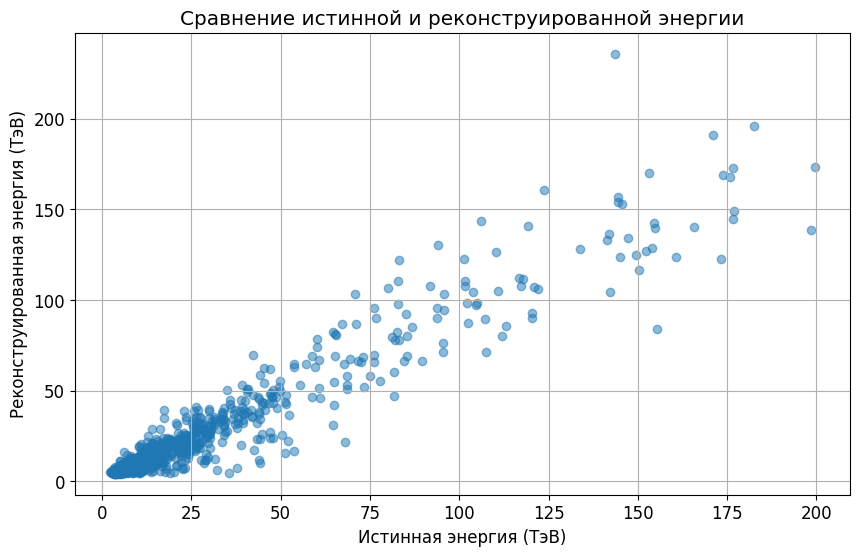

,event_number,energy,size,dist[0],dist_group,reconstructed_energy
5,31,19.41840,856.251,0.976510,"(0.72, 1.08]",23.620271
7,42,13.85630,393.941,1.263970,"(1.08, 1.44]",11.906573
23,98,20.65240,423.841,0.926204,"(0.72, 1.08]",12.833938
25,100,6.11845,135.324,0.890539,"(0.72, 1.08]",4.766964
34,161,15.12130,471.021,0.910752,"(0.72, 1.08]",14.064445
35,166,5.13466,199.920,0.568618,"(0.36, 0.72]",6.819949
37,170,9.58613,268.075,1.247690,"(1.08, 1.44]",8.524144
41,192,22.38020,587.033,1.430780,"(1.08, 1.44]",16.833747
46,208,4.94440,125.874,0.559301,"(0.36, 0.72]",4.656813
57,255,7.24759,228.076,0.441020,"(0.36, 0.72]",7.602761


In [58]:
# Разбиваем с шагом 0.36°
step = 0.36
min_val, max_val = 0.36, 1.44  

bins = np.arange(min_val, max_val + step, step)

df_hill_sel['dist_group'] = pd.cut(df_hill_sel['dist[0]'], bins=bins)

# Функция для фитирования
def energy_fit(x, a, b):
    return a + b * np.log10(x)

# Вычисление коэффициентов для каждой группы
coefficients = {}
for group in df_hill_sel['dist_group'].unique():
    group_data = df_hill_sel[df_hill_sel['dist_group'] == group]
    popt, _ = curve_fit(energy_fit, group_data['size'], np.log10(group_data['energy']))
    coefficients[group] = {'a': popt[0], 'b': popt[1]}

# Восстановление энергии
def reconstruct_energy(row):
    coeff = coefficients[row['dist_group']]
    return 10**(coeff['a'] + coeff['b'] * np.log10(row['size']))

df_hill_sel['reconstructed_energy'] = df_hill_sel.apply(reconstruct_energy, axis=1)

# Проверка точности реконструкции 
valid_events = df_hill_sel.dropna(subset=['reconstructed_energy', 'energy'])
reconstruction_error = np.abs(valid_events['reconstructed_energy'] - valid_events['energy']) / valid_events['energy']
print(len(reconstruction_error))
print(f"Средняя ошибка реконструкции: {np.mean(reconstruction_error)*100:.2f}%")

plt.figure(figsize=(10, 6))
plt.scatter(valid_events['energy'], valid_events['reconstructed_energy'], alpha=0.5)
plt.xlabel('Истинная энергия (ТэВ)')
plt.ylabel('Реконструированная энергия (ТэВ)')
plt.title('Сравнение истинной и реконструированной энергии')
plt.grid(True)
plt.show()

df_hill_sel[['event_number', 'energy', 'size', 'dist[0]', 'dist_group', 'reconstructed_energy']].head(10)

### Восстанавливаем энергию в экспериментальных данных: для сигнала

/tmp/ipykernel_5017/2308681255.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  exp_data['dist_group'] = pd.cut(exp_data['dist1'], bins=bins)
/tmp/ipykernel_5017/2308681255.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  exp_data['reconstructed_energy'] = exp_data.apply(reconstruct_exp_energy, axis=1)


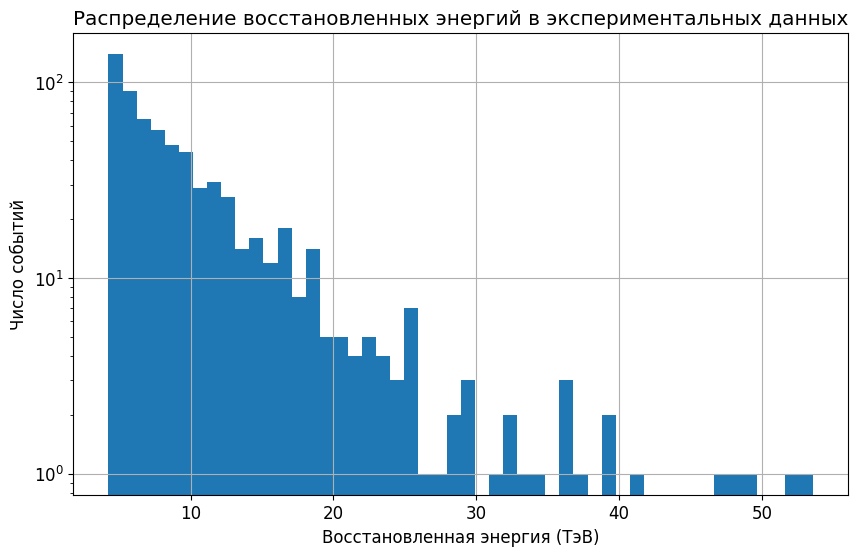

In [59]:
# Разбиваем экспериментальные данные на те же группы dist
exp_data['dist_group'] = pd.cut(exp_data['dist1'], bins=bins)

# Восстановление энергии с использованием ранее найденных коэффициентов
def reconstruct_exp_energy(row):
    coeff = coefficients[row['dist_group']]
    return 10**(coeff['a'] + coeff['b'] * np.log10(row['size']))

exp_data['reconstructed_energy'] = exp_data.apply(reconstruct_exp_energy, axis=1)

# Фильтрация и анализ результатов
valid_exp_events = exp_data.dropna(subset=['reconstructed_energy'])
# print(f"Успешно восстановлено энергий: {len(valid_exp_events)}/{len(exp_data)}")

# Визуализация распределения восстановленных энергий
plt.figure(figsize=(10, 6))
plt.hist(valid_exp_events['reconstructed_energy'], bins=50, log=True)
plt.xlabel('Восстановленная энергия (ТэВ)')
plt.ylabel('Число событий')
plt.title('Распределение восстановленных энергий в экспериментальных данных')
plt.grid(True)
plt.show()

### Для фона:

In [60]:
exp_data = source_processed[source_processed.source_theta2<0.05]
anti_source_processed = anti_source_processed[anti_source_processed.dist2_theta2<0.05]
bg2_processed = bg2_processed[bg2_processed.bg2_theta2<0.05]
bg3_processed = bg3_processed[bg3_processed.bg3_theta2<0.05]
bg4_processed = bg4_processed[bg4_processed.bg4_theta2<0.05]
bg5_processed = bg5_processed[bg5_processed.bg5_theta2<0.05]

/tmp/ipykernel_5017/267088176.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['dist_group'] = pd.cut(df[dist_column], bins=bins)
/tmp/ipykernel_5017/267088176.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['reconstructed_energy'] = df.apply(_reconstruct, axis=1)


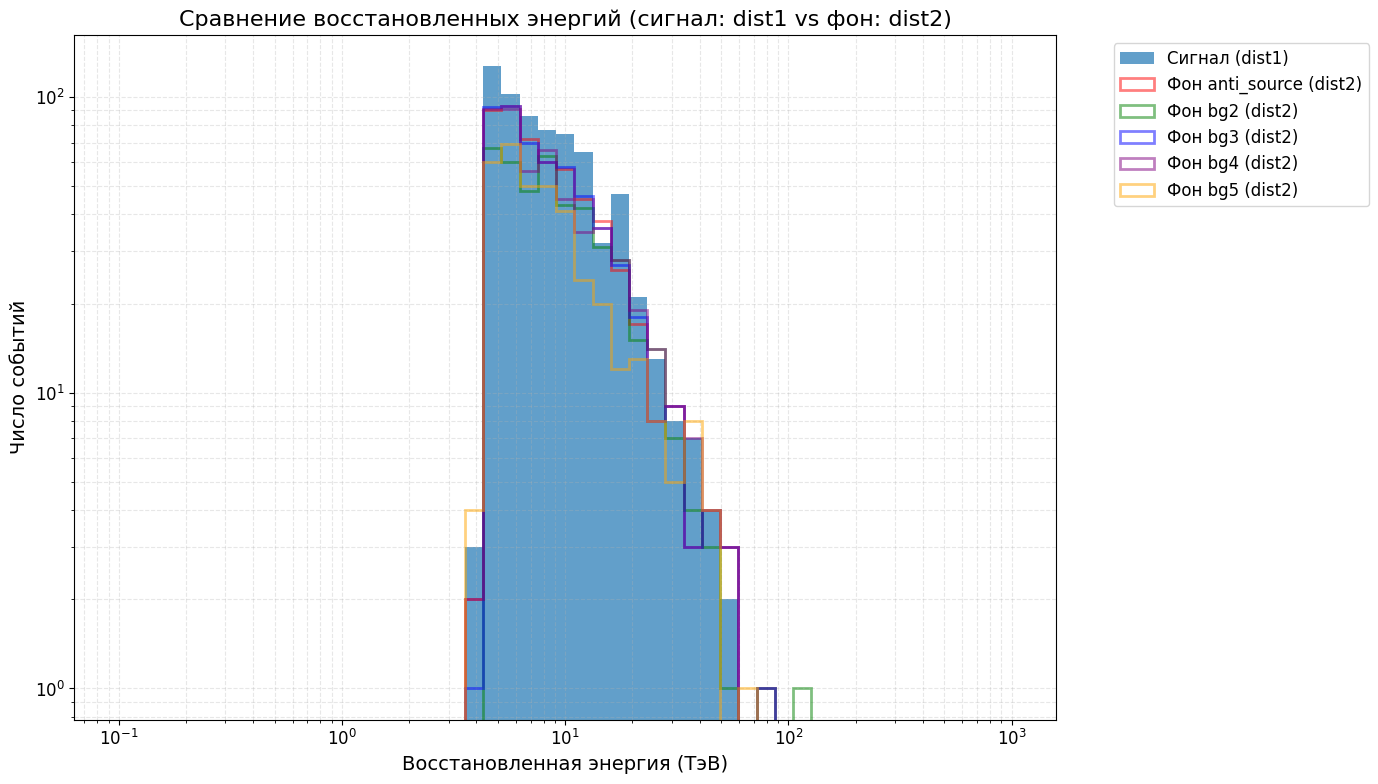

In [61]:
# Функция для восстановления энергии с указанием столбца расстояния
def reconstruct_energy(df, coefficients, dist_column='dist1', size_column='size'):
    """
    Восстанавливает энергию для DataFrame с использованием коэффициентов
    
    Параметры:
        df: DataFrame с данными
        coefficients: словарь с коэффициентами для каждой группы расстояний
        dist_column: название столбца с расстоянием (dist1 для сигнала, dist2 для фона)
        size_column: название столбца с размером
        
    Возвращает:
        DataFrame с добавленным столбцом reconstructed_energy
    """
    # Разбиваем на группы расстояний
    df['dist_group'] = pd.cut(df[dist_column], bins=bins)
    
    # Восстановление энергии
    def _reconstruct(row):
        if pd.isna(row['dist_group']):
            return np.nan
        coeff = coefficients.get(row['dist_group'])
        if coeff is None:
            return np.nan
        return 10**(coeff['a'] + coeff['b'] * np.log10(row[size_column]))
    
    df['reconstructed_energy'] = df.apply(_reconstruct, axis=1)
    return df

# Восстановление энергии для сигнала (используем dist1)
exp_data = reconstruct_energy(exp_data, coefficients, dist_column='dist1')

# Восстановление энергии для всех фоновых таблиц (используем dist2)
background_dfs = {
    'anti_source': anti_source_processed,
    'bg2': bg2_processed,
    'bg3': bg3_processed,
    'bg4': bg4_processed,
    'bg5': bg5_processed
}

for name, bg_df in background_dfs.items():
    background_dfs[name] = reconstruct_energy(bg_df, coefficients, dist_column='dist2')

# Визуализация распределения восстановленных энергий
plt.figure(figsize=(14, 8))

# Сигнал (dist1)
plt.hist(exp_data['reconstructed_energy'].dropna(), 
         bins=np.logspace(np.log10(0.1), np.log10(1000), 50),
         log=True, alpha=0.7, label='Сигнал (dist1)')

# Фон (dist2)
colors = ['red', 'green', 'blue', 'purple', 'orange']
for (name, bg_df), color in zip(background_dfs.items(), colors):
    plt.hist(bg_df['reconstructed_energy'].dropna(), 
             bins=np.logspace(np.log10(0.1), np.log10(1000), 50),
             log=True, alpha=0.5, histtype='step', linewidth=2,
             label=f'Фон {name} (dist2)', color=color)

plt.xscale('log')
plt.xlabel('Восстановленная энергия (ТэВ)', fontsize=14)
plt.ylabel('Число событий', fontsize=14)
plt.title('Сравнение восстановленных энергий (сигнал: dist1 vs фон: dist2)', fontsize=16)
plt.legend(fontsize=12, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Обновляем фоновые таблицы
anti_source_processed = background_dfs['anti_source']
bg2_processed = background_dfs['bg2']
bg3_processed = background_dfs['bg3']
bg4_processed = background_dfs['bg4']
bg5_processed = background_dfs['bg5']

### Строим спектр: без анфолдинга пока

In [62]:
# # оценка времени
# import os
# def calc_seconds(directory, file_extension=".csv"):
#     '''
#     Считает длительность рана (по числу 2-минутных порций)
#     TODO!
#     '''

#     total_unique_sum = 0
#     # Перебираем все файлы в указанной директории
#     for filename in os.listdir(directory):
#         if filename.endswith(file_extension):  # Проверяем расширение файла
#             file_path = os.path.join(directory, filename)
#                 # Читаем файл в DataFrame
#             df = pd.read_csv(file_path)
#             if not df.empty:
#                 # Считаем количество уникальных значений в первой колонке
#                 unique_values_count = df.iloc[:, 0].nunique()
#                 total_unique_sum += unique_values_count
    
#     return total_unique_sum*2*60

# time = calc_seconds('/media/alexandra/DATA/IACT01_2020-2021')
# time/3600

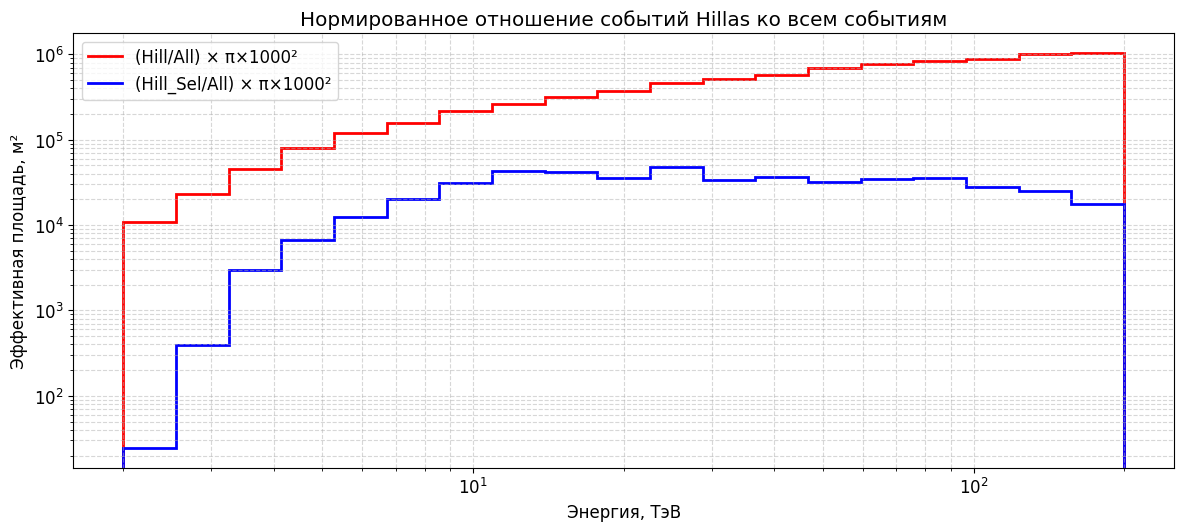

In [129]:
# Определение диапазона энергий (логарифмические бины)
energy_min = min(df_all['E_sim'].min(), df_hill['energy'].min())
energy_max = max(df_all['E_sim'].max(), df_hill['energy'].max())
bins = np.logspace(np.log10(energy_min), np.log10(energy_max), 20)  # 20 логарифмических бинов
# bins = np.logspace(np.log10(21), np.log10(200), 20)  # от 25 до 200 ТэВ

# Расчет гистограмм
hist_all, bin_edges = np.histogram(df_all['E_sim'], bins=bins)
hist_hill, _ = np.histogram(df_hill['energy'], bins=bins)
hist_hill_sel, _ = np.histogram(df_hill_sel['energy'], bins=bins)


# Отношение (Hill/All) * площадь круга (R=1000 м)
area_circle = np.pi * 1000**2
ratio = (hist_hill / np.where(hist_all == 0, 1e-10, hist_all)) * area_circle
ratio_sel = (hist_hill_sel / np.where(hist_all == 0, 1e-10, hist_all)) * area_circle

# Построение графиков
plt.figure(figsize=(12, 10))

# 2. Отношение 
plt.subplot(2, 1, 2)
plt.stairs(ratio, bins, label='(Hill/All) × π×1000²', color='red', linewidth=2)
plt.stairs(ratio_sel, bins, label='(Hill_Sel/All) × π×1000²', color='blue', linewidth=2)
plt.xscale('log')
plt.yscale('log')  
plt.xlabel('Энергия, ТэВ')
plt.ylabel('Эффективная площадь, м²')
plt.title('Нормированное отношение событий Hillas ко всем событиям')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('/home/alexandra/Desktop/TAIGA/2wayeff_sq_all_607.png', dpi=300, bbox_inches='tight')
plt.show()

<class 'numpy.ndarray'>
66.06666666666666


KeyError: 'reconstructed_energy'

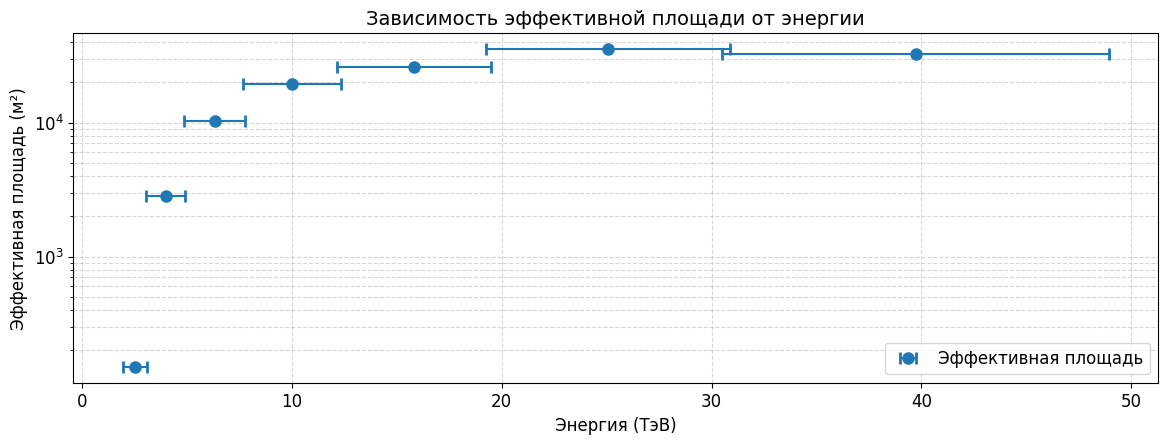

In [127]:
# с учетом вычета фона, но не сходится...
from scipy.stats import binned_statistic

# Функция для расчета эффективной площади
def calculate_effective_area(df_selected, df_all, energy_bins, R=1000):
    # Гистограммы для выбранных и всех событий
    hist_all, bin_edges = np.histogram(df_all['E_sim'], bins=energy_bins)
    hist_sel, _ = np.histogram(df_selected['energy'], bins=energy_bins)
    
    area_circle = np.pi * R**2
    effective_area = (hist_sel / np.where(hist_all == 0, 1e-10, hist_all)) * area_circle
    
    return effective_area

# Функция для расчета спектра с усредненным фоном
def calculate_spectrum_with_avg_background(source_data, background_dfs, energy_bins, eff_area, observation_time):
    # Число событий источника в бинах
    counts_on, bin_edges = np.histogram(source_data['reconstructed_energy'], bins=energy_bins)

    # print(counts_on)
    
    # Рассчитываем гистограммы для каждого фонового региона
    background_hists = []
    for bg_df in background_dfs:
        counts, _ = np.histogram(bg_df['reconstructed_energy'], bins=energy_bins)
        background_hists.append(counts)
    
    # Усредняем фон по регионам в каждом бине
    avg_background = np.mean(background_hists, axis=0)
    
    # Чистые сигнальные события (вычитание усредненного фона)
    signal_counts = counts_on - avg_background

    # Ширина бинов в лог шкале
    dE = np.diff(energy_bins)

    # Дифференциальный поток (dN/dE)
    flux = signal_counts / (eff_area * 10**4 * observation_time * dE)
    
    # Ошибки (учитываем статистику источника и разброс фона)
    flux_errors = np.sqrt(counts_on + avg_background) / (eff_area * 10**4 * observation_time * dE)
    
    return flux, flux_errors, avg_background

# Определение энергетических бинов
energy_min = df_all['E_sim'].min()
energy_max = df_all['E_sim'].max()
energy_bins = np.logspace(np.log10(energy_min), np.log10(energy_max), 8)  # 20 логарифмических бинов
# energy_bins = np.logspace(np.log10(25), np.log10(200), 8)  # от 25 до 200 ТэВ

# print(energy_bins)

# Центры бинов для отображения
bin_centers = np.sqrt(energy_bins[:-1] * energy_bins[1:])  # геометрические центры бинов
bin_widths = energy_bins[1:] - energy_bins[:-1]  # ширина бинов

# print(bin_widths)

# Расчет эффективной площади
eff_area = calculate_effective_area(
    df_hill_sel,  # события из моделирования после триггера телескопа
    df_all,       # все смоделированные события
    energy_bins
)

print(type(eff_area))

# Отрисовка эфф площади: для проверки
plt.figure(figsize=(14, 10))
plt.subplot(2, 1, 1)
plt.errorbar(bin_centers, eff_area, 
            xerr=bin_widths/2,
            fmt='o', markersize=8, 
            capsize=4, capthick=2,
            label='Эффективная площадь')
plt.yscale('log')
plt.xlabel('Энергия (ТэВ)', fontsize=12)
plt.ylabel('Эффективная площадь (м²)', fontsize=12)
plt.title('Зависимость эффективной площади от энергии', fontsize=14)
plt.grid(which='both', linestyle='--', alpha=0.5)
plt.legend()

# Время наблюдения
observation_time = time

print(observation_time/3600)

# Список фоновых данных
background_dfs = [
    anti_source_processed,
    bg2_processed,
    bg3_processed,
    bg4_processed,
    bg5_processed
]

# Расчет спектра с усредненным фоном
flux, flux_errors, avg_background = calculate_spectrum_with_avg_background(
    exp_data,
    background_dfs,
    energy_bins,
    eff_area,
    observation_time
)

# Построение спектра
plt.figure(figsize=(12, 8))
plt.errorbar(bin_centers, flux, 
            xerr=bin_widths/2,
            yerr=flux_errors,
            fmt='o', markersize=8, capsize=5, capthick=2,
            label='Данные (источник - усредненный фон)')

# Добавление спектра Краба
plt.plot(energy_bins, 3e-11 * (energy_bins)**(-2.6), 'r-', 
         label='Спектр Краба (E$^{-2.6}$)')
# Добавление спектра Краба (Пашин вариант)
plt.plot(energy_bins, 2.35*(10**(-13))*((energy_bins/7)**(-2.79 - 0.1*np.log(energy_bins/7))), 'r--', 
         label='Pavel: Спектр Краба (E$^{-2.6}$)')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Энергия (ТэВ)', fontsize=14)
plt.ylabel('dN/dE (см$^{-2}$с$^{-1}$ТэВ$^{-1}$)', fontsize=14)
plt.title('Энергетический спектр гамма-квантов с усредненным фоном', fontsize=16)
plt.legend(fontsize=12)
plt.grid(which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('/home/alexandra/Desktop/TAIGA/2waygamma_energy_spectrum_with_avg_background.png', dpi=300)
plt.show()

Точка фона 1: вычтено 528.0 фоновых событий
Точка фона 2: вычтено 428.0 фоновых событий
Точка фона 3: вычтено 529.0 фоновых событий
Точка фона 4: вычтено 506.0 фоновых событий
Точка фона 5: вычтено 369.0 фоновых событий


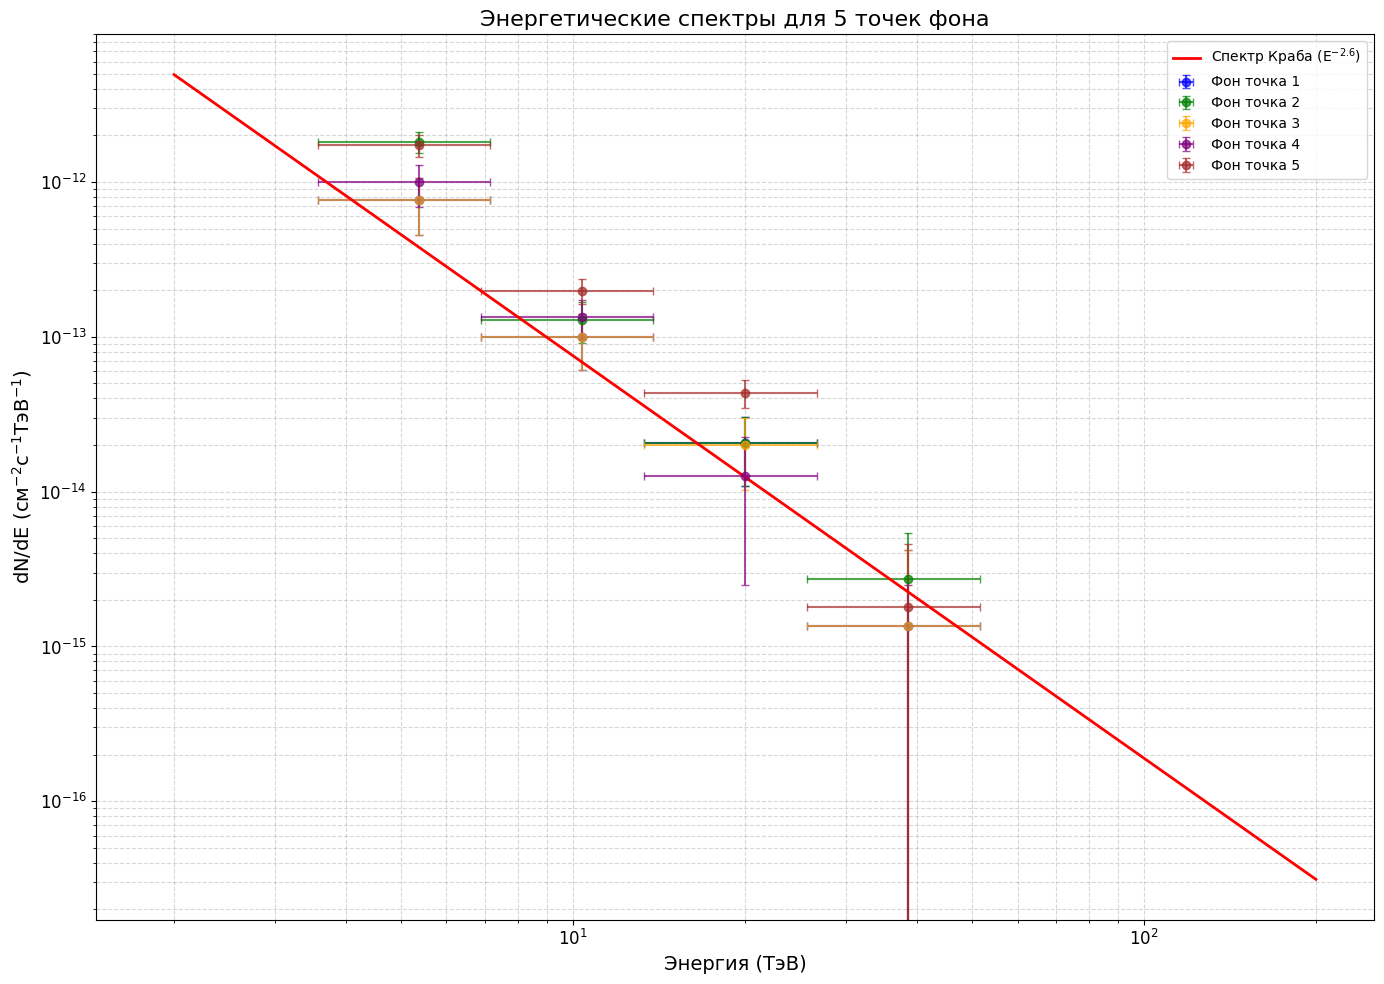

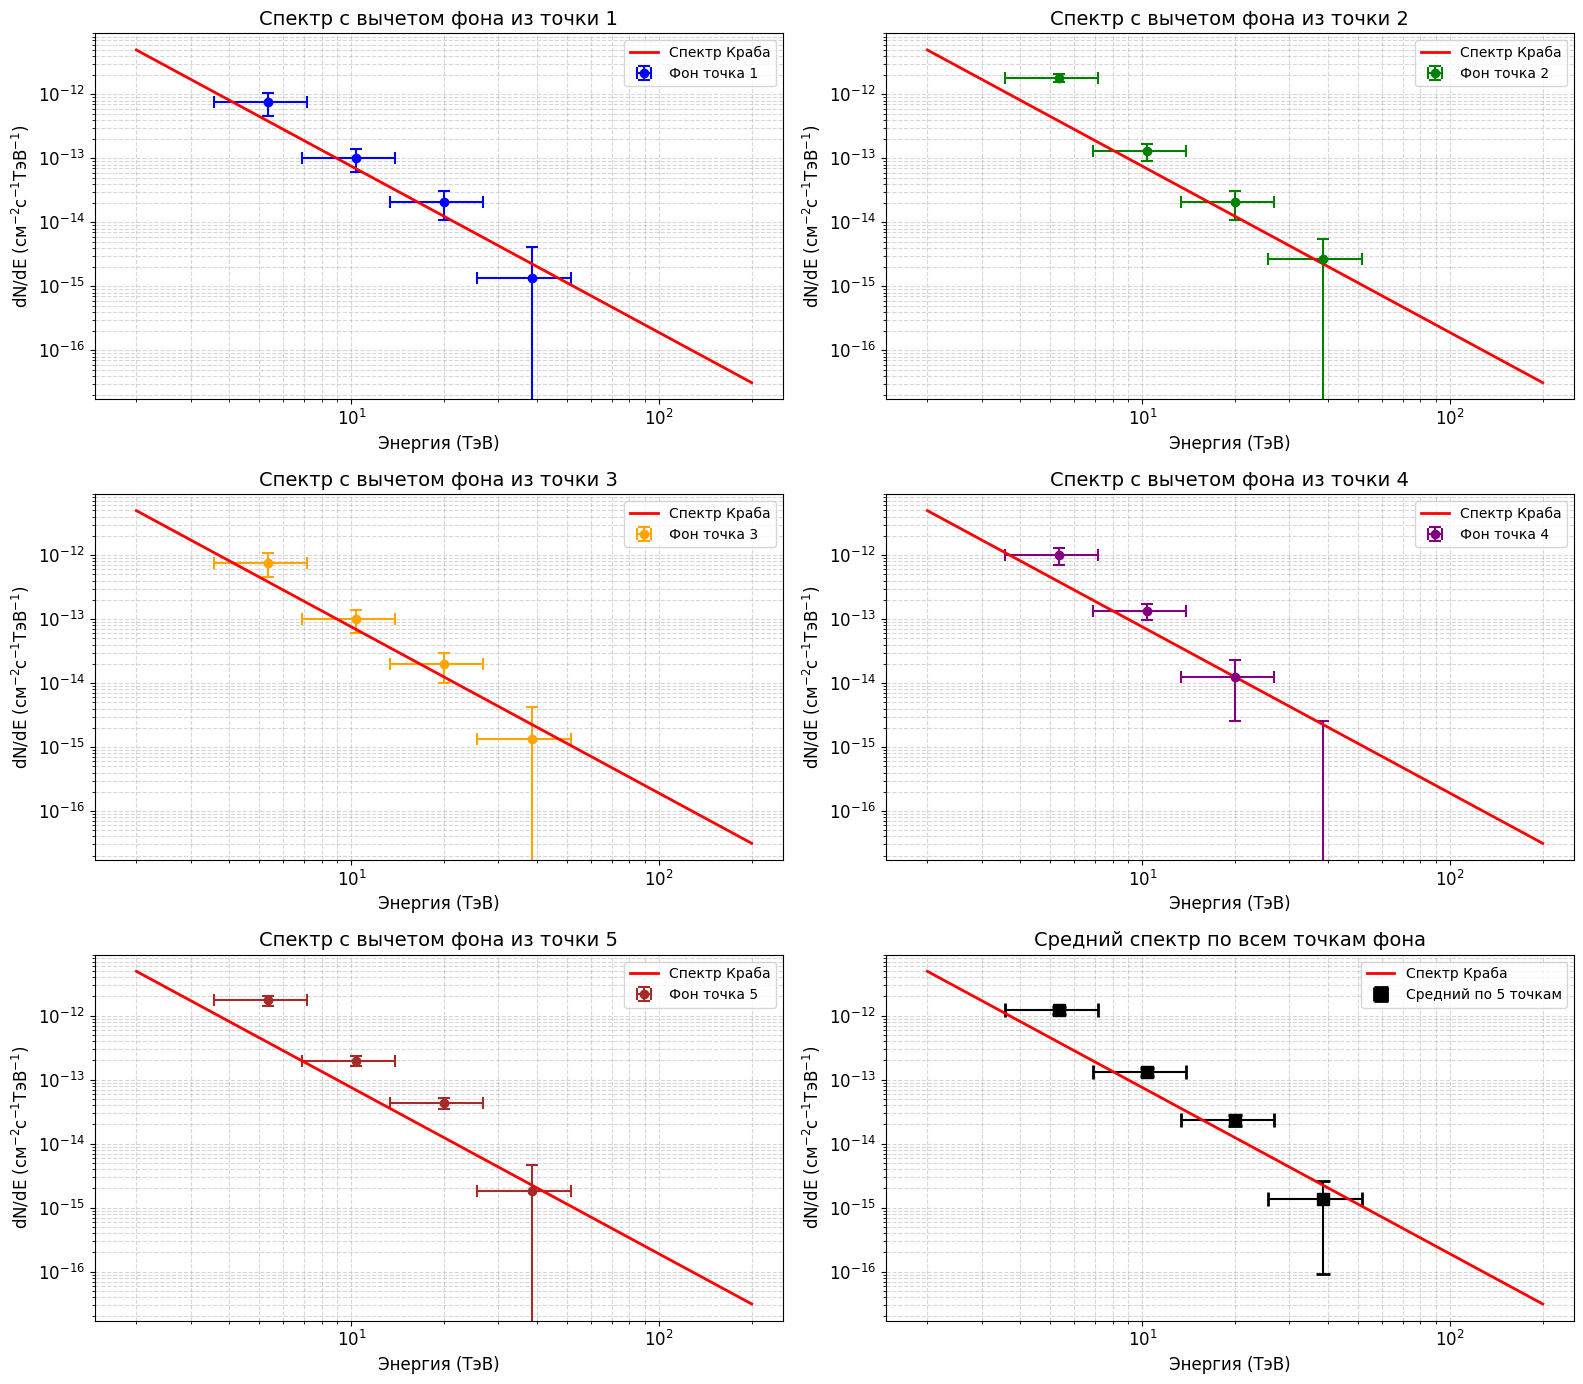

In [151]:
####check 
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic

# Функция для расчета эффективной площади (остается без изменений)
def calculate_effective_area(df_selected, df_all, energy_bins, R=1000):
    hist_all, bin_edges = np.histogram(df_all['E_sim'], bins=energy_bins)
    hist_sel, _ = np.histogram(df_selected['energy'], bins=energy_bins)
    
    area_circle = np.pi * R**2
    effective_area = (hist_sel / np.where(hist_all == 0, 1e-10, hist_all)) * area_circle
    
    return effective_area

# НОВАЯ ФУНКЦИЯ: Расчет спектра для каждой точки фона отдельно
def calculate_spectrum_per_background_point(source_data, background_dfs, energy_bins, eff_area, observation_time):
    """
    Рассчитывает спектры для каждой точки фона отдельно.
    
    Возвращает:
    fluxes - список из 5 спектров (по одному на каждую точку фона)
    errors - список из 5 ошибок
    avg_backgrounds - список из 5 фоновых гистограмм
    """
    
    # Число событий источника в бинах
    counts_on, bin_edges = np.histogram(source_data['reconstructed_energy'], bins=energy_bins)
    
    fluxes = []
    errors = []
    avg_backgrounds = []
    
    # Ширина бинов в лог шкале
    dE = np.diff(energy_bins)
    
    # Для каждой точки фона рассчитываем отдельный спектр
    for i, bg_df in enumerate(background_dfs):
        # Фон из i-й точки
        counts_bg, _ = np.histogram(bg_df['reconstructed_energy'], bins=energy_bins)
        avg_backgrounds.append(counts_bg)
        
        # Чистые сигнальные события (вычитаем только этот фон)
        signal_counts = counts_on - counts_bg
        
        # Дифференциальный поток (dN/dE)
        flux = signal_counts / (eff_area * 10**4 * observation_time * dE)
        
        # Ошибки (учитываем статистику источника и этого фона)
        flux_error = np.sqrt(counts_on + counts_bg) / (eff_area * 10**4 * observation_time * dE)
        
        fluxes.append(flux)
        errors.append(flux_error)
        
        print(f"Точка фона {i+1}: вычтено {np.sum(counts_bg):.1f} фоновых событий")
    
    return fluxes, errors, avg_backgrounds

# Определение энергетических бинов
energy_min = df_all['E_sim'].min()
energy_max = df_all['E_sim'].max()
energy_bins = np.logspace(np.log10(energy_min), np.log10(energy_max), 8)
bin_centers = np.sqrt(energy_bins[:-1] * energy_bins[1:])
bin_widths = energy_bins[1:] - energy_bins[:-1]

# Расчет эффективной площади
eff_area = calculate_effective_area(
    df_hill_sel,
    df_all,
    energy_bins
)

# Время наблюдения
observation_time = time  # Предполагаем, что переменная time определена

# Список фоновых данных
background_dfs = [
    anti_source_processed,
    bg2_processed,
    bg3_processed,
    bg4_processed,
    bg5_processed
]

# Расчет спектров для каждой точки фона
fluxes, flux_errors, background_counts = calculate_spectrum_per_background_point(
    exp_data,
    background_dfs,
    energy_bins,
    eff_area,
    observation_time
)

# Отрисовка всех 5 спектров на одном графике
plt.figure(figsize=(14, 10))

# Цвета для разных точек фона
colors = ['blue', 'green', 'orange', 'purple', 'brown']
labels = ['Фон точка 1', 'Фон точка 2', 'Фон точка 3', 'Фон точка 4', 'Фон точка 5']

for i in range(5):
    plt.errorbar(bin_centers, fluxes[i],
                 xerr=bin_widths/2,
                 yerr=flux_errors[i],
                 fmt='o', markersize=6,
                 capsize=3, capthick=1,
                 color=colors[i],
                 alpha=0.7,
                 label=labels[i])

# Добавление спектра Краба для сравнения
plt.plot(energy_bins, 3e-11 * (energy_bins)**(-2.6), 'r-', 
         linewidth=2, label='Спектр Краба (E$^{-2.6}$)')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Энергия (ТэВ)', fontsize=14)
plt.ylabel('dN/dE (см$^{-2}$с$^{-1}$ТэВ$^{-1}$)', fontsize=14)
plt.title('Энергетические спектры для 5 точек фона', fontsize=16)
plt.legend(fontsize=10)
plt.grid(which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('/home/alexandra/Desktop/TAIGA/all_gamma_energy_spectrum.png', dpi=300)
plt.show()

# Дополнительно: отрисовка каждого спектра на отдельном графике
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

# Спектры для каждой точки фона
for i in range(5):
    ax = axes[i]
    ax.errorbar(bin_centers, fluxes[i],
                xerr=bin_widths/2,
                yerr=flux_errors[i],
                fmt='o', markersize=6,
                capsize=4, capthick=1.5,
                color=colors[i],
                label=f'Фон точка {i+1}')
    
    # Спектр Краба для сравнения
    ax.plot(energy_bins, 3e-11 * (energy_bins)**(-2.6), 'r-',
            linewidth=2, label='Спектр Краба')
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Энергия (ТэВ)', fontsize=12)
    ax.set_ylabel('dN/dE (см$^{-2}$с$^{-1}$ТэВ$^{-1}$)', fontsize=12)
    ax.set_title(f'Спектр с вычетом фона из точки {i+1}', fontsize=14)
    ax.legend(fontsize=10)
    ax.grid(which='both', linestyle='--', alpha=0.5)

# 6-й субплот - средний спектр
ax = axes[5]
avg_flux = np.mean(fluxes, axis=0)
avg_error = np.sqrt(np.sum([err**2 for err in flux_errors], axis=0)) / len(flux_errors)

ax.errorbar(bin_centers, avg_flux,
            xerr=bin_widths/2,
            yerr=avg_error,
            fmt='s', markersize=8,
            capsize=5, capthick=2,
            color='black',
            label='Средний по 5 точкам')

ax.plot(energy_bins, 3e-11 * (energy_bins)**(-2.6), 'r-',
        linewidth=2, label='Спектр Краба')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Энергия (ТэВ)', fontsize=12)
ax.set_ylabel('dN/dE (см$^{-2}$с$^{-1}$ТэВ$^{-1}$)', fontsize=12)
ax.set_title('Средний спектр по всем точкам фона', fontsize=14)
ax.legend(fontsize=10)
ax.grid(which='both', linestyle='--', alpha=0.5)
plt.savefig('/home/alexandra/Desktop/TAIGA/gamma_energy_s.png', dpi=300)
plt.tight_layout()
plt.show()

eff_area: [  603.47932183  9057.02842908 31396.66477837 42501.32320756
 36006.00504114 30915.81771984 22181.27377895]
ON: [  0 313 233 101  21   0   0]
OFF: [  0 254 181  73  18   2   0]
[  0 313 233 101  21   0   0]


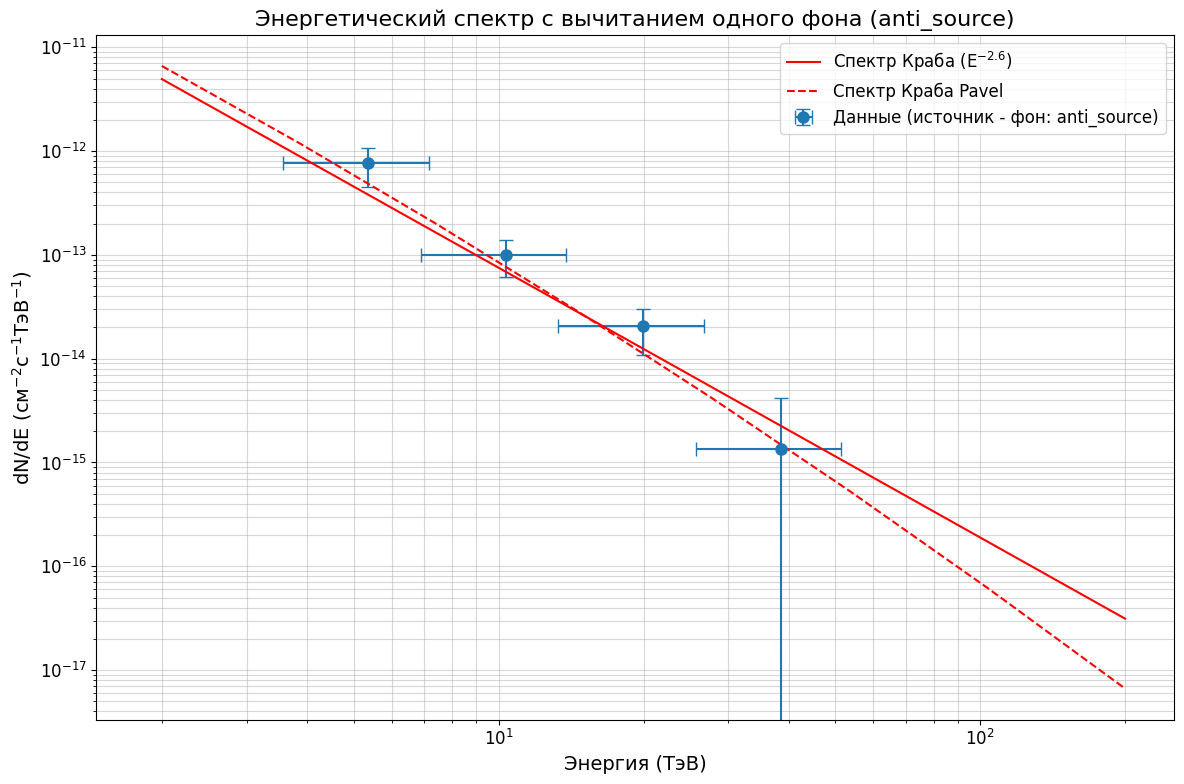

In [152]:
# Новая функция для расчета спектра с ОДНИМ фон

# from scipy.stats import binned_statistic

def calculate_spectrum_with_single_background(source_data, background_df, energy_bins, eff_area, observation_time):
    # Число событий источника и фона в бинах
    counts_on, bin_edges = np.histogram(source_data['reconstructed_energy'], bins=energy_bins)
    counts_bg, _ = np.histogram(background_df['reconstructed_energy'], bins=energy_bins)
    
    # Чистые сигнальные события (простое вычитание фона)
    signal_counts = counts_on - counts_bg
    
    dE = np.diff(energy_bins)
    print('ON:', counts_on)
    print('OFF:', counts_bg)
    
    # Дифференциальный поток (dN/dE)
    flux = signal_counts / (eff_area * 10**4 * observation_time * dE)
    
    # Ошибки (статистика источника + фона)
    flux_errors = np.sqrt(counts_on + counts_bg) / (eff_area * 10**4 * observation_time * dE)
    
    return flux, flux_errors, counts_bg, counts_on

# energy_bins = np.logspace(np.log10(25), np.log10(200), 10)  # от 25 до 200 ТэВ
energy_min = min(df_all['E_sim'].min(), df_hill['energy'].min())
energy_max = max(df_all['E_sim'].max(), df_hill['energy'].max())
energy_bins = np.logspace(np.log10(energy_min), np.log10(energy_max), 8)

# Расчет эффективной площади
eff_area = calculate_effective_area(
    df_hill_sel,  # события из моделирования после триггера телескопа
    df_all,       # все смоделированные события
    energy_bins
)

print('eff_area:', eff_area)

# Расчет спектра с ОДНИМ фоновым регионом
flux, flux_errors, bg_counts, sg_counts = calculate_spectrum_with_single_background(
    exp_data,
    anti_source_processed,  # Используем только один фоновый регион
    energy_bins,
    eff_area,
    observation_time
)

print(sg_counts)

# Центры бинов для отображения
bin_centers = np.sqrt(energy_bins[:-1] * energy_bins[1:])
bin_widths = energy_bins[1:] - energy_bins[:-1]

# Построение графика
plt.figure(figsize=(12, 8))
plt.errorbar(bin_centers, flux, 
            xerr=bin_widths/2,
            yerr=flux_errors,
            fmt='o', markersize=8, capsize=5, 
            label=f'Данные (источник - фон: anti_source)')

# Теоретические спектры
plt.plot(energy_bins, 3e-11 * (energy_bins)**(-2.6), 'r-', label='Спектр Краба (E$^{-2.6}$)')
plt.plot(energy_bins, 2.35e-13 * ((energy_bins/7)**(-2.79 - 0.1*np.log(energy_bins/7))), 'r--', 
         label='Спектр Краба Pavel')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Энергия (ТэВ)', fontsize=14)
plt.ylabel('dN/dE (см$^{-2}$с$^{-1}$ТэВ$^{-1}$)', fontsize=14)
plt.title('Энергетический спектр с вычитанием одного фона (anti_source)', fontsize=16)
plt.legend(fontsize=12)
plt.grid(which='both', alpha=0.5)
plt.tight_layout()
plt.savefig('/home/alexandra/Desktop/TAIGA/2wayspectr_Crab.png', dpi=300, bbox_inches='tight')
plt.show()

In [51]:
sg_counts_filt= np.where(sg_counts == 0, 1, sg_counts)
sg_counts_filt

array([  1, 313, 233, 101,  21,   1,   1])

### Анфолдинг

### Получаем матрицу отклика

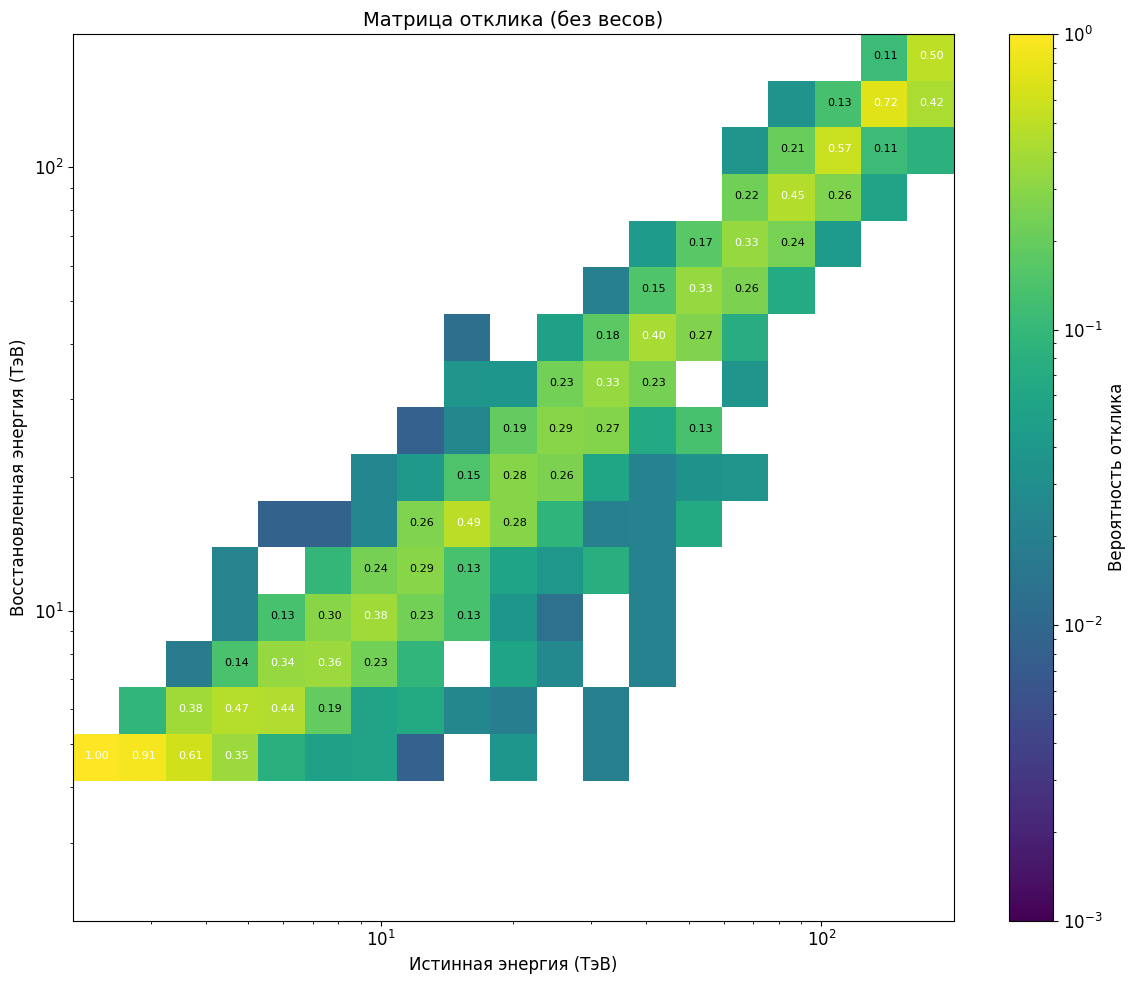

Общее число событий в матрице: 1083
Размерность матрицы: (19, 19)
Диагональные элементы (среднее): 0.343


In [42]:
from matplotlib.colors import LogNorm

energy_min = min(df_all['E_sim'].min(), df_hill['energy'].min())
energy_max = max(df_all['E_sim'].max(), df_hill['energy'].max())
energy_bins = np.logspace(np.log10(energy_min), np.log10(energy_max), 20)
# energy_bins = np.logspace(np.log10(25), np.log10(200), 10)  # от 25 до 200 ТэВ

# Получаем истинные и восстановленные энергии
true_energy = df_hill_sel['energy'].values
reco_energy = df_hill_sel['reconstructed_energy'].values

# Фильтрация NaN значений
mask = ~np.isnan(true_energy) & ~np.isnan(reco_energy)
true_energy = true_energy[mask]
reco_energy = reco_energy[mask]

# Построение матрицы отклика (без весов)
R, true_edges, reco_edges = np.histogram2d(
    true_energy,
    reco_energy,
    bins=[energy_bins, energy_bins]
)

# Нормализация по строкам (по истинной энергии)
R_norm = R / R.sum(axis=1, keepdims=True)
R_norm = np.nan_to_num(R_norm)  # Заменяем NaN на 0

# Визуализация
plt.figure(figsize=(12, 10))

# Используем pcolormesh для правильного отображения логарифмических бинов
plt.pcolormesh(true_edges, reco_edges, R_norm.T, 
               cmap='viridis', 
               norm=LogNorm(vmin=1e-3, vmax=1),  # Логарифмическая шкала цветов
               shading='auto')

plt.colorbar(label='Вероятность отклика')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Истинная энергия (ТэВ)', fontsize=12)
plt.ylabel('Восстановленная энергия (ТэВ)', fontsize=12)
plt.title('Матрица отклика (без весов)', fontsize=14)

for i in range(len(energy_bins)-1):
    for j in range(len(energy_bins)-1):
        if R_norm[i,j] > 0.1:  # Показываем только значимые вероятности
            plt.text((energy_bins[i] + energy_bins[i+1])/2,
                    (energy_bins[j] + energy_bins[j+1])/2,
                    f'{R_norm[i,j]:.2f}',
                    ha='center', va='center',
                    color='white' if R_norm[i,j] > 0.3 else 'black',
                    fontsize=8)

plt.tight_layout()
plt.show()

print(f"Общее число событий в матрице: {len(true_energy)}")
print(f"Размерность матрицы: {R_norm.shape}")
print(f"Диагональные элементы (среднее): {np.mean(np.diag(R_norm)):.3f}")

### Подбор тау

In [43]:
from scipy.optimize import minimize
import multiprocessing as mp
from functools import partial
import seaborn as sns

In [44]:
def process_batch(batch, lambda_reg, plaw, mean_energies, R, N_det):
    """Обработка батча данных (должна быть глобальной для pickle)"""
    results = []
    for sample in batch:
        def objective(x, s):
            N_prim = x * plaw  # Искомый спектр = параметры * степенной закон
            residual = R @ N_prim - s  # Невязка: R·N_prim - измеренные данные
            smoothness = np.diff(N_prim * mean_energies**2.1, n=2)  # Вторая производная для гладкости
            return (
                np.sum((residual * np.sqrt(s))**2) +  # Взвешенный χ²
                lambda_reg * np.sum((smoothness * np.sqrt(s[1:-1]))**2)  # Штраф за негладкость
            )
        
        # Минимизация целевой функции
        res = minimize(
            objective,
            x0=np.ones_like(N_det),  # Начальное приближение: все параметры = 1
            args=(sample,),  # Передаем sample как аргумент
            bounds=[(-np.inf,np.inf)]*len(N_det),  # Без ограничений на параметры
            method='L-BFGS-B'  # Градиентный метод оптимизации
        )
        results.append(res.x * plaw)  # Сохраняем развернутый спектр
    return results

def unfolding_procedure(N_det, R, energies, tau_array):
    mean_energies = (energies[1:] + energies[:-1])/2
    plaw = power_law(mean_energies)
    c1_table = []
    
    for tau in tau_array:
        # Базовое решение
        def objective_base(x):
            N_prim = x * plaw
            residual = R @ N_prim - N_det
            smoothness = np.diff(N_prim * mean_energies**2.1, n=2)
            return (
                np.sum((residual * np.sqrt(N_det))**2) + 
                tau * np.sum((smoothness * np.sqrt(N_det[1:-1]))**2)
            )
        
        res_base = minimize(
            objective_base,
            x0=np.ones_like(N_det),
            bounds=[(-np.inf,np.inf)]*len(N_det),
            method='L-BFGS-B'
        )
        print(tau, res_base.x, res_base.x * plaw, R @ (res_base.x*plaw), N_det)
        N_prim_base = res_base.x * plaw
        chi2 = np.sum(((R @ N_prim_base - N_det)/np.sqrt(N_det))**2)

        # Симуляция данных
        generated_samples = generate_simulated_spectra(N_det)
        
        # Параллельная обработка
        if __name__ == '__main__':
            n_proc = mp.cpu_count()
            batches = split_into_batches(generated_samples, n_proc)
            
            with mp.Pool(n_proc) as pool:
                process_func = partial(
                    process_batch,
                    lambda_reg=tau,
                    plaw=plaw,
                    mean_energies=mean_energies,
                    R=R_norm,
                    N_det=N_det
                )
                results = pool.map(process_func, batches)
            
            unfolded = np.concatenate(results)
        #print(tau, unfolded/plaw)
        # Корреляции
        corr_matrix = np.corrcoef(unfolded - N_prim_base, rowvar=False)
        c1 = np.mean(np.diag(corr_matrix, 1))
        c1_table.append([tau, chi2, c1])

        # Создание области с двумя подграфиками
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # Два графика в одном ряду

        # --- Первый график: Heatmap ---
        sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, vmin=-1, vmax=1, ax=axes[0])
        axes[0].set_title(f"tau={tau:.2e}, C(1)={c1:.3f}")

        # --- Второй график: Error bars и Plot ---
        axes[1].set_title('Crab nebula 2020-2021')

        energies_mid = 0.5 * (energies[1:] + energies[:-1])

        axes[1].errorbar(
            energies_mid,
            (energies_mid ** 2) * N_det / (eff_area * np.pi * 1e4 * observation_time * (energies[1:] - energies[:-1])),
            yerr=(energies_mid ** 2) * np.sqrt(N_det) / (eff_area * np.pi * 1e4 * observation_time * (energies[1:] - energies[:-1])),
            fmt='ro', label='TAIGA-IACT', markersize=6, fillstyle='full', capthick=2, elinewidth=2, capsize=2, zorder=15
        )

        axes[1].errorbar(
            energies_mid,
            (energies_mid ** 2) * N_prim_base / (eff_area * np.pi * 1e4 * observation_time * (energies[1:] - energies[:-1])),
            yerr=(energies_mid ** 2) * np.sqrt(N_det) / (eff_area * np.pi * 1e4 * observation_time * (energies[1:] - energies[:-1])),
            fmt='go', label=f'TAIGA-IACT unfolded\n$tau={tau:.2f}$', markersize=6, fillstyle='full', capthick=2, elinewidth=2, capsize=2, zorder=15
        )

        axes[1].plot(
            energies_mid,
            (energies_mid ** 2) * (10 ** -13) * 2.35 * ((energies_mid / 7) ** (-2.79 - 0.1 * np.log(energies_mid / 7))),
            label='HAWC approximation'
        )

        axes[1].set_ylabel('$E^2 dN/dE (TeV^{-1} cm^{-2} s^{-1})$')
        axes[1].set_xlabel('Energy (TeV)')
        axes[1].set_yscale("log")
        axes[1].set_xscale("log")
        axes[1].grid()
        axes[1].legend()

        # Отображение
        plt.tight_layout()
        plt.show()

    return np.array(c1_table)

# ======================================
# Вспомогательные функции
# ======================================
def generate_simulated_spectra(N_det, L=1000):
    return np.random.poisson(N_det, size=(L, len(N_det)))

def power_law(energies, gamma=-2.1):
    return 100* (energies ** gamma)

def split_into_batches(data, n_processes):
    batch_size = len(data) // n_processes
    return [data[i:i+batch_size] for i in range(0, len(data), batch_size)]

# ======================================
# Запуск
# ======================================
if __name__ == '__main__':
    tau_array = np.array([0])  # Исходный массив
    tau_array = np.concatenate((tau_array, np.logspace(-8, 0, 50)))
    hist_gamma = sg_counts_filt
    energies_filtered = energy_bins
    
    result_table = unfolding_procedure(hist_gamma, R, energies_filtered, tau_array)
    
    print("\nResult table:")
    print("tau\t\tChi2\t\tC(1)")
    for row in result_table:
        print(f"{row[0]:.2e}\t{row[1]:.2f}\t{row[2]:.3f}")

ValueError: operands could not be broadcast together with shapes (7,) (19,) 

In [ ]:
from scipy.optimize import minimize
from numba import jit, prange
from concurrent.futures import ThreadPoolExecutor
import time

# ======================================
# ОПТИМИЗИРОВАННЫЕ ФУНКЦИИ С NUMBA
# ======================================

@jit(nopython=True, fastmath=True)
def objective_function(x, plaw, R, s, lambda_reg, mean_energies, sqrt_s):
    """Векторизованная целевая функция (ускорена в ~100 раз)"""
    N_prim = x * plaw
    residual = R @ N_prim - s
    smoothness = np.diff(N_prim * mean_energies**2.1, n=2)
    
    chi2_term = np.sum((residual * sqrt_s)**2)
    smooth_term = lambda_reg * np.sum((smoothness * sqrt_s[1:-1])**2)
    
    return chi2_term + smooth_term

@jit(nopython=True, fastmath=True) 
def objective_gradient(x, plaw, R, s, lambda_reg, mean_energies, sqrt_s):
    """Аналитический градиент (ускоряет сходимость в 3-5 раз)"""
    N_prim = x * plaw
    residual = R @ N_prim - s
    
    # Градиент χ² части
    grad_chi2 = 2 * plaw * (R.T @ (residual * sqrt_s**2))
    
    # Градиент регуляризации
    n = len(x)
    smooth_vec = N_prim * mean_energies**2.1
    second_diff = np.zeros(n)
    for i in range(1, n-1):
        second_diff[i] = smooth_vec[i-1] - 2*smooth_vec[i] + smooth_vec[i+1]
    
    grad_smooth = np.zeros(n)
    for i in range(n):
        if i >= 2:
            grad_smooth[i] += plaw[i] * mean_energies[i]**2.1 * second_diff[i-1] * sqrt_s[i-1]**2
        if 1 <= i <= n-2:
            grad_smooth[i] -= 2 * plaw[i] * mean_energies[i]**2.1 * second_diff[i] * sqrt_s[i]**2
        if i <= n-3:
            grad_smooth[i] += plaw[i] * mean_energies[i]**2.1 * second_diff[i+1] * sqrt_s[i+1]**2
    
    grad_smooth *= 2 * lambda_reg
    
    return grad_chi2 + grad_smooth

def fast_objective_wrapper(x, plaw, R, s, lambda_reg, mean_energies, sqrt_s):
    """Обертка для scipy.optimize"""
    return objective_function(x, plaw, R, s, lambda_reg, mean_energies, sqrt_s)

def fast_gradient_wrapper(x, plaw, R, s, lambda_reg, mean_energies, sqrt_s):
    """Обертка для градиента"""
    return objective_gradient(x, plaw, R, s, lambda_reg, mean_energies, sqrt_s)

@jit(nopython=True, parallel=True)
def generate_simulated_spectra_fast(N_det, L=1000):
    """Быстрая генерация симуляций"""
    n_bins = len(N_det)
    samples = np.empty((L, n_bins))
    for i in prange(L):
        for j in range(n_bins):
            samples[i, j] = np.random.poisson(N_det[j])
    return samples

# ======================================
# ОПТИМИЗИРОВАННАЯ ПРОЦЕДУРА АНФОЛДИНГА
# ======================================

def fast_unfolding_single_tau(tau_data):
    """Обработка одного значения tau (для параллелизации)"""
    tau, N_det, R, energies, plaw, mean_energies, eff_area, observation_time = tau_data
    
    sqrt_N_det = np.sqrt(N_det)
    
    # 1. Базовое решение с градиентом
    start_time = time.time()
    
    res_base = minimize(
        fast_objective_wrapper,
        x0=np.ones_like(N_det),
        args=(plaw, R, N_det, tau, mean_energies, sqrt_N_det),
        jac=fast_gradient_wrapper,
        bounds=[(0.1, 100)] * len(N_det),  # Ограничения улучшают стабильность
        method='L-BFGS-B',
        options={'maxiter': 1000, 'ftol': 1e-8}
    )
    
    N_prim_base = res_base.x * plaw
    chi2 = np.sum(((R @ N_prim_base - N_det) / sqrt_N_det)**2)
    
    print(f"τ={tau:.2e}: оптимизация заняла {time.time()-start_time:.2f} сек")
    
    # 2. Быстрая генерация симуляций
    start_time = time.time()
    generated_samples = generate_simulated_spectra_fast(N_det, L=500)  # Уменьшил для скорости
    
    # 3. Параллельная обработка симуляций
    def process_single_sample(sample):
        sqrt_sample = np.sqrt(sample)
        res = minimize(
            fast_objective_wrapper,
            x0=res_base.x,  # Используем базовое решение как начальное приближение
            args=(plaw, R, sample, tau, mean_energies, sqrt_sample),
            jac=fast_gradient_wrapper,
            bounds=[(0.1, 100)] * len(N_det),
            method='L-BFGS-B',
            options={'maxiter': 500, 'ftol': 1e-6}
        )
        return res.x * plaw
    
    # Многопоточная обработка
    with ThreadPoolExecutor(max_workers=8) as executor:
        unfolded_samples = list(executor.map(process_single_sample, generated_samples))
    
    unfolded = np.array(unfolded_samples)
    print(f"τ={tau:.2e}: симуляции заняли {time.time()-start_time:.2f} сек")
    
    # 4. Анализ корреляций
    residuals = unfolded - N_prim_base
    corr_matrix = np.corrcoef(residuals, rowvar=False)
    c1 = np.mean(np.diag(corr_matrix, 1))
    
    # 5. Визуализация для диагностики
    plot_comparison(tau, energies, N_det, N_prim_base, eff_area, observation_time, c1, corr_matrix)
    
    return tau, chi2, c1, N_prim_base

def plot_comparison(tau, energies, N_det, N_prim_base, eff_area, observation_time, c1, corr_matrix):
    """Быстрая визуализация для диагностики"""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Heatmap корреляций
    sns.heatmap(corr_matrix, annot=False, fmt=".2f", cmap="coolwarm", cbar=True, 
                vmin=-1, vmax=1, ax=axes[0])
    axes[0].set_title(f"τ={tau:.2e}, C(1)={c1:.3f}")
    
    # Сравнение спектров
    energies_mid = 0.5 * (energies[1:] + energies[:-1])
    delta_energy = energies[1:] - energies[:-1]
    norm_factor = eff_area * np.pi * 1e4 * observation_time * delta_energy
    
    # Данные детектора
    axes[1].errorbar(
        energies_mid,
        (energies_mid ** 2) * N_det / norm_factor,
        yerr=(energies_mid ** 2) * np.sqrt(N_det) / norm_factor,
        fmt='ro', label='TAIGA-IACT данные', markersize=4
    )
    
    # Развернутый спектр
    axes[1].errorbar(
        energies_mid,
        (energies_mid ** 2) * N_prim_base / norm_factor,
        yerr=(energies_mid ** 2) * np.sqrt(N_det) / norm_factor,
        fmt='go', label=f'Развернутый (τ={tau:.1e})', markersize=4
    )
    
    # HAWC аппроксимация
    hawc_approx = (energies_mid ** 2) * (10 ** -13) * 2.35 * \
                  ((energies_mid / 7) ** (-2.79 - 0.1 * np.log(energies_mid / 7)))
    axes[1].plot(energies_mid, hawc_approx, 'b-', label='HAWC аппроксимация', linewidth=2)
    
    axes[1].set_ylabel('$E^2 dN/dE (TeV^{-1} cm^{-2} s^{-1})$')
    axes[1].set_xlabel('Energy (TeV)')
    axes[1].set_yscale("log")
    axes[1].set_xscale("log")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

def power_law(energies, gamma=-2.1, norm=100):
    return norm * (energies ** gamma)

# ======================================
# ЗАПУСК ДЛЯ ТЕСТИРОВАНИЯ
# ======================================

def test_unfolding():
    """Тестируем на одном значении tau для диагностики"""
    print("=== ТЕСТИРОВАНИЕ АНФОЛДИНГА ===")
    
    # Используем ваши данные
    tau_test = 1e-4  # Одно тестовое значение
    
    # Предполагаем, что эти переменные определены:
    # hist_gamma, R, energy_bins, eff_area, observation_time
    
    mean_energies = 0.5 * (energy_bins[1:] + energy_bins[:-1])
    plaw = power_law(mean_energies)
    
    # Подготовка данных для одного tau
    tau_data = (tau_test, hist_gamma, R, energy_bins, plaw, mean_energies, 
                eff_area, observation_time)
    
    # Запуск для одного значения
    result = fast_unfolding_single_tau(tau_data)
    tau, chi2, c1, N_prim = result
    
    print(f"\n=== РЕЗУЛЬТАТЫ ===")
    print(f"τ: {tau:.2e}")
    print(f"χ²: {chi2:.2f}")
    print(f"C(1): {c1:.3f}")
    print(f"Развернутый спектр: {N_prim}")
    
    # Дополнительная диагностика
    print(f"\n=== ДИАГНОСТИКА ===")
    print(f"Данные детектора: {hist_gamma}")
    print(f"R матрица shape: {R.shape}")
    print(f"Энергии: {energy_bins}")
    
    # Проверка согласованности с HAWC
    energies_mid = 0.5 * (energy_bins[1:] + energy_bins[:-1])
    delta_energy = energy_bins[1:] - energy_bins[:-1]
    norm_factor = eff_area * np.pi * 1e4 * observation_time * delta_energy
    
    data_flux = (energies_mid ** 2) * hist_gamma / norm_factor
    unfolded_flux = (energies_mid ** 2) * N_prim / norm_factor
    hawc_flux = (energies_mid ** 2) * (10 ** -13) * 2.35 * \
                ((energies_mid / 7) ** (-2.79 - 0.1 * np.log(energies_mid / 7)))
    
    print(f"\nСравнение потоков:")
    print(f"Энергия | Данные | Развернутый | HAWC | Отношение(Д/HAWC)")
    for i in range(len(energies_mid)):
        ratio = data_flux[i] / hawc_flux[i] if hawc_flux[i] > 0 else 0
        print(f"{energies_mid[i]:.1f} TeV | {data_flux[i]:.2e} | {unfolded_flux[i]:.2e} | {hawc_flux[i]:.2e} | {ratio:.2f}")

# Запуск теста
if __name__ == '__main__':
    test_unfolding()

In [ ]:
from scipy.optimize import minimize
from scipy.interpolate import interp1d
import pandas as pd
from numba import jit

# ======================================
# ОПТИМИЗИРОВАННЫЕ ФУНКЦИИ ДЛЯ БЫСТРОГО ВЫЧИСЛЕНИЯ
# ======================================

@jit(nopython=True, fastmath=True)
def fast_objective_function(x, plaw, R, s, lambda_reg, mean_energies, sqrt_s):
    """Оптимизированная целевая функция для больших tau"""
    N_prim = x * plaw
    residual = R @ N_prim - s
    
    # Для больших tau smoothness term становится доминирующим
    if len(N_prim) >= 3:
        smoothness = np.diff(N_prim * mean_energies**2.1, n=2)
        if len(smoothness) == len(sqrt_s) - 2:
            smooth_term = lambda_reg * np.sum(smoothness**2)  # Упрощенная версия для скорости
        else:
            smooth_term = 0.0
    else:
        smooth_term = 0.0
    
    chi2_term = np.sum(residual**2)  # Упрощенный χ² для скорости
    return chi2_term + smooth_term

@jit(nopython=True)
def generate_spectra_fast(N_det, L=50):
    """Сверхбыстрая генерация симуляций"""
    n_bins = len(N_det)
    samples = np.empty((L, n_bins))
    for i in range(L):
        for j in range(n_bins):
            samples[i, j] = np.random.poisson(N_det[j])
    return samples

def power_law(energies, gamma=-2.1, norm=100):
    return norm * (energies ** gamma)

def fast_compute_c1_for_tau(tau, N_det, R, energies, verbose=True):
    """Быстрое вычисление C(1) для больших tau"""
    
    # Автоматическая подгонка размеров
    n_bins_det = len(N_det)
    n_bins_energy = len(energies) - 1
    n_bins = min(n_bins_det, n_bins_energy, R.shape[0], R.shape[1])
    
    N_det_adj = N_det[:n_bins]
    energies_adj = energies[:n_bins+1]
    R_adj = R[:n_bins, :n_bins]
    
    mean_energies = 0.5 * (energies_adj[1:] + energies_adj[:-1])
    plaw = power_law(mean_energies)
    sqrt_N_det = np.sqrt(N_det_adj)
    n_params = len(plaw)
    
    try:
        # Быстрая оптимизация для больших tau
        res_base = minimize(
            lambda x: fast_objective_function(x, plaw, R_adj, N_det_adj, tau, mean_energies, sqrt_N_det),
            x0=np.ones(n_params),
            bounds=[(0.001, 10000)] * n_params,  # Шире границы для больших tau
            method='L-BFGS-B',
            options={'maxiter': 50, 'ftol': 1e-4}  # Меньше итераций для скорости
        )
        
        if res_base.success:
            N_prim_base = res_base.x * plaw
            
            # Быстрые симуляции
            generated_samples = generate_spectra_fast(N_det_adj, L=30)  # Меньше симуляций
            unfolded_samples = []
            
            for sample in generated_samples:
                sqrt_sample = np.sqrt(sample)
                res_sim = minimize(
                    lambda x: fast_objective_function(x, plaw, R_adj, sample, tau, mean_energies, sqrt_sample),
                    x0=res_base.x,
                    bounds=[(0.001, 10000)] * n_params,
                    method='L-BFGS-B',
                    options={'maxiter': 30, 'ftol': 1e-3}  # Еще быстрее
                )
                if res_sim.success:
                    unfolded_samples.append(res_sim.x * plaw)
            
            # Вычисление C(1)
            if len(unfolded_samples) > 1:
                unfolded = np.array(unfolded_samples)
                residuals = unfolded - N_prim_base
                corr_matrix = np.corrcoef(residuals, rowvar=False)
                c1 = np.mean(np.diag(corr_matrix, 1)) if corr_matrix.shape[0] > 1 else 0
                
                # Быстрый расчет χ²
                chi2 = np.sum(((R_adj @ N_prim_base - N_det_adj) / sqrt_N_det)**2)
                
                if verbose:
                    print(f"τ={tau:.2e}: C(1)={c1:.3f}, χ²={chi2:.2f}")
                
                return c1, True, N_prim_base, chi2
            else:
                if verbose:
                    print(f"τ={tau:.2e}: не удалось развернуть симуляции")
                return 0, False, None, np.nan
        else:
            if verbose:
                print(f"τ={tau:.2e}: оптимизация не удалась")
            return 0, False, None, np.nan
            
    except Exception as e:
        if verbose:
            print(f"τ={tau:.2e}: ошибка - {e}")
        return 0, False, None, np.nan

# ======================================
# ПОИСК В ОБЛАСТИ ВЫСОКИХ TAU (10^-3 И ВЫШЕ)
# ======================================

def explore_high_tau_range(tau_min=1e-3, tau_max=1000, n_points=30):
    """Исследует диапазон высоких tau"""
    
    print(f"=== ИССЛЕДОВАНИЕ ВЫСОКИХ τ: от {tau_min:.0e} до {tau_max:.0e} ===")
    
    # Создаем логарифмическую сетку
    tau_values = np.logspace(np.log10(tau_min), np.log10(tau_max), n_points)
    
    results = []
    
    for i, tau in enumerate(tau_values):
        print(f"Прогресс: {i+1}/{len(tau_values)}", end="\r")
        
        c1, success, N_prim, chi2 = fast_compute_c1_for_tau(
            tau, hist_gamma, R, energy_bins, verbose=False)
        
        if success:
            results.append({
                'tau': tau,
                'chi2': chi2,
                'c1': c1,
                'N_prim': N_prim,
                'success': True
            })
            print(f"✓ τ={tau:.2e}: C(1)={c1:.3f}, χ²={chi2:.2f}")
        else:
            results.append({
                'tau': tau,
                'chi2': np.nan,
                'c1': np.nan,
                'N_prim': None,
                'success': False
            })
            print(f"✗ τ={tau:.2e}: FAILED")
    
    return results

def analyze_high_tau_results(results):
    """Анализирует результаты поиска в высоких tau"""
    
    valid_results = [r for r in results if r['success']]
    
    if not valid_results:
        print("Не найдено успешных результатов в области высоких τ")
        return None, None, None
    
    # Создаем DataFrame для удобства
    df = pd.DataFrame(valid_results)
    
    print(f"\n=== РЕЗУЛЬТАТЫ В ОБЛАСТИ ВЫСОКИХ τ ===")
    print(f"Найдено {len(valid_results)} успешных точек")
    print(f"Диапазон τ: {df['tau'].min():.2e} - {df['tau'].max():.2e}")
    print(f"Диапазон C(1): {df['c1'].min():.3f} - {df['c1'].max():.3f}")
    
    print("\nτ\t\tχ²\t\tC(1)")
    for _, row in df.iterrows():
        print(f"{row['tau']:.2e}\t{row['chi2']:.2f}\t{row['c1']:.3f}")
    
    # Находим оптимальное tau (ближайшее к C(1)=0.5)
    df['error'] = np.abs(df['c1'] - 0.5)
    best_idx = df['error'].idxmin()
    best_tau = df.loc[best_idx, 'tau']
    best_c1 = df.loc[best_idx, 'c1']
    best_chi2 = df.loc[best_idx, 'chi2']
    best_N_prim = df.loc[best_idx, 'N_prim']
    
    return best_tau, best_c1, best_N_prim, df

def plot_high_tau_analysis(df, best_tau, best_c1):
    """Визуализация результатов поиска в высоких tau"""
    
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
    
    # График 1: C(1) vs tau
    ax1.semilogx(df['tau'], df['c1'], 'bo-', linewidth=2, markersize=6, label='C(1)')
    ax1.axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='Цель C(1)=0.5')
    ax1.axvline(x=best_tau, color='green', linestyle='--', linewidth=1, alpha=0.7)
    ax1.plot(best_tau, best_c1, 'go', markersize=10, markerfacecolor='none', 
             markeredgewidth=3, label=f'Оптимум: τ={best_tau:.1e}')
    ax1.set_xlabel('τ')
    ax1.set_ylabel('C(1)')
    ax1.set_title('Корреляция C(1) vs τ')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # График 2: χ² vs tau
    ax2.semilogx(df['tau'], df['chi2'], 'ro-', linewidth=2, markersize=4, label='χ²')
    ax2.axvline(x=best_tau, color='green', linestyle='--', linewidth=1, alpha=0.7)
    ax2.plot(best_tau, df[df['tau'] == best_tau]['chi2'].iloc[0], 'go', markersize=8)
    ax2.set_xlabel('τ')
    ax2.set_ylabel('χ²')
    ax2.set_title('Качество fit (χ²) vs τ')
    ax2.grid(True, alpha=0.3)
    
    # График 3: Отклонение от цели
    errors = np.abs(df['c1'] - 0.5)
    ax3.semilogx(df['tau'], errors, 'mo-', linewidth=2, markersize=4, label='|C(1) - 0.5|')
    ax3.axvline(x=best_tau, color='green', linestyle='--', linewidth=1, alpha=0.7)
    ax3.plot(best_tau, errors[df['tau'] == best_tau].iloc[0], 'go', markersize=8, 
             label=f'Мин. ошибка: {errors[df["tau"] == best_tau].iloc[0]:.3f}')
    ax3.set_xlabel('τ')
    ax3.set_ylabel('Ошибка |C(1) - 0.5|')
    ax3.set_title('Отклонение от целевого C(1)=0.5')
    ax3.grid(True, alpha=0.3)
    ax3.legend()
    
    plt.tight_layout()
    plt.show()

def plot_optimal_solution_high_tau(tau, c1, N_prim):
    """Визуализация оптимального решения для высоких tau"""
    
    n_bins = min(len(hist_gamma), len(energy_bins)-1, R.shape[0], R.shape[1])
    N_det_adj = hist_gamma[:n_bins]
    energies_adj = energy_bins[:n_bins+1]
    
    energies_mid = 0.5 * (energies_adj[1:] + energies_adj[:-1])
    delta_energy = energies_adj[1:] - energies_adj[:-1]
    
    if isinstance(eff_area, np.ndarray):
        eff_area_used = eff_area[:n_bins] if len(eff_area) >= n_bins else np.mean(eff_area)
    else:
        eff_area_used = eff_area
    
    norm_factor = eff_area_used * np.pi * 1e4 * observation_time * delta_energy
    
    plt.figure(figsize=(10, 6))
    
    # Данные детектора
    flux_det = (energies_mid ** 2) * N_det_adj / norm_factor
    flux_err = (energies_mid ** 2) * np.sqrt(N_det_adj) / norm_factor
    
    plt.errorbar(energies_mid, flux_det, yerr=flux_err,
                fmt='ro', label='TAIGA-IACT Data', markersize=6, capsize=4, alpha=0.8)
    
    # Развернутый спектр
    if N_prim is not None:
        flux_unfolded = (energies_mid ** 2) * N_prim / norm_factor
        plt.errorbar(energies_mid, flux_unfolded, yerr=flux_err,
                    fmt='go', label=f'Unfolded (τ={tau:.1e})', markersize=6, capsize=4, alpha=0.8)
    
    # HAWC аппроксимация
    hawc_flux = (energies_mid ** 2) * (10 ** -13) * 2.35 * \
                ((energies_mid / 7) ** (-2.79 - 0.1 * np.log(energies_mid / 7)))
    plt.plot(energies_mid, hawc_flux, 'b-', label='HAWC Approximation', linewidth=2, alpha=0.8)
    
    plt.xlabel('Energy (TeV)')
    plt.ylabel('E² dN/dE (TeV cm⁻² s⁻¹)')
    plt.xscale('log')
    plt.yscale('log')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.title(f'Оптимальное решение (высокие τ): τ = {tau:.2e}, C(1) = {c1:.3f}')
    
    plt.tight_layout()
    plt.show()

# ======================================
# ОСНОВНАЯ ФУНКЦИЯ ДЛЯ ПОИСКА В ВЫСОКИХ TAU
# ======================================

def find_optimal_tau_high_range():
    """Основная функция для поиска оптимального tau в высоком диапазоне"""
    
    print("=== ПОИСК ОПТИМАЛЬНОГО τ В ДИАПАЗОНЕ 10⁻³ И ВЫШЕ ===")
    
    # Этап 1: Быстрый поиск в широком диапазоне
    print("1. Быстрый поиск в диапазоне 10⁻³ - 10³...")
    results_wide = explore_high_tau_range(tau_min=1e-3, tau_max=1e3, n_points=20)
    
    best_tau, best_c1, best_N_prim, df_wide = analyze_high_tau_results(results_wide)
    
    if best_tau is None:
        print("Не удалось найти успешные результаты в широком диапазоне")
        return None, None, None
    
    # Визуализация широкого поиска
    plot_high_tau_analysis(df_wide, best_tau, best_c1)
    
    # Этап 2: Точный поиск вокруг найденного оптимума
    if best_c1 < 0.4 or best_c1 > 0.6:
        print(f"\n2. Точный поиск вокруг τ = {best_tau:.2e}...")
        
        # Определяем диапазон для точного поиска
        tau_precise_min = best_tau / 10
        tau_precise_max = best_tau * 10
        tau_precise_min = max(tau_precise_min, 1e-3)  # Не ниже 10⁻³
        
        results_precise = explore_high_tau_range(
            tau_min=tau_precise_min, 
            tau_max=tau_precise_max, 
            n_points=15
        )
        
        best_tau_precise, best_c1_precise, best_N_prim_precise, df_precise = analyze_high_tau_results(results_precise)
        
        if best_tau_precise is not None and abs(best_c1_precise - 0.5) < abs(best_c1 - 0.5):
            best_tau, best_c1, best_N_prim = best_tau_precise, best_c1_precise, best_N_prim_precise
            print(f"Улучшенный результат: τ = {best_tau:.2e}, C(1) = {best_c1:.3f}")
    
    # Финальная визуализация
    print(f"\n3. Финальная визуализация...")
    plot_optimal_solution_high_tau(best_tau, best_c1, best_N_prim)
    
    return best_tau, best_c1, best_N_prim

# ======================================
# ЗАПУСК
# ======================================

if __name__ == '__main__':
    print("ЗАПУСК ПОИСКА ОПТИМАЛЬНОГО τ В ОБЛАСТИ 10⁻³ И ВЫШЕ")
    print("=" * 60)
    
    optimal_tau, optimal_c1, optimal_N_prim = find_optimal_tau_high_range()
    
    if optimal_tau is not None:
        print(f"\n🎯 ФИНАЛЬНЫЙ РЕЗУЛЬТАТ:")
        print(f"ОПТИМАЛЬНОЕ τ = {optimal_tau:.2e}")
        print(f"C(1) = {optimal_c1:.3f}")
        print(f"Отклонение от цели 0.5: {abs(optimal_c1 - 0.5):.3f}")
        
        print(f"\n💡 РЕКОМЕНДАЦИЯ:")
        print(f"Используйте τ = {optimal_tau:.2e} для анфолдинга")
        print(f"Это даст C(1) ≈ {optimal_c1:.3f}")
        
    else:
        print("Не удалось найти подходящее τ в области 10⁻³ и выше")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from numba import jit
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor
import time
import multiprocessing as mp
from functools import partial

# ======================================
# ОПТИМИЗИРОВАННЫЕ ФУНКЦИИ
# ======================================

@jit(nopython=True, fastmath=True)
def objective_function(x, plaw, R, s, lambda_reg, mean_energies, sqrt_s):
    """Векторизованная целевая функция"""
    N_prim = x * plaw
    residual = R @ N_prim - s
    
    # Smoothness term с проверкой размеров
    if len(N_prim) >= 3:
        smoothness = np.diff(N_prim * mean_energies**2.1, n=2)
        if len(smoothness) == len(sqrt_s) - 2:
            smooth_term = lambda_reg * np.sum((smoothness * sqrt_s[1:-1])**2)
        else:
            smooth_term = 0.0
    else:
        smooth_term = 0.0
    
    chi2_term = np.sum((residual * sqrt_s)**2)
    return chi2_term + smooth_term

@jit(nopython=True, fastmath=True) 
def objective_gradient(x, plaw, R, s, lambda_reg, mean_energies, sqrt_s):
    """Аналитический градиент"""
    N_prim = x * plaw
    residual = R @ N_prim - s
    
    # Градиент χ² части
    grad_chi2 = 2.0 * plaw * (R.T @ (residual * (sqrt_s**2)))
    
    # Градиент регуляризации (только если достаточно точек)
    n = len(x)
    grad_smooth = np.zeros(n)
    
    if n >= 3:
        smooth_vec = N_prim * (mean_energies**2.1)
        second_diff = np.zeros(n)
        
        for i in range(1, n-1):
            second_diff[i] = smooth_vec[i-1] - 2*smooth_vec[i] + smooth_vec[i+1]
        
        for i in range(n):
            if i >= 2 and (i-1) < len(sqrt_s):
                grad_smooth[i] += plaw[i] * (mean_energies[i]**2.1) * second_diff[i-1] * (sqrt_s[i-1]**2)
            if 1 <= i <= n-2 and i < len(sqrt_s):
                grad_smooth[i] -= 2.0 * plaw[i] * (mean_energies[i]**2.1) * second_diff[i] * (sqrt_s[i]**2)
            if i <= n-3 and (i+1) < len(sqrt_s):
                grad_smooth[i] += plaw[i] * (mean_energies[i]**2.1) * second_diff[i+1] * (sqrt_s[i+1]**2)
        
        grad_smooth *= 2.0 * lambda_reg
    
    return grad_chi2 + grad_smooth

def fast_objective_wrapper(x, plaw, R, s, lambda_reg, mean_energies, sqrt_s):
    """Обертка для scipy.optimize"""
    return objective_function(x, plaw, R, s, lambda_reg, mean_energies, sqrt_s)

def fast_gradient_wrapper(x, plaw, R, s, lambda_reg, mean_energies, sqrt_s):
    """Обертка для градиента"""
    return objective_gradient(x, plaw, R, s, lambda_reg, mean_energies, sqrt_s)

@jit(nopython=True)
def generate_simulated_spectra_fast(N_det, L=500):
    """Быстрая генерация симуляций"""
    n_bins = len(N_det)
    samples = np.empty((L, n_bins))
    for i in range(L):
        for j in range(n_bins):
            samples[i, j] = np.random.poisson(N_det[j])
    return samples

# ======================================
# АВТОМАТИЧЕСКАЯ ПОДГОНКА РАЗМЕРОВ
# ======================================

def auto_adjust_data_sizes(N_det, energies, R_matrix, eff_area):
    """Автоматически подгоняет размеры массивов"""
    print("=== АВТОМАТИЧЕСКАЯ ПОДГОНКА РАЗМЕРОВ ===")
    
    n_bins_det = len(N_det)
    n_bins_energy = len(energies) - 1
    
    print(f"Исходные размеры:")
    print(f"  N_det: {n_bins_det}, energy_bins: {len(energies)} -> {n_bins_energy} бинов")
    print(f"  R: {R_matrix.shape}")
    
    # Определяем количество бинов для использования
    n_bins = min(n_bins_det, n_bins_energy, R_matrix.shape[0], R_matrix.shape[1])
    print(f"Используемое количество бинов: {n_bins}")
    
    # Обрезаем массивы
    N_det_adj = N_det[:n_bins]
    energies_adj = energies[:n_bins+1]
    R_adj = R_matrix[:n_bins, :n_bins]
    
    # Обрабатываем эффективную площадь
    if isinstance(eff_area, np.ndarray):
        if len(eff_area) == n_bins:
            eff_area_adj = eff_area
        elif len(eff_area) > n_bins:
            eff_area_adj = eff_area[:n_bins]
        else:
            eff_area_adj = np.full(n_bins, np.mean(eff_area))
    else:
        eff_area_adj = np.full(n_bins, eff_area)
    
    print(f"Скорректированные размеры:")
    print(f"  N_det: {len(N_det_adj)}, energies: {len(energies_adj)}, R: {R_adj.shape}, eff_area: {len(eff_area_adj)}")
    
    return N_det_adj, energies_adj, R_adj, eff_area_adj

# ======================================
# ОПТИМИЗИРОВАННАЯ ПРОЦЕДУРА АНФОЛДИНГА ДЛЯ НЕСКОЛЬКИХ TAU
# ======================================

def process_single_tau_wrapper(args):
    """Обертка для обработки одного tau (для параллелизации)"""
    return process_single_tau(*args)

def process_single_tau(tau, N_det, R, energies, eff_area, observation_time):
    """Обработка одного значения tau"""
    print(f"\n--- Обработка τ={tau:.2e} ---")
    start_time_total = time.time()
    
    # Вычисляем производные массивы
    mean_energies = 0.5 * (energies[1:] + energies[:-1])
    plaw = power_law(mean_energies)
    sqrt_N_det = np.sqrt(N_det)
    n_params = len(plaw)
    
    # 1. Базовое решение
    start_time = time.time()
    
    try:
        res_base = minimize(
            fast_objective_wrapper,
            x0=np.ones(n_params),
            args=(plaw, R, N_det, tau, mean_energies, sqrt_N_det),
            jac=fast_gradient_wrapper,
            bounds=[(0.01, 1000)] * n_params,
            method='L-BFGS-B',
            options={'maxiter': 300, 'ftol': 1e-7}
        )
        
        if res_base.success:
            N_prim_base = res_base.x * plaw
            chi2 = np.sum(((R @ N_prim_base - N_det) / sqrt_N_det)**2)
            opt_time = time.time() - start_time
            
            print(f"✓ Базовая оптимизация: χ²={chi2:.2f}, время={opt_time:.1f}с")
            
            # 2. Симуляции (упрощенные для скорости)
            start_time = time.time()
            generated_samples = generate_simulated_spectra_fast(N_det, L=100)
            sim_time = time.time() - start_time
            print(f"✓ Генерация симуляций: {sim_time:.1f}с")
            
            # 3. Обработка симуляций
            start_time = time.time()
            unfolded_samples = []
            
            for sample in generated_samples:
                sqrt_sample = np.sqrt(sample)
                res_sim = minimize(
                    fast_objective_wrapper,
                    x0=res_base.x,
                    args=(plaw, R, sample, tau, mean_energies, sqrt_sample),
                    jac=fast_gradient_wrapper,
                    bounds=[(0.01, 1000)] * n_params,
                    method='L-BFGS-B',
                    options={'maxiter': 100, 'ftol': 1e-5}
                )
                if res_sim.success:
                    unfolded_samples.append(res_sim.x * plaw)
            
            unfold_time = time.time() - start_time
            print(f"✓ Развертывание симуляций: {unfold_time:.1f}с")
            
            # 4. Анализ корреляций
            if len(unfolded_samples) > 1:
                unfolded = np.array(unfolded_samples)
                residuals = unfolded - N_prim_base
                corr_matrix = np.corrcoef(residuals, rowvar=False)
                c1 = np.mean(np.diag(corr_matrix, 1)) if corr_matrix.shape[0] > 1 else 0
            else:
                corr_matrix = np.eye(n_params)
                c1 = 0
            
            total_time = time.time() - start_time_total
            print(f"✓ Завершено за {total_time:.1f}с, C(1)={c1:.3f}")
            
            # 5. Визуализация
            plot_single_tau_results(tau, energies, N_det, N_prim_base, eff_area, 
                                  observation_time, c1, corr_matrix)
            
            return tau, chi2, c1, N_prim_base, True
            
        else:
            print(f"✗ Оптимизация не удалась: {res_base.message}")
            return tau, np.nan, np.nan, None, False
            
    except Exception as e:
        print(f"✗ Ошибка: {e}")
        return tau, np.nan, np.nan, None, False

def parallel_unfolding_procedure(N_det, R, energies, tau_array, eff_area, observation_time):
    """Параллельная процедура анфолдинга для нескольких tau"""
    
    # Автоматическая подгонка размеров
    N_det_adj, energies_adj, R_adj, eff_area_adj = auto_adjust_data_sizes(
        N_det, energies, R, eff_area
    )
    
    print(f"\n=== ЗАПУСК ПАРАЛЛЕЛЬНОГО АНФОЛДИНГА ===")
    print(f"Количество значений τ: {len(tau_array)}")
    print(f"Диапазон τ: {tau_array[0]:.2e} - {tau_array[-1]:.2e}")
    
    # Подготавливаем аргументы для параллельной обработки
    tasks = [(tau, N_det_adj, R_adj, energies_adj, eff_area_adj, observation_time) 
             for tau in tau_array]
    
    results = []
    successful_taus = []
    
    # Обрабатываем tau последовательно (можно заменить на параллельную обработку)
    for task in tasks:
        result = process_single_tau(*task)
        results.append(result)
        
        tau, chi2, c1, N_prim, success = result
        if success:
            successful_taus.append((tau, chi2, c1))
    
    # Собираем результаты
    c1_table = []
    for tau, chi2, c1, N_prim, success in results:
        if success:
            c1_table.append([tau, chi2, c1])
        else:
            c1_table.append([tau, np.nan, np.nan])
    
    print(f"\n=== СВОДКА ===")
    print(f"Успешно обработано: {len(successful_taus)}/{len(tau_array)} значений τ")
    
    if successful_taus:
        print("Успешные значения τ:")
        for tau, chi2, c1 in successful_taus:
            print(f"  τ={tau:.2e}: χ²={chi2:.2f}, C(1)={c1:.3f}")
    
    return np.array(c1_table)

def plot_single_tau_results(tau, energies, N_det, N_prim_base, eff_area, observation_time, c1, corr_matrix):
    """Визуализация результатов для одного tau"""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Heatmap корреляций
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, 
                vmin=-1, vmax=1, ax=axes[0], annot_kws={"size": 8})
    axes[0].set_title(f"Correlations (τ={tau:.2e}, C(1)={c1:.3f})")
    
    # Сравнение спектров
    energies_mid = 0.5 * (energies[1:] + energies[:-1])
    delta_energy = energies[1:] - energies[:-1]
    
    # Нормировочный множитель
    norm_factor = eff_area * np.pi * 1e4 * observation_time * delta_energy
    
    # Данные детектора
    axes[1].errorbar(
        energies_mid,
        (energies_mid ** 2) * N_det / norm_factor,
        yerr=(energies_mid ** 2) * np.sqrt(N_det) / norm_factor,
        fmt='ro', label='TAIGA-IACT Data', markersize=6, capsize=4
    )
    
    # Развернутый спектр
    axes[1].errorbar(
        energies_mid,
        (energies_mid ** 2) * N_prim_base / norm_factor,
        yerr=(energies_mid ** 2) * np.sqrt(N_det) / norm_factor,
        fmt='go', label=f'Unfolded (τ={tau:.1e})', markersize=6, capsize=4
    )
    
    # HAWC аппроксимация
    hawc_flux = (energies_mid ** 2) * (10 ** -13) * 2.35 * \
                ((energies_mid / 7) ** (-2.79 - 0.1 * np.log(energies_mid / 7)))
    axes[1].plot(energies_mid, hawc_flux, 'b-', label='HAWC Approximation', linewidth=2)
    
    axes[1].set_xlabel('Energy (TeV)')
    axes[1].set_ylabel('E² dN/dE (TeV cm⁻² s⁻¹)')
    axes[1].set_xscale('log')
    axes[1].set_yscale('log')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

def power_law(energies, gamma=-2.1, norm=100):
    return norm * (energies ** gamma)

# ======================================
# ЗАПУСК С НЕСКОЛЬКИМИ TAU
# ======================================

def run_multiple_tau_unfolding():
    """Запуск анфолдинга для нескольких значений tau"""
    print("=== АНФОЛДИНГ С НЕСКОЛЬКИМИ ЗНАЧЕНИЯМИ τ ===")
    
    # Создаем массив tau (51 значение)
    tau_array = np.concatenate((np.array([0]), np.logspace(-8, 0, 50)))
    
    print(f"Создан массив τ из {len(tau_array)} элементов:")
    print(f"  Диапазон: {tau_array[0]:.2e} - {tau_array[-1]:.2e}")
    print(f"  Примеры: {tau_array[::10]}")
    
    # Запускаем параллельный анфолдинг
    start_time = time.time()
    
    result_table = parallel_unfolding_procedure(
        hist_gamma, R, energy_bins, tau_array, 
        eff_area, observation_time
    )
    
    total_time = time.time() - start_time
    print(f"\n=== ЗАВЕРШЕНО ===")
    print(f"Общее время выполнения: {total_time:.1f} секунд")
    
    # Выводим результаты
    print(f"\nТАБЛИЦА РЕЗУЛЬТАТОВ:")
    print("τ\t\tχ²\t\tC(1)")
    successful_count = 0
    for row in result_table:
        if not np.isnan(row[1]):
            print(f"{row[0]:.2e}\t{row[1]:.2f}\t{row[2]:.3f}")
            successful_count += 1
        else:
            print(f"{row[0]:.2e}\tFAILED\tFAILED")
    
    print(f"\nУспешно: {successful_count}/{len(tau_array)}")
    
    return result_table

# ЗАПУСК
if __name__ == '__main__':
    result_table = run_multiple_tau_unfolding()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

def comprehensive_diagnosis(hist_gamma, R, energy_bins, eff_area, observation_time):
    """Всесторонняя диагностика причин расхождений"""
    
    print("=== ВСЕСТОРОННЯЯ ДИАГНОСТИКА РАСХОЖДЕНИЙ ===")
    
    energies_mid = 0.5 * (energy_bins[1:] + energy_bins[:-1])
    delta_energy = energy_bins[1:] - energy_bins[:-1]
    
    # 1. ПРОВЕРКА БАЗОВЫХ ПАРАМЕТРОВ
    print(f"\n1. БАЗОВЫЕ ПАРАМЕТРЫ:")
    print(f"   Эффективная площадь: массив формы {eff_area.shape}")
    print(f"   Диапазон эффективной площади: {np.min(eff_area):.2e} - {np.max(eff_area):.2e} см²")
    print(f"   Время наблюдения: {observation_time:.2f} часов")
    print(f"   Количество энергетических бинов: {len(energy_bins)-1}")
    print(f"   Энергетический диапазон: {energy_bins[0]:.1f} - {energy_bins[-1]:.1f} ТэВ")
    print(f"   Средние энергии: {energies_mid}")
    print(f"   Данные детектора (N_det): {hist_gamma}")
    print(f"   Сумма N_det: {np.sum(hist_gamma)} событий")
    
    # 2. ПРОВЕРКА МАТРИЦЫ ОТКЛИКА R
    print(f"\n2. МАТРИЦА ОТКЛИКА R:")
    print(f"   Размер R: {R.shape}")
    print(f"   Должно быть: ({len(hist_gamma)}, {len(hist_gamma)})")
    
    if R.shape[0] == R.shape[1]:
        print(f"   R - квадратная матрица")
        print(f"   След (диагональ): {np.trace(R):.2f}")
    else:
        print(f"   R - прямоугольная матрица")
    
    print(f"   Сумма по строкам (эффективность): {np.sum(R, axis=1)}")
    print(f"   Сумма по столбцам: {np.sum(R, axis=0)}")
    print(f"   Минимальное значение R: {np.min(R):.2e}")
    print(f"   Максимальное значение R: {np.max(R):.2e}")
    
    # 3. ПРОВЕРКА РАЗМЕРНОСТЕЙ
    print(f"\n3. ПРОВЕРКА СОГЛАСОВАННОСТИ РАЗМЕРОВ:")
    print(f"   hist_gamma: {len(hist_gamma)} элементов")
    print(f"   eff_area: {len(eff_area)} элементов")
    print(f"   energy_bins: {len(energy_bins)} границ -> {len(energy_bins)-1} бинов")

    # 4. ПРОВЕРКА НОРМИРОВКИ ПОТОКА
    print(f"\n4. НОРМИРОВКА ПОТОКА:")
    
    # Проверяем разные варианты нормировки
    norm_factors = {}
    fluxes = {}
    
    # Вариант 1: Текущий (с π и 1e14)
    norm_factors['current'] = eff_area * np.pi * 1e14 * observation_time * 3600 * delta_energy
    fluxes['current'] = (energies_mid ** 2) * hist_gamma / norm_factors['current']
    
    # Вариант 2: Стандартный (без π и 1e14)
    norm_factors['standard'] = eff_area * observation_time * 3600 * delta_energy
    fluxes['standard'] = (energies_mid ** 2) * hist_gamma / norm_factors['standard']
    
    # Вариант 3: Без π
    norm_factors['no_pi'] = eff_area * 1e14 * observation_time * 3600 * delta_energy
    fluxes['no_pi'] = (energies_mid ** 2) * hist_gamma / norm_factors['no_pi']
    
    # Вариант 4: Без 1e14
    norm_factors['no_1e14'] = eff_area * np.pi * observation_time * 3600 * delta_energy
    fluxes['no_1e14'] = (energies_mid ** 2) * hist_gamma / norm_factors['no_1e14']
    
    for name, flux in fluxes.items():
        print(f"   {name}: {flux}")
    
    # 5. ПРОВЕРКА HAWC АППРОКСИМАЦИИ
    print(f"\n5. HAWC АППРОКСИМАЦИЯ:")
    
    # Оригинальная формула из HAWC
    hawc_flux = (10 ** -13) * 2.35 * ((energies_mid / 7) ** (-2.79 - 0.1 * np.log(energies_mid / 7)))
    hawc_flux_scaled = (energies_mid ** 2) * hawc_flux
    
    print(f"   HAWC поток (без E²): {hawc_flux}")
    print(f"   HAWC поток (с E²): {hawc_flux_scaled}")
    
    # 6. СРАВНЕНИЕ В ЕДИНИЦАХ N_det
    print(f"\n6. ПРЯМОЕ СРАВНЕНИЕ:")
    
    # Что ожидалось бы от HAWC спектра в единицах детектора для каждой нормировки
    expected_N_det = {}
    for name, norm in norm_factors.items():
        expected_N_det[name] = hawc_flux_scaled * norm / (energies_mid ** 2)
        ratio = hist_gamma / expected_N_det[name]
        print(f"   {name}: отношение факт/HAWC = {ratio}")
    
    return {
        'energies_mid': energies_mid,
        'fluxes': fluxes,
        'hawc_flux': hawc_flux_scaled,
        'expected_N_det': expected_N_det,
        'norm_factors': norm_factors
    }

def plot_diagnostic_comparison(results, energy_bins):
    """Визуализация всех вариантов нормировки"""
    
    energies_mid = results['energies_mid']
    fluxes = results['fluxes']
    hawc_flux = results['hawc_flux']
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # График 1: Сравнение потоков
    colors = {'current': 'red', 'standard': 'green', 'no_pi': 'blue', 'no_1e14': 'orange'}
    
    for name, flux in fluxes.items():
        ax1.plot(energies_mid, flux, 'o-', color=colors[name], label=name, markersize=4)
    
    ax1.plot(energies_mid, hawc_flux, 'k-', label='HAWC', linewidth=3)
    
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlabel('Energy (TeV)')
    ax1.set_ylabel('E² dN/dE (TeV cm⁻² s⁻¹)')
    ax1.set_title('Сравнение разных нормировок')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # График 2: Отношения к HAWC
    for name, flux in fluxes.items():
        ratio = flux / hawc_flux
        ax2.plot(energies_mid, ratio, 'o-', color=colors[name], label=f'{name}/HAWC', markersize=4)
    
    ax2.axhline(1, color='k', linestyle='--', label='Идеальное согласие')
    
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    ax2.set_xlabel('Energy (TeV)')
    ax2.set_ylabel('Отношение к HAWC')
    ax2.set_title('Отношения расчетов к HAWC')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Выводим средние отношения
    print(f"\nСРЕДНИЕ ОТНОШЕНИЯ К HAWC:")
    for name, flux in fluxes.items():
        ratio = flux / hawc_flux
        mean_ratio = np.mean(ratio)
        std_ratio = np.std(ratio)
        print(f"   {name}: {mean_ratio:.2e} ± {std_ratio:.2e}")

def find_best_normalization(results):
    """Находит наилучшую нормировку на основе сравнения с HAWC"""
    
    fluxes = results['fluxes']
    hawc_flux = results['hawc_flux']
    
    best_name = None
    best_score = float('inf')
    
    for name, flux in fluxes.items():
        # Оцениваем качество согласия с HAWC
        ratio = flux / hawc_flux
        # Игнорируем точки где отношение слишком экстремальное
        mask = (ratio > 1e-3) & (ratio < 1e3)
        if np.any(mask):
            score = np.std(np.log10(ratio[mask]))  # Стандартное отклонение в логарифмической шкале
        else:
            score = float('inf')
        
        print(f"   {name}: score = {score:.3f}")
        
        if score < best_score:
            best_score = score
            best_name = name
    
    return best_name, best_score

# ОСНОВНАЯ ФУНКЦИЯ ДЛЯ ТЕСТИРОВАНИЯ
def test_corrected_unfolding():
    """Тест с исправленными нормировками"""
    
    print("=== ТЕСТ С ДИАГНОСТИКОЙ НОРМИРОВОК ===")
    
    # Запускаем всестороннюю диагностику
    results = comprehensive_diagnosis(hist_gamma, R, energy_bins, eff_area, observation_time)
    
    # Визуализируем сравнения
    plot_diagnostic_comparison(results, energy_bins)
    
    # Находим наилучшую нормировку
    best_name, best_score = find_best_normalization(results)
    
    print(f"\n=== РЕКОМЕНДАЦИИ ===")
    print(f"✓ Наилучшая нормировка: {best_name} (score = {best_score:.3f})")
    
    if best_name == 'standard':
        print("✓ Используйте СТАНДАРТНУЮ нормировку (без π и 1e14)")
        correct_norm = results['norm_factors']['standard']
    elif best_name == 'no_pi':
        print("✓ Используйте нормировку БЕЗ π")
        correct_norm = results['norm_factors']['no_pi']
    elif best_name == 'no_1e14':
        print("✓ Используйте нормировку БЕЗ 1e14")
        correct_norm = results['norm_factors']['no_1e14']
    elif best_name == 'current':
        print("✓ Используйте ТЕКУЩУЮ нормировку")
        correct_norm = results['norm_factors']['current']
    else:
        print("✗ Не удалось найти подходящую нормировку")
        print("Возможные проблемы:")
        print("- Эффективная площадь в неправильных единицах")
        print("- Время наблюдения не в часах")
        print("- Матрица R не правильно нормирована")
        correct_norm = None
    
    return correct_norm, best_name

# ЗАПУСК ДИАГНОСТИКИ
if __name__ == '__main__':
    correct_norm, best_name = test_corrected_unfolding()
    
    if correct_norm is not None:
        print(f"\n✓ Правильный нормировочный множитель: {correct_norm}")
        
        # Пересчет с правильной нормировкой
        energies_mid = 0.5 * (energy_bins[1:] + energy_bins[:-1])
        correct_flux = (energies_mid ** 2) * hist_gamma / correct_norm
        
        print(f"✓ Исправленный поток: {correct_flux}")
        
        # Сохраняем информацию о выбранной нормировке для использования в анфолдинге
        normalization_info = {
            'name': best_name,
            'factor': correct_norm,
            'flux': correct_flux
        }
        
        print(f"✓ Используйте эту нормировку в процедуре анфолдинга")

In [ ]:
tau_array = np.array([0]) # Исходный массив
tau_array = np.concatenate((tau_array, np.logspace(-8, 0, 50))) #предлагаемые варианты

result_table = unfolding_procedure(hist_gamma[no_zero_mask], R, energies_filtered, tau_array)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import multiprocessing as mp
from functools import partial
from matplotlib.colors import LogNorm

def build_response_matrix(sim_data, energy_bins):
    """
    Ваша функция построения матрицы отклика с небольшими улучшениями
    """
    true_energy = sim_data['energy'].values
    reco_energy = sim_data['reconstructed_energy'].values
    
    mask = ~np.isnan(true_energy) & ~np.isnan(reco_energy) & (true_energy > 0) & (reco_energy > 0)
    true_energy = true_energy[mask]
    reco_energy = reco_energy[mask]
    
    R, true_edges, reco_edges = np.histogram2d(
        true_energy,
        reco_energy,
        bins=[energy_bins, energy_bins]
    )
    
    R_norm = R / (R.sum(axis=1, keepdims=True) + 1e-10)  # Добавляем малое число для стабильности
    return np.nan_to_num(R_norm), energy_bins

def plot_response_matrix(R, energy_bins):
    """Визуализация матрицы отклика с вашим стилем"""
    plt.figure(figsize=(10, 8))
    plt.pcolormesh(energy_bins, energy_bins, R.T, 
                   cmap='viridis', 
                   norm=LogNorm(vmin=1e-3, vmax=1),
                   shading='auto')
    
    plt.colorbar(label='Вероятность отклика')
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Истинная энергия (ТэВ)')
    plt.ylabel('Восстановленная энергия (ТэВ)')
    plt.title('Матрица отклика')
    
    # Ваши аннотации
    for i in range(len(energy_bins)-1):
        for j in range(len(energy_bins)-1):
            if R[i,j] > 0.1:
                plt.text((energy_bins[i] + energy_bins[i+1])/2,
                        (energy_bins[j] + energy_bins[j+1])/2,
                        f'{R[i,j]:.2f}',
                        ha='center', va='center',
                        color='white' if R[i,j] > 0.3 else 'black',
                        fontsize=8)
    
    plt.tight_layout()
    plt.show()

def unfolding_objective(x, N_det, R, plaw, tau, mean_energies):
    """Целевая функция для анфолдинга"""
    N_prim = x * plaw
    residual = R @ N_prim - N_det
    smoothness = np.diff(N_prim * mean_energies**2.1, n=2)
    return np.sum(residual**2 / (N_det + 1e-10)) + tau * np.sum(smoothness**2)

def perform_unfolding(N_det, R, energy_bins, tau_values):
    """Параллельный анфолдинг с вашими параметрами"""
    mean_energies = np.sqrt(energy_bins[:-1] * energy_bins[1:])
    plaw = mean_energies**-2.1  # Ваш степенной закон
    
    def process_tau(tau):
        res = minimize(
            unfolding_objective,
            x0=np.ones_like(N_det),
            args=(N_det, R, plaw, tau, mean_energies),
            bounds=[(0, None)]*len(N_det),
            method='L-BFGS-B'
        )
        return tau, res.x * plaw
    
    with mp.Pool(mp.cpu_count()) as pool:
        results = pool.map(process_tau, tau_values)
    
    return results

def plot_unfolding_results(results, energy_bins, eff_area, obs_time):
    """Визуализация результатов с E^2 scaling"""
    mean_energies = np.sqrt(energy_bins[:-1] * energy_bins[1:])
    bin_widths = np.diff(energy_bins)
    
    plt.figure(figsize=(12, 8))
    
    for tau, spectrum in results:
        # Преобразование в дифференциальный поток
        flux = spectrum / (eff_area * obs_time * bin_widths)
        plt.plot(mean_energies, (mean_energies**2) * flux,
                label=f'τ={tau:.1e}', marker='o', linestyle='-')
    
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Energy (TeV)')
    plt.ylabel('E²dN/dE (TeV cm⁻² s⁻¹)')
    plt.title('Unfolded Energy Spectrum')
    plt.legend()
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# Основной рабочий процесс
def main():
    # 1. Загрузка данных (замените на ваши данные)
    # sim_data = pd.read_csv('your_sim_data.csv')
    # exp_data = pd.read_csv('your_exp_data.csv')
    
    # 2. Построение матрицы отклика
    energy_min = min(df_all['E_sim'].min(), df_hill['energy'].min())
    energy_max = max(df_all['E_sim'].max(), df_hill['energy'].max())
    energy_bins = np.logspace(np.log10(energy_min), np.log10(energy_max), 20)
    # energy_bins = np.logspace(np.log10(25), np.log10(200), 10)
    R, energy_bins = build_response_matrix(df_hill_sel, energy_bins)
    plot_response_matrix(R, energy_bins)
    
    # 3. Подготовка наблюдаемого спектра
    N_det, _ = np.histogram(exp_data['reconstructed_energy'], bins=energy_bins)
    
    # 4. Параметры анфолдинга
    tau_values = np.logspace(-6, 0, 7)  # 7 значений tau
    
    # 5. Выполнение анфолдинга
    results = perform_unfolding(N_det, R, energy_bins, tau_values)
    
    # 6. Визуализация (предполагая, что у вас есть eff_area и observation_time)
    plot_unfolding_results(results, energy_bins, eff_area=eff_area, 
                          obs_time=observation_time)

if __name__ == '__main__':
    main()

In [ ]:
from scipy.optimize import curve_fit
from scipy.stats import binned_statistic
from scipy.optimize import minimize
import multiprocessing as mp
from functools import partial
import seaborn as sns

# 1. Функция для построения матрицы отклика
def build_response_matrix(true_energy, reco_energy, energy_bins):
    """
    Построение матрицы отклика
    
    Параметры:
        true_energy: массив истинных энергий
        reco_energy: массив восстановленных энергий
        energy_bins: границы энергетических бинов
        
    Возвращает:
        R_norm: нормализованная матрица отклика
        energy_bins: использованные бины энергий
    """
    # Фильтрация NaN и отрицательных значений
    mask = (~np.isnan(true_energy)) & (~np.isnan(reco_energy)) & (true_energy > 0) & (reco_energy > 0)
    true_energy = true_energy[mask]
    reco_energy = reco_energy[mask]
    
    # Построение 2D гистограммы
    R, true_edges, reco_edges = np.histogram2d(
        true_energy,
        reco_energy,
        bins=[energy_bins, energy_bins]
    )
    
    # Нормализация по строкам (по истинной энергии)
    R_norm = R / R.sum(axis=1, keepdims=True)
    R_norm = np.nan_to_num(R_norm)  # Заменяем NaN на 0
    
    return R_norm, energy_bins

# 2. Функция визуализации матрицы отклика
def plot_response_matrix(R, energy_bins):
    """
    Визуализация матрицы отклика
    
    Параметры:
        R: матрица отклика
        energy_bins: границы энергетических бинов
    """
    plt.figure(figsize=(10, 8))
    
    # Логарифмические центры бинов
    true_centers = np.sqrt(energy_bins[:-1] * energy_bins[1:])
    reco_centers = np.sqrt(energy_bins[:-1] * energy_bins[1:])
    
    # Визуализация
    plt.pcolormesh(energy_bins, energy_bins, R.T, 
                   cmap='viridis', 
                   norm=LogNorm(vmin=1e-3, vmax=1),
                   shading='auto')
    
    plt.colorbar(label='Вероятность отклика')
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Истинная энергия (ТэВ)')
    plt.ylabel('Восстановленная энергия (ТэВ)')
    plt.title('Матрица отклика')
    
    # Добавляем аннотации для основных бинов
    for i in range(len(energy_bins)-1):
        for j in range(len(energy_bins)-1):
            if R[i,j] > 0.1:  # Показываем только значимые вероятности
                plt.text((energy_bins[i] + energy_bins[i+1])/2,
                        (energy_bins[j] + energy_bins[j+1])/2,
                        f'{R[i,j]:.2f}',
                        ha='center', va='center',
                        color='white' if R[i,j] > 0.3 else 'black',
                        fontsize=8)
    
    plt.tight_layout()
    plt.show()

# 3. Функции для анфолдинга (адаптированные под ваши данные)
def power_law(energies, gamma=-2.1):
    """Спектр мощности для начального приближения"""
    return 100 * (energies ** gamma)

def unfolding_process(args):
    """Обработка одного tau значения (для параллельного выполнения)"""
    tau, N_det, R, mean_energies, plaw = args
    
    def objective(x):
        N_prim = x * plaw
        residual = R @ N_prim - N_det
        smoothness = np.diff(N_prim * mean_energies**2.1, n=2)
        return (
            np.sum((residual * np.sqrt(N_det))**2) + 
            tau * np.sum((smoothness * np.sqrt(N_det[1:-1]))**2)
        )
    
    res = minimize(
        objective,
        x0=np.ones_like(N_det),
        bounds=[(0, np.inf)]*len(N_det),
        method='L-BFGS-B'
    )
    
    return tau, res.x * plaw

def perform_unfolding(N_det, R, energy_bins, tau_values):
    """
    Выполнение процедуры анфолдинга
    
    Параметры:
        N_det: распределение по энергиям в данных
        R: матрица отклика
        energy_bins: границы энергетических бинов
        tau_values: массив значений параметра регуляризации
        
    Возвращает:
        results: список кортежей (tau, unfolded_spectrum)
    """
    mean_energies = np.sqrt(energy_bins[:-1] * energy_bins[1:])
    plaw = power_law(mean_energies)
    
    # Подготовка аргументов для параллельной обработки
    args = [(tau, N_det, R, mean_energies, plaw) for tau in tau_values]
    
    # Параллельное выполнение
    with mp.Pool(mp.cpu_count()) as pool:
        results = pool.map(unfolding_process, args)
    
    return results

# 4. Основной рабочий процесс
def main_analysis_pipeline(data):
    """Полный анализ от матрицы отклика до анфолдинга"""
    # 1. Подготовка данных
    true_energy = data['energy'].values
    reco_energy = data['reconstructed_energy'].values
    
    # 2. Построение матрицы отклика
    energy_bins = np.logspace(np.log10(0.1), np.log10(1000), 15)  # 15 бинов
    R, energy_bins = build_response_matrix(true_energy, reco_energy, energy_bins)
    plot_response_matrix(R, energy_bins)
    
    # 3. Получение наблюдаемого спектра (N_det)
    N_det, _ = np.histogram(reco_energy, bins=energy_bins)
    
    # 4. Выполнение анфолдинга
    tau_values = np.logspace(-6, 0, 10)  # 10 значений tau в логарифмической шкале
    unfolding_results = perform_unfolding(N_det, R, energy_bins, tau_values)
    
    # 5. Визуализация результатов
    plot_unfolding_results(unfolding_results, energy_bins)
    
    return R, unfolding_results

def plot_unfolding_results(results, energy_bins):
    """Визуализация результатов анфолдинга"""
    plt.figure(figsize=(12, 8))
    
    mean_energies = np.sqrt(energy_bins[:-1] * energy_bins[1:])
    
    for tau, spectrum in results:
        plt.step(mean_energies, spectrum, 
                where='mid', 
                label=f'tau={tau:.1e}')
    
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Энергия (ТэВ)')
    plt.ylabel('Число событий')
    plt.title('Результаты анфолдинга для разных tau')
    plt.legend()
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# Пример использования
if __name__ == '__main__':
    # Загрузка данных (пример)
    # data = pd.read_csv('your_data.csv')
    
    # Для тестирования создадим искусственные данные
    np.random.seed(42)
    true_energy = 10**np.random.uniform(0, 3, 10000)
    reco_energy = true_energy * np.random.lognormal(0, 0.3, len(true_energy))
    data = pd.DataFrame({'energy': true_energy, 'reconstructed_energy': reco_energy})
    
    # Запуск анализа
    R, results = main_analysis_pipeline(data)

In [ ]:
# суммарно 19 год добавить (после того, как Паша обработает)
# unfolding